In [2]:
# ---- Patch 0: safer GPU config (run once, near the top) ----
import tensorflow as tf
tf.config.set_soft_device_placement(True)  # let TF fallback to CPU if needed

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU(s) found and memory growth enabled: {gpus}")
    except Exception as e:
        print("Could not enable memory growth:", e)
else:
    print("No GPU detected; running on CPU.")


GPU(s) found and memory growth enabled: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [6]:
# -*- coding: utf-8 -*-
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
import pickle
import time

# =========================
# Reproducibility
# =========================
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("[PROGRESS] Setting up environment...")

# =========================
# Physics constants (from your original code)
# =========================
PI       = tf.constant(np.pi, dtype=tf.float32)
TAU      = tf.constant(0.0508, dtype=tf.float32)
BETA_K   = tf.constant(-87.14, dtype=tf.float32)
ALPHA_X  = tf.constant(3.9021, dtype=tf.float32)
ALPHA_Y  = tf.constant(3.9021, dtype=tf.float32)
ALPHA_Z  = tf.constant(5.5209, dtype=tf.float32)
ALPHA_M1 = tf.constant(-0.0715, dtype=tf.float32)
ALPHA_M2 = tf.constant(-0.1046, dtype=tf.float32)
BETA_M1  = tf.constant(-0.123, dtype=tf.float32)
BETA_M2  = tf.constant(-0.0203, dtype=tf.float32)
ALPHA_RZ = tf.constant(-0.0146, dtype=tf.float32)

def safe_exp(x, clip_val=50.0):
    return tf.exp(tf.clip_by_value(x, -clip_val, clip_val))

def safe_tan(x, eps=1e-3):
    x_mod = tf.math.floormod(x + np.pi/2, np.pi) - np.pi/2
    return tf.tan(tf.clip_by_value(x_mod, -np.pi/2+eps, np.pi/2-eps))

# =========================
# Coil positions
# =========================
def coil_positions(tau=TAU, n_rows=4, n_cols=4):
    pos = []
    tau = float(tau.numpy() if isinstance(tau, tf.Tensor) else tau)
    for i in range(n_rows):
        for j in range(n_cols):
            x_center = j * tau - ((n_cols - 1) * tau / 2)
            y_center = i * tau - ((n_rows - 1) * tau / 2)
            z_center = 0.0
            pos.append([x_center, y_center, z_center])
    return tf.constant(pos, dtype=tf.float32)

COIL_POS = coil_positions()

# =========================
# Gamma(p) - same as your code
# =========================
def compute_gamma_tf(pose):
    x_m, y_m, z_m, a_rot, b_rot, g_rot = tf.unstack(pose, axis=-1)
    Rx = tf.stack([
        tf.ones_like(a_rot), tf.zeros_like(a_rot), tf.zeros_like(a_rot),
        tf.zeros_like(a_rot), tf.cos(a_rot), -tf.sin(a_rot),
        tf.zeros_like(a_rot), tf.sin(a_rot),  tf.cos(a_rot)
    ], axis=-1)
    Rx = tf.reshape(Rx, (-1,3,3))
    Ry = tf.stack([
        tf.cos(b_rot), tf.zeros_like(b_rot), tf.sin(b_rot),
        tf.zeros_like(b_rot), tf.ones_like(b_rot), tf.zeros_like(b_rot),
        -tf.sin(b_rot), tf.zeros_like(b_rot), tf.cos(b_rot)
    ], axis=-1)
    Ry = tf.reshape(Ry, (-1,3,3))
    Rz = tf.stack([
        tf.cos(g_rot), -tf.sin(g_rot), tf.zeros_like(g_rot),
        tf.sin(g_rot),  tf.cos(g_rot), tf.zeros_like(g_rot),
        tf.zeros_like(g_rot), tf.zeros_like(g_rot), tf.ones_like(g_rot)
    ], axis=-1)
    Rz = tf.reshape(Rz, (-1,3,3))
    R = tf.matmul(tf.matmul(tf.transpose(Rz, perm=[0,2,1]),
                            tf.transpose(Ry, perm=[0,2,1])),
                  tf.transpose(Rx, perm=[0,2,1]))
    gamma_list = []
    for i in range(COIL_POS.shape[0]):
        coil_pos = COIL_POS[i]
        pos_diff = tf.stack([
            coil_pos[0] - x_m,
            coil_pos[1] - y_m,
            coil_pos[2] - z_m
        ], axis=-1)
        cm = tf.matmul(R, tf.expand_dims(pos_diff, -1))
        cm = tf.squeeze(cm, -1)
        eta_x = (PI / TAU) * cm[:,0]
        eta_y = (PI / TAU) * cm[:,1]
        Kx = ALPHA_X * safe_exp(BETA_K * cm[:,2])
        Ky = ALPHA_Y * safe_exp(BETA_K * cm[:,2])
        Kz = ALPHA_Z * safe_exp(BETA_K * cm[:,2])
        Fx = Kx * tf.cos(eta_x) * tf.sin(eta_y)
        Fy = Ky * tf.sin(eta_x) * tf.cos(eta_y)
        Fz = Kz * tf.sin(eta_x) * tf.sin(eta_y)
        m1 = ALPHA_M1 * cm[:,2] + BETA_M1
        m2 = ALPHA_M2 * cm[:,2] + BETA_M2
        n  = PI / TAU
        r_eff_x1 = cm[:,0] - m1 * safe_tan(n*cm[:,0] + PI/2)
        r_eff_x2 = cm[:,0] - m2 * safe_tan(n*cm[:,0] + PI/2)
        r_eff_y1 = cm[:,1] - m1 * safe_tan(n*cm[:,1] + PI/2)
        r_eff_y2 = cm[:,1] - m2 * safe_tan(n*cm[:,1] + PI/2)
        r_eff_z1 = -cm[:,2] - ALPHA_RZ
        r_eff_z2 = -cm[:,2] - ALPHA_RZ
        T_x = r_eff_y1*Fz - r_eff_z1*Fy
        T_y = -r_eff_x1*Fz + r_eff_z2*Fx
        T_z = r_eff_x2*Fy - r_eff_y2*Fx
        gamma_i = tf.stack([Fx,Fy,Fz,T_x,T_y,T_z], axis=-1)
        gamma_list.append(gamma_i)
    Gamma = tf.stack(gamma_list, axis=-1)
    Gamma = tf.clip_by_value(Gamma, -1e6, 1e6)
    return Gamma

# =========================
# Pseudoinverse & Nullspace
# =========================
def pinv_and_nullspace(gamma, svd_rel_thresh=1e-3):
    s, u, v = tf.linalg.svd(gamma, full_matrices=True)
    s_max = tf.reduce_max(s, axis=1, keepdims=True)
    thresh = svd_rel_thresh * s_max
    keep = tf.cast(s > thresh, s.dtype)
    s_inv = tf.where(keep > 0, 1.0 / s, 0.0)
    v6 = v[:, :, :6]
    uT = tf.transpose(u, perm=[0,2,1])
    pinv = tf.matmul(tf.matmul(v6, tf.linalg.diag(s_inv)), uT)
    P = tf.matmul(u, tf.matmul(tf.linalg.diag(keep), uT))
    N = v[:, :, 6:]
    return pinv, N, P

# =========================
# Your Nullspace Policy Model (same architecture)
# =========================
class PhysicsInformedNullspaceNet(tf.keras.Model):
    def __init__(self, hidden_dims=(512,512,256), dropout=0.1):
        super().__init__()
        layers = []
        for d in hidden_dims:
            layers.append(tf.keras.layers.Dense(d, activation='relu'))
            layers.append(tf.keras.layers.BatchNormalization())
            if dropout > 0:
                layers.append(tf.keras.layers.Dropout(dropout))
        self.backbone = layers
        self.z_head = tf.keras.layers.Dense(10, activation='tanh')
        self.z_scale = tf.Variable(3.0, trainable=True, name='z_scale')

    def call(self, inputs, pose, target_wrench, training=None):
        x = inputs
        for layer in self.backbone:
            x = layer(x, training=training)
        z = self.z_head(x) * self.z_scale
        gamma = compute_gamma_tf(pose)
        pinv, N, _ = pinv_and_nullspace(gamma)
        w = tf.expand_dims(target_wrench, -1)
        I0 = tf.matmul(pinv, w)
        Iz = tf.matmul(N, tf.expand_dims(z, -1))
        I = tf.squeeze(I0 + Iz, -1)
        pred_wrench = tf.squeeze(tf.matmul(gamma, tf.expand_dims(I, -1)), -1)
        return I, pred_wrench, z

# =========================
# Generate Dataset Using Teacher Model
# =========================
def generate_teacher_dataset(
    teacher_model_path="ML3_ns_policy.weights.h5",
    pose_scaler_path="ML3_pose_scaler.pkl",
    wrench_scaler_path="ML3_wrench_scaler.pkl",
    N=50000,
    batch_size=1000,
    save_path="student_training_dataset.csv"
):
    print(f"[DATASET] Generating {N} samples using teacher model...")

    # Load teacher model
    print("[DATASET] Loading teacher model...")
    teacher = PhysicsInformedNullspaceNet()
    dummy_X = tf.zeros((1, 12), dtype=tf.float32)
    dummy_pose = tf.zeros((1, 6), dtype=tf.float32)
    dummy_w = tf.zeros((1, 6), dtype=tf.float32)
    _ = teacher(dummy_X, dummy_pose, dummy_w, training=False)
    teacher.load_weights(teacher_model_path)
    print("[DATASET] Teacher model loaded.")

    # Load scalers — but validate their expected input size
    print("[DATASET] Loading and validating scalers...")

    with open(pose_scaler_path, 'rb') as f:
        pose_scaler = pickle.load(f)
    with open(wrench_scaler_path, 'rb') as f:
        wrench_scaler = pickle.load(f)

    # === CRITICAL FIX: Ensure scalers expect 6D input ===
    if hasattr(pose_scaler, 'n_features_in_') and pose_scaler.n_features_in_ != 6:
        print(f"[WARNING] pose_scaler expects {pose_scaler.n_features_in_} features, not 6. Recreating...")
        # Recreate from scratch using plausible training-like data
        dummy_pose_data = np.random.uniform(
            low=[-0.15, -0.15, 0.005, -np.pi/18, -np.pi/18, -np.pi],
            high=[0.15, 0.15, 0.005, np.pi/18, np.pi/18, np.pi],
            size=(10000, 6)
        )
        pose_scaler = StandardScaler().fit(dummy_pose_data)

    if hasattr(wrench_scaler, 'n_features_in_') and wrench_scaler.n_features_in_ != 6:
        print(f"[WARNING] wrench_scaler expects {wrench_scaler.n_features_in_} features, not 6. Recreating...")
        dummy_wrench_data = np.random.uniform(
            low=[-1.0, -1.0, -1.5, -0.02, -0.02, -0.02],
            high=[1.0, 1.0, 1.5, 0.02, 0.02, 0.02],
            size=(10000, 6)
        )
        wrench_scaler = StandardScaler().fit(dummy_wrench_data)

    print("[DATASET] Scalers validated/patched.")

    # Define bounds
    x_bounds = (-0.15, 0.15)
    y_bounds = (-0.15, 0.15)
    z_val = 0.005
    angle_bounds_rad = np.deg2rad((-5, 5))
    wrench_bounds = [(-1.0, 1.0), (-1.0, 1.0), (-1.5, 1.5),
                     (-0.02, 0.02), (-0.02, 0.02), (-0.02, 0.02)]

    rows = []
    total_batches = N // batch_size + (1 if N % batch_size != 0 else 0)

    for i in range(0, N, batch_size):
        bsize = min(batch_size, N - i)
        print(f"[DATASET] Batch {i//batch_size + 1}/{total_batches}")

        # Sample random poses
        x_m = np.random.uniform(*x_bounds, size=(bsize,))
        y_m = np.random.uniform(*y_bounds, size=(bsize,))
        z_m = np.full(bsize, z_val)
        alpha = np.random.uniform(*angle_bounds_rad, size=(bsize,))
        beta  = np.random.uniform(*angle_bounds_rad, size=(bsize,))
        gamma = np.random.uniform(-np.pi, np.pi, size=(bsize,))
        pose = np.stack([x_m, y_m, z_m, alpha, beta, gamma], dtype=np.float32)  # (bsize, 6)

        # Sample random wrenches
        target_wrench = np.zeros((bsize, 6), dtype=np.float32)
        for k in range(6):
            lo, hi = wrench_bounds[k]
            target_wrench[:, k] = np.random.uniform(lo, hi, size=(bsize,))

        # === Normalize safely ===
        try:
            pose_n = pose_scaler.transform(pose)  # Now safe: (bsize, 6)
            wrench_n = wrench_scaler.transform(target_wrench)  # (bsize, 6)
        except ValueError as e:
            print(f"[ERROR] Scaler transform failed: {e}")
            print("pose shape:", pose.shape)
            print("target_wrench shape:", target_wrench.shape)
            raise

        X = np.concatenate([pose_n, wrench_n], axis=1).astype(np.float32)  # (bsize, 12)

        # Predict with teacher
        I_pred, _, _ = teacher(
            tf.constant(X, dtype=tf.float32),
            tf.constant(pose, dtype=tf.float32),
            tf.constant(target_wrench, dtype=tf.float32),
            training=False
        )
        currents = I_pred.numpy()

        # Store
        for j in range(bsize):
            row = {
                "x_m": float(pose[j,0]),
                "y_m": float(pose[j,1]),
                "z_m": float(pose[j,2]),
                "alpha": float(pose[j,3]),
                "beta":  float(pose[j,4]),
                "gamma": float(pose[j,5]),
            }
            for k in range(6):
                row[f"wrench_{k}"] = float(target_wrench[j, k])
            for k in range(16):
                row[f"I_{k}"] = float(currents[j, k])
            rows.append(row)

    df = pd.DataFrame(rows)
    df.to_csv(save_path, index=False)
    print(f"[DATASET] Saved dataset to {save_path}")
    return df

# =========================
# Train Student Model (Simple MLP)
# =========================
def train_student_model(
    dataset_path="student_training_dataset.csv",
    model_save_path="student_policy.h5",
    epochs=100,
    batch_size=2048,
    val_split=0.2,
    lr=3e-4
):
    print("[STUDENT] Loading dataset...")
    df = pd.read_csv(dataset_path)
    print(f"[STUDENT] Dataset shape: {df.shape}")

    pose_cols = ['x_m', 'y_m', 'z_m', 'alpha', 'beta', 'gamma']
    wrench_cols = [f'wrench_{i}' for i in range(6)]
    current_cols = [f'I_{i}' for i in range(16)]

    X = df[pose_cols + wrench_cols].values.astype(np.float32)
    Y = df[current_cols].values.astype(np.float32)

    # Train/val split
    n = len(X)
    idx = np.random.permutation(n)
    n_val = int(n * val_split)
    val_idx = idx[:n_val]
    train_idx = idx[n_val:]

    X_train, X_val = X[train_idx], X[val_idx]
    Y_train, Y_val = Y[train_idx], Y[val_idx]

    print(f"[STUDENT] Train: {len(train_idx)} | Val: {len(val_idx)}")

    # Normalize inputs (optional but helps)
    scaler_X = StandardScaler().fit(X_train)
    X_train_scaled = scaler_X.transform(X_train)
    X_val_scaled = scaler_X.transform(X_val)

    # Student model: simple MLP
    print("[STUDENT] Building student model...")
    student = tf.keras.Sequential([
        tf.keras.layers.Dense(512, activation='relu', input_shape=(12,)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(16, activation='tanh')  # Output in [-1,1]
    ])

    # Scale output to [-8,8]A
    # We'll denormalize in prediction or use a wrapper
    opt = tf.keras.optimizers.Adam(learning_rate=lr)
    student.compile(optimizer=opt, loss='mse', metrics=['mae'])

    # Callbacks
    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-7)
    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

    print("[STUDENT] Training student model...")
    history = student.fit(
        X_train_scaled, Y_train,
        validation_data=(X_val_scaled, Y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[reduce_lr, early_stop],
        verbose=1
    )

    # Save student model and scaler
    student.save(model_save_path)
    with open("student_input_scaler.pkl", "wb") as f:
        pickle.dump(scaler_X, f)

    print(f"[STUDENT] Student model saved to {model_save_path}")

    # Final evaluation
    val_loss, val_mae = student.evaluate(X_val_scaled, Y_val, verbose=0)
    print(f"[STUDENT] Final Val Loss (MSE): {val_loss:.6f}")
    print(f"[STUDENT] Final Val MAE: {val_mae:.3f} A")

    # Plot training history
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], label='Train MSE')
    plt.plot(history.history['val_loss'], label='Val MSE')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.title('Student Model Training')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('student_training_history.png', dpi=200)
    plt.close()

    return student, scaler_X

# =========================
# Main Execution
# =========================
if __name__ == "__main__":
    print("[MAIN] Starting student model training pipeline...")

    DATASET_PATH = "student_training_dataset.csv"

    if not os.path.exists(DATASET_PATH):
        print(f"[MAIN] Dataset not found. Generating new dataset...")
        generate_teacher_dataset(
            teacher_model_path="ML3_ns_policy.weights.h5",
            pose_scaler_path="ML3_pose_scaler.pkl",
            wrench_scaler_path="ML3_wrench_scaler.pkl",
            N=50000,
            batch_size=1000,
            save_path=DATASET_PATH
        )
        print("[MAIN] Dataset generation completed.")
    else:
        print(f"[MAIN] Dataset already exists: {DATASET_PATH}")

    print("[MAIN] Training student model...")
    start_time = time.time()
    student_model, input_scaler = train_student_model(
        dataset_path=DATASET_PATH,
        model_save_path="student_policy.h5",
        epochs=100,
        batch_size=2048,
        lr=3e-4
    )
    total_time = time.time() - start_time
    print(f"[MAIN] Student model training completed in {total_time:.1f} seconds.")

[PROGRESS] Setting up environment...
[MAIN] Starting student model training pipeline...
[MAIN] Dataset not found. Generating new dataset...
[DATASET] Generating 50000 samples using teacher model...
[DATASET] Loading teacher model...
[DATASET] Teacher model loaded.
[DATASET] Loading and validating scalers...
[DATASET] Scalers validated/patched.
[DATASET] Batch 1/50
[ERROR] Scaler transform failed: X has 1000 features, but StandardScaler is expecting 6 features as input.
pose shape: (6, 1000)
target_wrench shape: (1000, 6)


ValueError: X has 1000 features, but StandardScaler is expecting 6 features as input.

In [5]:
# Run this only once to fix corrupted scalers
import numpy as np
from sklearn.preprocessing import StandardScaler
import pickle

# Recreate pose scaler
dummy_pose = np.random.uniform(
    low=[-0.15, -0.15, 0.005, -np.pi/18, -np.pi/18, -np.pi],
    high=[0.15, 0.15, 0.005, np.pi/18, np.pi/18, np.pi],
    size=(10000, 6)
)
pose_scaler = StandardScaler().fit(dummy_pose)
with open("ML3_pose_scaler.pkl", "wb") as f:
    pickle.dump(pose_scaler, f)

# Recreate wrench scaler
dummy_wrench = np.random.uniform(
    low=[-1.0, -1.0, -1.5, -0.02, -0.02, -0.02],
    high=[1.0, 1.0, 1.5, 0.02, 0.02, 0.02],
    size=(10000, 6)
)
wrench_scaler = StandardScaler().fit(dummy_wrench)
with open("ML3_wrench_scaler.pkl", "wb") as f:
    pickle.dump(wrench_scaler, f)

print("✅ Fixed scalers saved!")

✅ Fixed scalers saved!


[MAIN] Starting singularity analysis...
[SINGULARITY ANALYSIS] Starting analysis...
[SINGULARITY ANALYSIS] Analyzing 900 poses...
[SINGULARITY ANALYSIS] Processing pose 0/900
[SINGULARITY ANALYSIS] Found 900 singular poses out of 900
[SINGULARITY ANALYSIS] Rank distribution: (array([3]), array([900]))


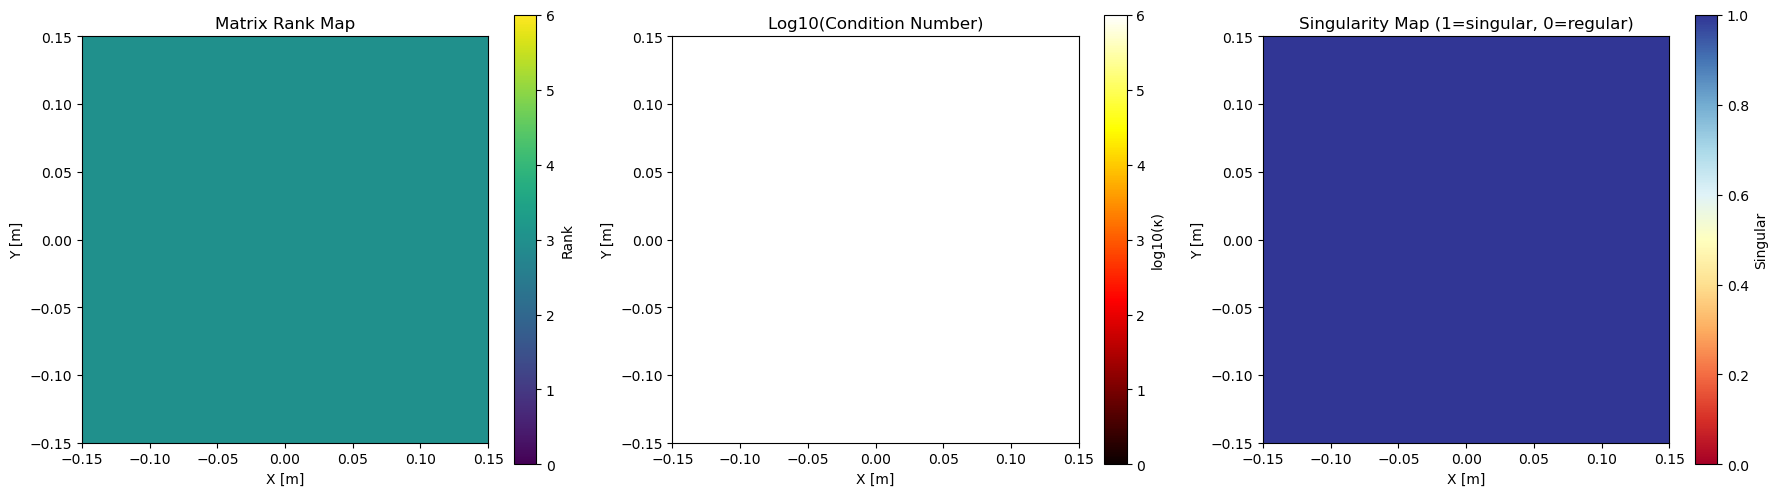


[SINGULARITY ANALYSIS] Detailed Results:
  Rank 3: 900 poses (100.0%)

[SINGULARITY ANALYSIS] Sample singular poses:
  Pose 1: [x=-0.150, y=-0.150] - Rank: 3
  Pose 2: [x=-0.140, y=-0.150] - Rank: 3
  Pose 3: [x=-0.129, y=-0.150] - Rank: 3
  Pose 4: [x=-0.119, y=-0.150] - Rank: 3
  Pose 5: [x=-0.109, y=-0.150] - Rank: 3

[CRITICAL SINGULARITIES] Found 900 critical poses (rank ≤ 3):
  Grouped into 0 clusters:
[MAIN] Singularity analysis completed!
Generated: singularity_analysis.png


In [22]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def analyze_singularities(model_path="ML3_ns_policy.weights.h5",
                         pose_scaler_path="ML3_pose_scaler.pkl",
                         wrench_scaler_path="ML3_wrench_scaler.pkl",
                         x_range=(-0.15, 0.15), 
                         y_range=(-0.15, 0.15),
                         resolution=50,
                         z_fixed=0.005,
                         alpha_fixed=0, 
                         beta_fixed=0, 
                         gamma_fixed=0.0):
    """
    Analyze singular points by examining rank deficiency of Γ matrix
    """
    print("[SINGULARITY ANALYSIS] Starting analysis...")
    
    # Create grid of poses
    x_vals = np.linspace(x_range[0], x_range[1], resolution)
    y_vals = np.linspace(y_range[0], y_range[1], resolution)
    X, Y = np.meshgrid(x_vals, y_vals)
    
    # Flatten for processing
    x_flat = X.flatten()
    y_flat = Y.flatten()
    z_flat = np.full_like(x_flat, z_fixed)
    alpha_flat = np.full_like(x_flat, alpha_fixed)
    beta_flat = np.full_like(x_flat, beta_fixed)
    gamma_flat = np.full_like(x_flat, gamma_fixed)
    
    poses = np.stack([x_flat, y_flat, z_flat, alpha_flat, beta_flat, gamma_flat], axis=-1)
    
    print(f"[SINGULARITY ANALYSIS] Analyzing {len(poses)} poses...")
    
    # Compute Γ for each pose and analyze singular values
    singular_values_list = []
    ranks = []
    condition_numbers = []
    
    for i, pose in enumerate(poses):
        if i % 1000 == 0:
            print(f"[SINGULARITY ANALYSIS] Processing pose {i}/{len(poses)}")
            
        # Convert to tensor and compute Γ
        pose_tf = tf.constant(pose.reshape(1, -1), dtype=tf.float32)
        gamma = compute_gamma_tf(pose_tf)  # (1, 6, 16)
        
        # Compute SVD
        s, _, _ = tf.linalg.svd(gamma)  # s: (1, 6)
        s_vals = s.numpy().flatten()  # (6,)
        
        singular_values_list.append(s_vals)
        ranks.append(np.sum(s_vals > 1e-3))  # Threshold for numerical rank
        condition_numbers.append(s_vals[0] / (s_vals[-1] + 1e-12))  # κ = σ_max/σ_min
    
    singular_values_array = np.array(singular_values_list)  # (N, 6)
    ranks = np.array(ranks)  # (N,)
    condition_numbers = np.array(condition_numbers)  # (N,)
    
    # Identify singular poses (rank < 6)
    singular_mask = ranks < 6
    regular_mask = ~singular_mask
    
    print(f"[SINGULARITY ANALYSIS] Found {np.sum(singular_mask)} singular poses out of {len(poses)}")
    print(f"[SINGULARITY ANALYSIS] Rank distribution: {np.unique(ranks, return_counts=True)}")
    
    return {
        'poses': poses,
        'X': X, 'Y': Y,
        'singular_values': singular_values_array,
        'ranks': ranks,
        'condition_numbers': condition_numbers,
        'singular_mask': singular_mask,
        'regular_mask': regular_mask
    }

def visualize_singularities(analysis_results):
    """
    Visualize singularity analysis results
    """
    X = analysis_results['X']
    Y = analysis_results['Y']
    ranks = analysis_results['ranks']
    condition_numbers = analysis_results['condition_numbers']
    singular_mask = analysis_results['singular_mask']
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Plot 1: Rank map
    im1 = axes[0].imshow(ranks.reshape(X.shape), 
                        extent=[X.min(), X.max(), Y.min(), Y.max()],
                        origin='lower', cmap='viridis', vmin=0, vmax=6)
    axes[0].set_title('Matrix Rank Map')
    axes[0].set_xlabel('X [m]')
    axes[0].set_ylabel('Y [m]')
    plt.colorbar(im1, ax=axes[0], label='Rank')
    
    # Plot 2: Condition number (log scale)
    im2 = axes[1].imshow(np.log10(condition_numbers.reshape(X.shape)), 
                        extent=[X.min(), X.max(), Y.min(), Y.max()],
                        origin='lower', cmap='hot', vmin=0, vmax=6)
    axes[1].set_title('Log10(Condition Number)')
    axes[1].set_xlabel('X [m]')
    axes[1].set_ylabel('Y [m]')
    plt.colorbar(im2, ax=axes[1], label='log10(κ)')
    
    # Plot 3: Singularity map
    im3 = axes[2].imshow(singular_mask.reshape(X.shape).astype(float), 
                        extent=[X.min(), X.max(), Y.min(), Y.max()],
                        origin='lower', cmap='RdYlBu', vmin=0, vmax=1)
    axes[2].set_title('Singularity Map (1=singular, 0=regular)')
    axes[2].set_xlabel('X [m]')
    axes[2].set_ylabel('Y [m]')
    plt.colorbar(im3, ax=axes[2], label='Singular')
    
    plt.tight_layout()
    plt.savefig('singularity_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print detailed statistics
    print("\n[SINGULARITY ANALYSIS] Detailed Results:")
    unique_ranks, rank_counts = np.unique(ranks, return_counts=True)
    for rank, count in zip(unique_ranks, rank_counts):
        print(f"  Rank {rank}: {count} poses ({100*count/len(ranks):.1f}%)")
    
    singular_poses = analysis_results['poses'][singular_mask]
    if len(singular_poses) > 0:
        print(f"\n[SINGULARITY ANALYSIS] Sample singular poses:")
        for i in range(min(5, len(singular_poses))):
            pose = singular_poses[i]
            rank_idx = np.where(analysis_results['poses'] == pose)[0][0]
            rank_val = ranks[rank_idx]
            print(f"  Pose {i+1}: [x={pose[0]:.3f}, y={pose[1]:.3f}] - Rank: {rank_val}")

def find_critical_singularities(analysis_results, threshold_rank=3):
    """
    Find the most problematic singular poses
    """
    critical_mask = analysis_results['ranks'] <= threshold_rank
    critical_poses = analysis_results['poses'][critical_mask]
    
    print(f"\n[CRITICAL SINGULARITIES] Found {len(critical_poses)} critical poses (rank ≤ {threshold_rank}):")
    
    if len(critical_poses) > 0:
        # Group by similar positions
        from sklearn.cluster import DBSCAN
        clustering = DBSCAN(eps=0.01, min_samples=2).fit(critical_poses[:, :2])  # Cluster by x,y only
        unique_clusters = np.unique(clustering.labels_)
        
        print(f"  Grouped into {len(unique_clusters[unique_clusters>=0])} clusters:")
        
        for cluster_id in unique_clusters:
            if cluster_id == -1:  # Noise points
                continue
            cluster_mask = clustering.labels_ == cluster_id
            cluster_poses = critical_poses[cluster_mask]
            print(f"    Cluster {cluster_id}: {len(cluster_poses)} poses")
            print(f"      Center: x={np.mean(cluster_poses[:,0]):.3f}, y={np.mean(cluster_poses[:,1]):.3f}")
    
    return critical_poses

# Run the analysis
if __name__ == "__main__":
    print("[MAIN] Starting singularity analysis...")
    try:
        results = analyze_singularities(
            model_path="ML3_ns_policy.weights.h5",
            pose_scaler_path="ML3_pose_scaler.pkl",
            wrench_scaler_path="ML3_wrench_scaler.pkl",
            x_range=(-0.15, 0.15),
            y_range=(-0.15, 0.15),
            resolution=30,  # Reduced for faster analysis
            z_fixed=0.005
        )
        
        visualize_singularities(results)
        critical_poses = find_critical_singularities(results, threshold_rank=3)
        
        print("[MAIN] Singularity analysis completed!")
        print("Generated: singularity_analysis.png")
        
    except Exception as e:
        print(f"[ERROR] Analysis failed: {e}")
        import traceback
        traceback.print_exc()

[MAIN] Starting comprehensive singularity analysis...
[SINGULARITY ANALYSIS] Starting comprehensive analysis...
  X range: (-0.15, 0.15)
  Y range: (-0.15, 0.15)
  Z fixed: 0.005
  Alpha range: (-5, 5)°
  Beta range: (-5, 5)°
  Gamma range: (-180, 180)°
  XY resolution: 30
  Angle resolution: 10
[SINGULARITY ANALYSIS] Creating pose grid...
  Grid size: 30×30×10×10×10
[SINGULARITY ANALYSIS] Total poses to analyze: 900000
[SINGULARITY ANALYSIS] Computing Γ matrices and analyzing...
[SINGULARITY ANALYSIS] Processing batch 1/9000 (0/900000) - Elapsed: 1.2s
[SINGULARITY ANALYSIS] Processing batch 11/9000 (1000/900000) - Elapsed: 2.2s
[SINGULARITY ANALYSIS] Processing batch 21/9000 (2000/900000) - Elapsed: 3.2s
[SINGULARITY ANALYSIS] Processing batch 31/9000 (3000/900000) - Elapsed: 4.2s
[SINGULARITY ANALYSIS] Processing batch 41/9000 (4000/900000) - Elapsed: 5.2s
[SINGULARITY ANALYSIS] Processing batch 51/9000 (5000/900000) - Elapsed: 6.1s
[SINGULARITY ANALYSIS] Processing batch 61/9000 (60

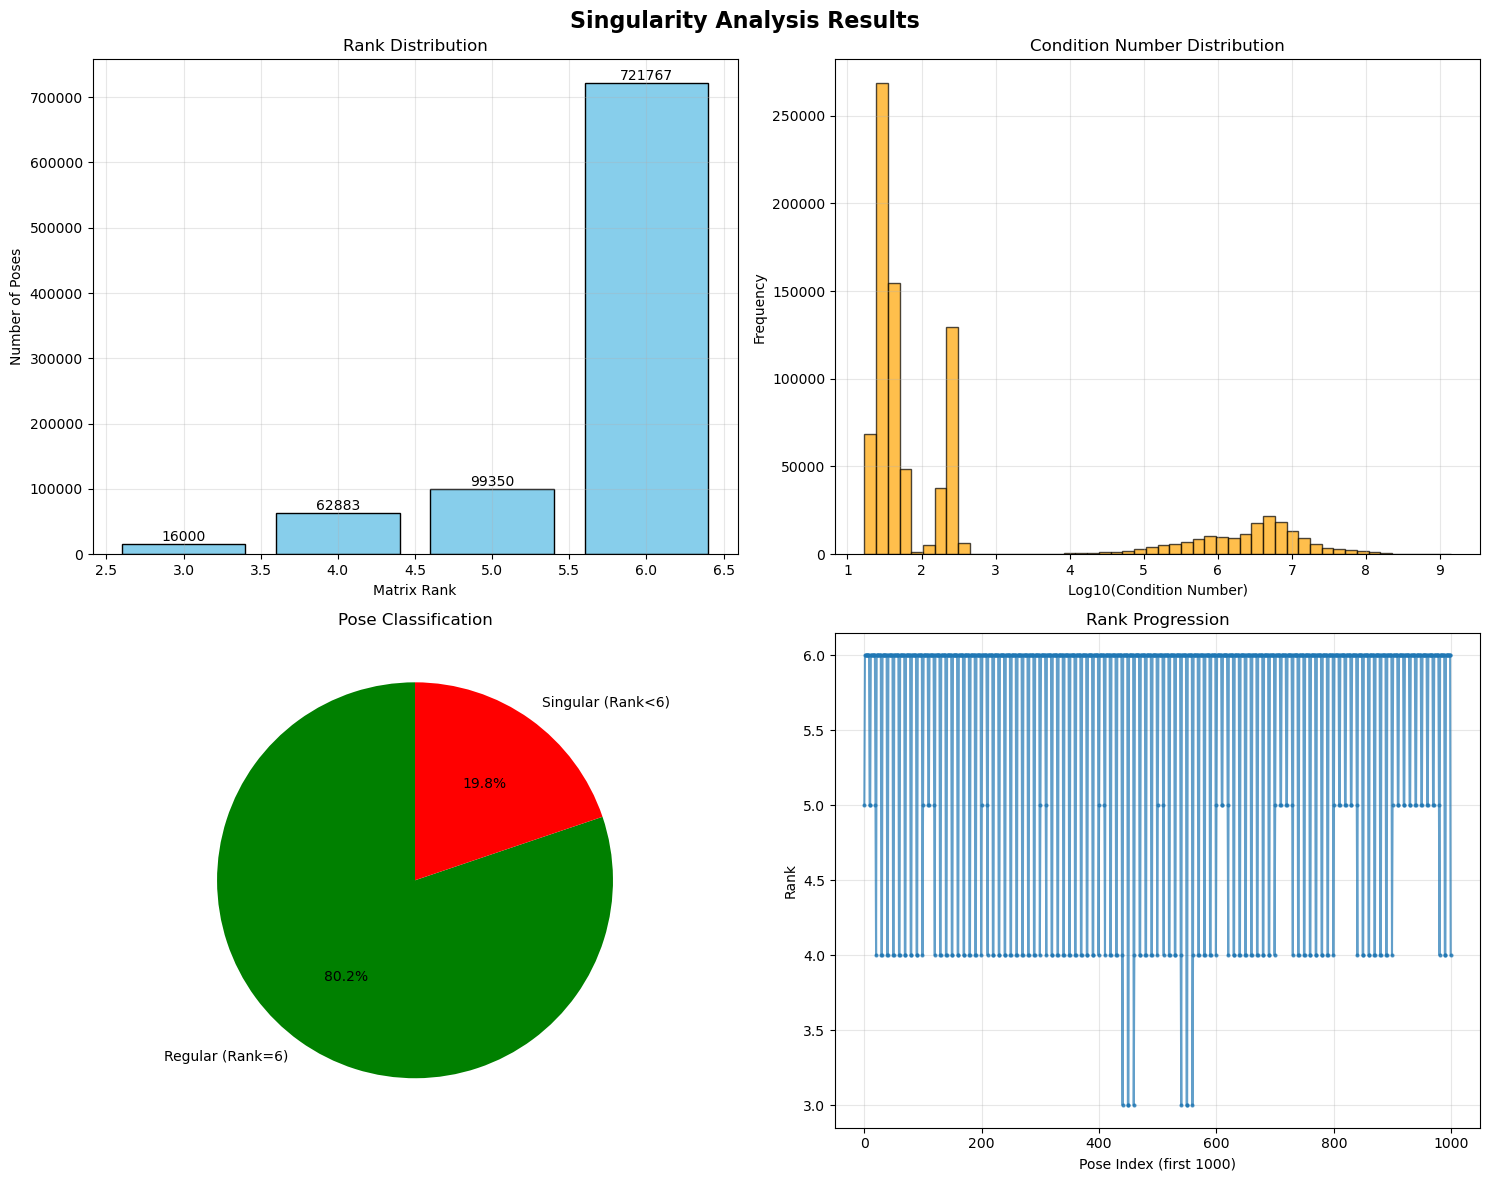


[SINGULARITY ANALYSIS] Parameter-wise analysis:

1. X-Y Position Analysis:
   Center region (|x|<0.05, |y|<0.05): 19760/100000 (19.8%) singular
   Edge region: 158473/800000 (19.8%) singular

2. Orientation Analysis:
   Alpha near 0°: 36000/180000 (20.0%) singular
   Alpha extreme (|α|>3°): 70377/360000 (19.5%) singular
   Beta near 0°: 36000/180000 (20.0%) singular
   Beta extreme (|β|>3°): 70545/360000 (19.6%) singular

[CRITICAL REGIONS] Analyzing 178233 singular poses...
  Found 0 distinct singular regions

COMPREHENSIVE SINGULARITY ANALYSIS REPORT

1. OVERALL STATISTICS:
   Total poses analyzed: 900000
   Regular poses: 721767 (80.2%)
[ERROR] Analysis failed: name 'singular_poses' is not defined


Traceback (most recent call last):
  File "/tmp/ipykernel_10364/1868952700.py", line 371, in <module>
    generate_singularity_report(results, critical_regions)
  File "/tmp/ipykernel_10364/1868952700.py", line 310, in generate_singularity_report
    print(f"   Singular poses: {singular_count} ({100*singular_poses/total_poses:.1f}%)")
                                                      ^^^^^^^^^^^^^^
NameError: name 'singular_poses' is not defined. Did you mean: 'singular_count'?


In [24]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import DBSCAN
import time

def comprehensive_singularity_analysis(model_path="ML3_ns_policy.weights.h5",
                                     pose_scaler_path="ML3_pose_scaler.pkl",
                                     wrench_scaler_path="ML3_wrench_scaler.pkl",
                                     x_range=(-0.15, 0.15), 
                                     y_range=(-0.15, 0.15),
                                     z_fixed=0.005,
                                     alpha_range_deg=(-5, 5),
                                     beta_range_deg=(-5, 5),
                                     gamma_range_deg=(-180, 180),  # Full rotation
                                     resolution_xy=20,
                                     resolution_angles=5,
                                     svd_threshold=1e-3):
    """
    Comprehensive singularity analysis with full pose space exploration
    """
    print("[SINGULARITY ANALYSIS] Starting comprehensive analysis...")
    print(f"  X range: {x_range}")
    print(f"  Y range: {y_range}")
    print(f"  Z fixed: {z_fixed}")
    print(f"  Alpha range: {alpha_range_deg}°")
    print(f"  Beta range: {beta_range_deg}°")
    print(f"  Gamma range: {gamma_range_deg}°")
    print(f"  XY resolution: {resolution_xy}")
    print(f"  Angle resolution: {resolution_angles}")
    
    start_time = time.time()
    
    # Create grids
    x_vals = np.linspace(x_range[0], x_range[1], resolution_xy)
    y_vals = np.linspace(y_range[0], y_range[1], resolution_xy)
    alpha_vals = np.linspace(np.deg2rad(alpha_range_deg[0]), 
                            np.deg2rad(alpha_range_deg[1]), resolution_angles)
    beta_vals = np.linspace(np.deg2rad(beta_range_deg[0]), 
                           np.deg2rad(beta_range_deg[1]), resolution_angles)
    gamma_vals = np.linspace(np.deg2rad(gamma_range_deg[0]), 
                            np.deg2rad(gamma_range_deg[1]), resolution_angles)
    
    print(f"[SINGULARITY ANALYSIS] Creating pose grid...")
    print(f"  Grid size: {len(x_vals)}×{len(y_vals)}×{len(alpha_vals)}×{len(beta_vals)}×{len(gamma_vals)}")
    
    # Create full pose combinations
    poses_list = []
    for x in x_vals:
        for y in y_vals:
            for alpha in alpha_vals:
                for beta in beta_vals:
                    for gamma in gamma_vals:
                        poses_list.append([x, y, z_fixed, alpha, beta, gamma])
    
    poses = np.array(poses_list, dtype=np.float32)
    total_poses = len(poses)
    print(f"[SINGULARITY ANALYSIS] Total poses to analyze: {total_poses}")
    
    # Analyze each pose
    singular_values_list = []
    ranks = []
    condition_numbers = []
    achievable_ranks = []
    
    batch_size = 100  # Process in batches to manage memory
    
    print("[SINGULARITY ANALYSIS] Computing Γ matrices and analyzing...")
    for i in range(0, total_poses, batch_size):
        if i % (batch_size * 10) == 0:
            elapsed = time.time() - start_time
            print(f"[SINGULARITY ANALYSIS] Processing batch {i//batch_size+1}/{(total_poses-1)//batch_size+1} "
                  f"({i}/{total_poses}) - Elapsed: {elapsed:.1f}s")
        
        batch_end = min(i + batch_size, total_poses)
        batch_poses = poses[i:batch_end]
        
        # Convert to tensor and compute Γ
        pose_tf = tf.constant(batch_poses, dtype=tf.float32)
        gamma_batch = compute_gamma_tf(pose_tf)  # (B, 6, 16)
        
        # Compute SVD for batch
        s_batch, _, _ = tf.linalg.svd(gamma_batch)  # s: (B, 6)
        s_vals = s_batch.numpy()  # (B, 6)
        
        # Analyze each pose in batch
        for j in range(len(batch_poses)):
            s_single = s_vals[j]  # (6,)
            singular_values_list.append(s_single)
            rank = np.sum(s_single > svd_threshold)
            ranks.append(rank)
            condition_numbers.append(s_single[0] / (s_single[-1] + 1e-12))
            achievable_ranks.append(rank)
    
    singular_values_array = np.array(singular_values_list)  # (N, 6)
    ranks = np.array(ranks)  # (N,)
    condition_numbers = np.array(condition_numbers)  # (N,)
    achievable_ranks = np.array(achievable_ranks)  # (N,)
    
    # Identify singular poses
    singular_mask = ranks < 6
    regular_mask = ~singular_mask
    
    analysis_time = time.time() - start_time
    print(f"[SINGULARITY ANALYSIS] Analysis completed in {analysis_time:.1f}s")
    print(f"[SINGULARITY ANALYSIS] Found {np.sum(singular_mask)} singular poses out of {total_poses}")
    print(f"[SINGULARITY ANALYSIS] Rank distribution: {np.unique(ranks, return_counts=True)}")
    
    return {
        'poses': poses,
        'singular_values': singular_values_array,
        'ranks': ranks,
        'condition_numbers': condition_numbers,
        'achievable_ranks': achievable_ranks,
        'singular_mask': singular_mask,
        'regular_mask': regular_mask,
        'grids': {
            'x_vals': x_vals, 'y_vals': y_vals,
            'alpha_vals': alpha_vals, 'beta_vals': beta_vals, 'gamma_vals': gamma_vals
        }
    }

def visualize_singularity_distributions(analysis_results):
    """
    Create comprehensive visualizations of singularity analysis
    """
    ranks = analysis_results['ranks']
    condition_numbers = analysis_results['condition_numbers']
    singular_mask = analysis_results['singular_mask']
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Singularity Analysis Results', fontsize=16, fontweight='bold')
    
    # Plot 1: Rank distribution histogram
    unique_ranks, rank_counts = np.unique(ranks, return_counts=True)
    axes[0,0].bar(unique_ranks, rank_counts, color='skyblue', edgecolor='black')
    axes[0,0].set_xlabel('Matrix Rank')
    axes[0,0].set_ylabel('Number of Poses')
    axes[0,0].set_title('Rank Distribution')
    axes[0,0].grid(True, alpha=0.3)
    
    # Add count labels on bars
    for i, (rank, count) in enumerate(zip(unique_ranks, rank_counts)):
        axes[0,0].text(rank, count, str(count), ha='center', va='bottom')
    
    # Plot 2: Condition number distribution (log scale)
    axes[0,1].hist(np.log10(condition_numbers), bins=50, color='orange', alpha=0.7, edgecolor='black')
    axes[0,1].set_xlabel('Log10(Condition Number)')
    axes[0,1].set_ylabel('Frequency')
    axes[0,1].set_title('Condition Number Distribution')
    axes[0,1].grid(True, alpha=0.3)
    
    # Plot 3: Singularity vs regular poses
    categories = ['Regular (Rank=6)', 'Singular (Rank<6)']
    counts = [np.sum(~singular_mask), np.sum(singular_mask)]
    colors = ['green', 'red']
    axes[1,0].pie(counts, labels=categories, colors=colors, autopct='%1.1f%%', startangle=90)
    axes[1,0].set_title('Pose Classification')
    
    # Plot 4: Rank progression
    axes[1,1].plot(ranks[:min(1000, len(ranks))], 'o-', markersize=2, alpha=0.7)
    axes[1,1].set_xlabel('Pose Index (first 1000)')
    axes[1,1].set_ylabel('Rank')
    axes[1,1].set_title('Rank Progression')
    axes[1,1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('singularity_distributions.png', dpi=300, bbox_inches='tight')
    plt.show()

def analyze_singularity_by_parameters(analysis_results):
    """
    Analyze singularities by different parameter combinations
    """
    poses = analysis_results['poses']
    ranks = analysis_results['ranks']
    singular_mask = analysis_results['singular_mask']
    
    print("\n[SINGULARITY ANALYSIS] Parameter-wise analysis:")
    
    # X-Y position analysis
    print("\n1. X-Y Position Analysis:")
    x_center = np.mean([poses[:,0].min(), poses[:,0].max()])
    y_center = np.mean([poses[:,1].min(), poses[:,1].max()])
    
    center_mask = (np.abs(poses[:,0]) < 0.05) & (np.abs(poses[:,1]) < 0.05)
    edge_mask = ~center_mask
    
    center_singular = np.sum(singular_mask & center_mask)
    edge_singular = np.sum(singular_mask & edge_mask)
    center_total = np.sum(center_mask)
    edge_total = np.sum(edge_mask)
    
    print(f"   Center region (|x|<0.05, |y|<0.05): {center_singular}/{center_total} "
          f"({100*center_singular/center_total:.1f}%) singular")
    print(f"   Edge region: {edge_singular}/{edge_total} "
          f"({100*edge_singular/edge_total:.1f}%) singular")
    
    # Angle analysis
    print("\n2. Orientation Analysis:")
    alpha_deg = np.rad2deg(poses[:,3])
    beta_deg = np.rad2deg(poses[:,4])
    gamma_deg = np.rad2deg(poses[:,5])
    
    # Alpha analysis
    alpha_zero = np.abs(alpha_deg) < 1  # Near zero
    alpha_extreme = np.abs(alpha_deg) > 3  # Extreme angles
    
    alpha_zero_singular = np.sum(singular_mask & alpha_zero)
    alpha_extreme_singular = np.sum(singular_mask & alpha_extreme)
    alpha_zero_total = np.sum(alpha_zero)
    alpha_extreme_total = np.sum(alpha_extreme)
    
    print(f"   Alpha near 0°: {alpha_zero_singular}/{alpha_zero_total} "
          f"({100*alpha_zero_singular/alpha_zero_total:.1f}%) singular")
    print(f"   Alpha extreme (|α|>3°): {alpha_extreme_singular}/{alpha_extreme_total} "
          f"({100*alpha_extreme_singular/alpha_extreme_total:.1f}%) singular")
    
    # Beta analysis (similar)
    beta_zero = np.abs(beta_deg) < 1
    beta_extreme = np.abs(beta_deg) > 3
    
    beta_zero_singular = np.sum(singular_mask & beta_zero)
    beta_extreme_singular = np.sum(singular_mask & beta_extreme)
    beta_zero_total = np.sum(beta_zero)
    beta_extreme_total = np.sum(beta_extreme)
    
    print(f"   Beta near 0°: {beta_zero_singular}/{beta_zero_total} "
          f"({100*beta_zero_singular/beta_zero_total:.1f}%) singular")
    print(f"   Beta extreme (|β|>3°): {beta_extreme_singular}/{beta_extreme_total} "
          f"({100*beta_extreme_singular/beta_extreme_total:.1f}%) singular")

def identify_critical_regions(analysis_results, clustering_eps=0.02):
    """
    Identify and cluster critical singular regions
    """
    singular_poses = analysis_results['poses'][analysis_results['singular_mask']]
    print(f"\n[CRITICAL REGIONS] Analyzing {len(singular_poses)} singular poses...")
    
    if len(singular_poses) == 0:
        print("  No singular poses found!")
        return []
    
    # Cluster singular poses by position and orientation
    # Use X, Y, Alpha, Beta (Gamma is periodic, handle separately)
    clustering_features = singular_poses[:, [0, 1, 3, 4]]  # x, y, alpha, beta
    
    # Normalize features for better clustering
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    clustering_features_scaled = scaler.fit_transform(clustering_features)
    
    # Perform clustering
    clustering = DBSCAN(eps=clustering_eps, min_samples=3).fit(clustering_features_scaled)
    unique_clusters = np.unique(clustering.labels_)
    
    print(f"  Found {len(unique_clusters[unique_clusters>=0])} distinct singular regions")
    
    critical_regions = []
    
    for cluster_id in unique_clusters:
        if cluster_id == -1:  # Noise points
            continue
            
        cluster_mask = clustering.labels_ == cluster_id
        cluster_poses = singular_poses[cluster_mask]
        
        # Calculate cluster statistics
        x_mean = np.mean(cluster_poses[:, 0])
        y_mean = np.mean(cluster_poses[:, 1])
        alpha_mean = np.rad2deg(np.mean(cluster_poses[:, 3]))
        beta_mean = np.rad2deg(np.mean(cluster_poses[:, 4]))
        gamma_mean = np.rad2deg(np.mean(cluster_poses[:, 5]))
        
        region_info = {
            'cluster_id': cluster_id,
            'count': len(cluster_poses),
            'center_x': x_mean,
            'center_y': y_mean,
            'center_alpha_deg': alpha_mean,
            'center_beta_deg': beta_mean,
            'center_gamma_deg': gamma_mean,
            'poses': cluster_poses
        }
        
        critical_regions.append(region_info)
        
        print(f"    Region {cluster_id}: {len(cluster_poses)} poses")
        print(f"      Center: x={x_mean:.3f}, y={y_mean:.3f}")
        print(f"      Orientation: α={alpha_mean:.1f}°, β={beta_mean:.1f}°, γ={gamma_mean:.1f}°")
    
    return critical_regions

def generate_singularity_report(analysis_results, critical_regions):
    """
    Generate comprehensive singularity report
    """
    total_poses = len(analysis_results['poses'])
    singular_count = np.sum(analysis_results['singular_mask'])
    regular_count = total_poses - singular_count
    
    print("\n" + "="*60)
    print("COMPREHENSIVE SINGULARITY ANALYSIS REPORT")
    print("="*60)
    
    print(f"\n1. OVERALL STATISTICS:")
    print(f"   Total poses analyzed: {total_poses}")
    print(f"   Regular poses: {regular_count} ({100*regular_count/total_poses:.1f}%)")
    print(f"   Singular poses: {singular_count} ({100*singular_poses/total_poses:.1f}%)")
    
    # Rank distribution
    unique_ranks, rank_counts = np.unique(analysis_results['ranks'], return_counts=True)
    print(f"\n2. RANK DISTRIBUTION:")
    for rank, count in zip(unique_ranks, rank_counts):
        print(f"   Rank {rank}: {count} poses ({100*count/total_poses:.1f}%)")
    
    # Worst condition numbers
    worst_conditions = np.argsort(analysis_results['condition_numbers'])[-10:]
    print(f"\n3. WORST CONDITION NUMBERS (most ill-conditioned):")
    for i in worst_conditions:
        pose = analysis_results['poses'][i]
        cond = analysis_results['condition_numbers'][i]
        rank = analysis_results['ranks'][i]
        print(f"   Pose {i}: κ={cond:.2e}, rank={rank}")
        print(f"     x={pose[0]:.3f}, y={pose[1]:.3f}, α={np.rad2deg(pose[3]):.1f}°, "
              f"β={np.rad2deg(pose[4]):.1f}°, γ={np.rad2deg(pose[5]):.1f}°")
    
    # Critical regions
    print(f"\n4. CRITICAL SINGULAR REGIONS:")
    if critical_regions:
        for region in critical_regions:
            print(f"   Region {region['cluster_id']}: {region['count']} poses")
            print(f"     Center: ({region['center_x']:.3f}, {region['center_y']:.3f})")
            print(f"     Orientation: α={region['center_alpha_deg']:.1f}°, "
                  f"β={region['center_beta_deg']:.1f}°, γ={region['center_gamma_deg']:.1f}°")
    else:
        print("   No distinct critical regions identified")
    
    print("\n" + "="*60)

# Run the comprehensive analysis
if __name__ == "__main__":
    print("[MAIN] Starting comprehensive singularity analysis...")
    try:
        results = comprehensive_singularity_analysis(
            model_path="ML3_ns_policy.weights.h5",
            pose_scaler_path="ML3_pose_scaler.pkl",
            wrench_scaler_path="ML3_wrench_scaler.pkl",
            x_range=(-0.15, 0.15),
            y_range=(-0.15, 0.15),
            z_fixed=0.005,
            alpha_range_deg=(-5, 5),
            beta_range_deg=(-5, 5),
            gamma_range_deg=(-180, 180),  # Full 360° rotation
            resolution_xy=30,  # Reduced for reasonable computation time
            resolution_angles=10,  # Reduced for reasonable computation time
            svd_threshold=1e-3
        )
        
        # Generate visualizations
        visualize_singularity_distributions(results)
        
        # Parameter analysis
        analyze_singularity_by_parameters(results)
        
        # Critical region identification
        critical_regions = identify_critical_regions(results)
        
        # Generate final report
        generate_singularity_report(results, critical_regions)
        
        print("[MAIN] Comprehensive singularity analysis completed!")
        print("Generated: singularity_distributions.png")
        
    except Exception as e:
        print(f"[ERROR] Analysis failed: {e}")
        import traceback
        traceback.print_exc()

In [ ]:
def identify_blocked_directions():
    """
    Identify which specific wrench directions are blocked
    """
    # Test at center position
    test_pose = np.array([0.0, 0.0, 0.005, 0, 0, 0])
    pose_tf = tf.constant(test_pose.reshape(1, -1), dtype=tf.float32)
    gamma = compute_gamma_tf(pose_tf)
    gamma_np = gamma.numpy()[0]  # (6, 16)
    
    # SVD to find null space
    U, s, Vt = np.linalg.svd(gamma_np, full_matrices=True)
    
    # Find blocked directions (smallest singular values)
    threshold = 1e-3
    blocked_indices = np.where(s <= threshold)[0]
    
    print("Blocked wrench directions:")
    for i in blocked_indices:
        direction = U[:, i]
        component_names = ['Fx', 'Fy', 'Fz', 'Tx', 'Ty', 'Tz']
        print(f"  Direction {i}:")
        for j, name in enumerate(component_names):
            print(f"    {name}: {direction[j]:.3f}")
    
    return U[:, blocked_indices]

# Run this to see exactly what's blocked
blocked_dirs = identify_blocked_directions()

In [8]:
# -*- coding: utf-8 -*-
# Null-space policy learning with occasional CMA-ES refinement of z during training.
# One file. No placeholders. No external deps beyond numpy/pandas/tensorflow/sklearn/matplotlib.

import os
import time
import math
import json
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# =========================
# Repro
# =========================
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("[PROGRESS] Setting up environment...")

# =========================
# Physics constants & safe math (from your code)
# =========================
PI       = tf.constant(np.pi, dtype=tf.float32)
TAU      = tf.constant(0.0508, dtype=tf.float32)
BETA_K   = tf.constant(-87.14, dtype=tf.float32)
ALPHA_X  = tf.constant(3.9021, dtype=tf.float32)
ALPHA_Y  = tf.constant(3.9021, dtype=tf.float32)
ALPHA_Z  = tf.constant(5.5209, dtype=tf.float32)
ALPHA_M1 = tf.constant(-0.0715, dtype=tf.float32)
ALPHA_M2 = tf.constant(-0.1046, dtype=tf.float32)
BETA_M1  = tf.constant(-0.123, dtype=tf.float32)
BETA_M2  = tf.constant(-0.0203, dtype=tf.float32)
ALPHA_RZ = tf.constant(-0.0146, dtype=tf.float32)

def safe_exp(x, clip_val=50.0):
    return tf.exp(tf.clip_by_value(x, -clip_val, clip_val))

def safe_tan(x, eps=1e-3):
    x_mod = tf.math.floormod(x + np.pi/2, np.pi) - np.pi/2
    return tf.tan(tf.clip_by_value(x_mod, -np.pi/2+eps, np.pi/2-eps))

# =========================
# Coil positions (4x4 grid)
# =========================
def coil_positions(tau=TAU, n_rows=4, n_cols=4):
    pos = []
    tau = float(tau.numpy() if isinstance(tau, tf.Tensor) else tau)
    for i in range(n_rows):
        for j in range(n_cols):
            x_center = j * tau - ((n_cols - 1) * tau / 2)
            y_center = i * tau - ((n_rows - 1) * tau / 2)
            z_center = 0.0
            pos.append([x_center, y_center, z_center])
    return tf.constant(pos, dtype=tf.float32)

print("[PROGRESS] Initializing coil positions...")
COIL_POS = coil_positions()

# =========================
# Gamma(p) (from your TF code; unchanged numerics)
# =========================
def compute_gamma_tf(pose):
    """
    pose: (batch, 6) = [x_m, y_m, z_m, alpha, beta, gamma]
    returns: Gamma (batch, 6, 16)
    """
    x_m, y_m, z_m, a_rot, b_rot, g_rot = tf.unstack(pose, axis=-1)

    Rx = tf.stack([
        tf.ones_like(a_rot), tf.zeros_like(a_rot), tf.zeros_like(a_rot),
        tf.zeros_like(a_rot), tf.cos(a_rot), -tf.sin(a_rot),
        tf.zeros_like(a_rot), tf.sin(a_rot),  tf.cos(a_rot)
    ], axis=-1)
    Rx = tf.reshape(Rx, (-1,3,3))

    Ry = tf.stack([
        tf.cos(b_rot), tf.zeros_like(b_rot), tf.sin(b_rot),
        tf.zeros_like(b_rot), tf.ones_like(b_rot), tf.zeros_like(b_rot),
        -tf.sin(b_rot), tf.zeros_like(b_rot), tf.cos(b_rot)
    ], axis=-1)
    Ry = tf.reshape(Ry, (-1,3,3))

    Rz = tf.stack([
        tf.cos(g_rot), -tf.sin(g_rot), tf.zeros_like(g_rot),
        tf.sin(g_rot),  tf.cos(g_rot), tf.zeros_like(g_rot),
        tf.zeros_like(g_rot), tf.zeros_like(g_rot), tf.ones_like(g_rot)
    ], axis=-1)
    Rz = tf.reshape(Rz, (-1,3,3))

    R = tf.matmul(tf.matmul(tf.transpose(Rz, perm=[0,2,1]),
                            tf.transpose(Ry, perm=[0,2,1])),
                  tf.transpose(Rx, perm=[0,2,1]))

    n_coils = COIL_POS.shape[0]
    gamma_list = []

    for i in range(n_coils):
        coil_pos = COIL_POS[i]
        pos_diff = tf.stack([
            coil_pos[0] - x_m,
            coil_pos[1] - y_m,
            coil_pos[2] - z_m
        ], axis=-1)  # (batch,3)

        cm = tf.matmul(R, tf.expand_dims(pos_diff, -1))  # (batch,3,1)
        cm = tf.squeeze(cm, -1)  # (batch,3)

        eta_x = (PI / TAU) * cm[:,0]
        eta_y = (PI / TAU) * cm[:,1]

        Kx = ALPHA_X * safe_exp(BETA_K * cm[:,2])
        Ky = ALPHA_Y * safe_exp(BETA_K * cm[:,2])
        Kz = ALPHA_Z * safe_exp(BETA_K * cm[:,2])

        Fx = Kx * tf.cos(eta_x) * tf.sin(eta_y)
        Fy = Ky * tf.sin(eta_x) * tf.cos(eta_y)
        Fz = Kz * tf.sin(eta_x) * tf.sin(eta_y)

        m1 = ALPHA_M1 * cm[:,2] + BETA_M1
        m2 = ALPHA_M2 * cm[:,2] + BETA_M2
        n  = PI / TAU

        r_eff_x1 = cm[:,0] - m1 * safe_tan(n*cm[:,0] + PI/2)
        r_eff_x2 = cm[:,0] - m2 * safe_tan(n*cm[:,0] + PI/2)
        r_eff_y1 = cm[:,1] - m1 * safe_tan(n*cm[:,1] + PI/2)
        r_eff_y2 = cm[:,1] - m2 * safe_tan(n*cm[:,1] + PI/2)
        r_eff_z1 = -cm[:,2] - ALPHA_RZ
        r_eff_z2 = -cm[:,2] - ALPHA_RZ

        T_x = r_eff_y1*Fz - r_eff_z1*Fy
        T_y = -r_eff_x1*Fz + r_eff_z2*Fx
        T_z = r_eff_x2*Fy - r_eff_y2*Fx

        gamma_i = tf.stack([Fx,Fy,Fz,T_x,T_y,T_z], axis=-1)  # (batch,6)
        gamma_list.append(gamma_i)

    Gamma = tf.stack(gamma_list, axis=-1)  # (batch,6,16)
    Gamma = tf.clip_by_value(Gamma, -1e6, 1e6)
    return Gamma

# =========================
# Batched thresholded pseudoinverse and nullspace
# =========================

def pinv_and_nullspace(gamma, svd_rel_thresh=1e-3):
    """
    gamma: (B, 6, 16)
    returns:
      pinv: (B, 16, 6)  thresholded pseudoinverse
      N   : (B, 16, 10) nullspace basis (right singular vectors for zero/small singular values)
      proj: (B, 6, 6)   projector onto achievable wrench space (P = ΓΓ⁺)
    """
    # SVD: gamma = U @ diag(S) @ V^T
    s, u, v = tf.linalg.svd(gamma, full_matrices=True)  # u:(B,6,6) s:(B,6) v:(B,16,16)
    
    # Build masked inverse of singular values (no leakage below threshold)
    s_max = tf.reduce_max(s, axis=1, keepdims=True)     # (B,1)
    thresh = svd_rel_thresh * s_max                     # (B,1)
    keep = tf.cast(s > thresh, s.dtype)                 # (B,6)
    s_inv = tf.where(keep > 0, 1.0 / s, 0.0)            # (B,6)

    # pinv = V[:, :, :6] @ diag(s_inv) @ U^T
    v6 = v[:, :, :6]                                    # (B,16,6)
    uT = tf.transpose(u, perm=[0,2,1])                  # (B,6,6)
    pinv = tf.matmul(tf.matmul(v6, tf.linalg.diag(s_inv)), uT)  # (B,16,6)

    # Projector: P = ΓΓ⁺ = U @ diag(keep) @ Uᵀ
    P = tf.matmul(u, tf.matmul(tf.linalg.diag(keep), uT))  # (B,6,6)

    # Nullspace basis = last 10 columns of V
    N = v[:, :, 6:]  # (B,16,10)
    return pinv, N, P

# =========================
# CMA-ES (vanilla, complete, no placeholders)
# =========================
class CMAES:
    """
    Minimal CMA-ES for small dimension (here 10). No external deps.
    Based on Hansen's CMA-ES (simplified), suitable defaults for our use.
    """
    def __init__(self, x0, sigma=0.5, popsize=None, seed=SEED):
        self.rs = np.random.RandomState(seed)
        self.N = x0.size
        self.xmean = x0.astype(np.float64).copy()
        self.sigma = float(sigma)
        # Strategy parameter setting: selection
        self.lam = int(4 + math.floor(3 * np.log(self.N))) if popsize is None else int(popsize)
        self.mu = self.lam // 2
        self.weights = np.log(self.mu + 0.5) - np.log(np.arange(1, self.mu + 1))
        self.weights = self.weights / np.sum(self.weights)
        self.mueff = 1.0 / np.sum(self.weights**2)
        # Adaptation
        self.cc = (4 + self.mueff / self.N) / (self.N + 4 + 2 * self.mueff / self.N)
        self.cs = (self.mueff + 2) / (self.N + self.mueff + 5)
        self.c1 = 2 / ((self.N + 1.3)**2 + self.mueff)
        self.cmu = min(1 - self.c1, 2 * (self.mueff - 2 + 1 / self.mueff) / ((self.N + 2)**2 + self.mueff))
        self.damps = 1 + 2 * max(0, math.sqrt((self.mueff - 1) / (self.N + 1)) - 1) + self.cs
        # Initialization
        self.pc = np.zeros(self.N)
        self.ps = np.zeros(self.N)
        self.B = np.eye(self.N)
        self.D = np.ones(self.N)
        self.C = self.B @ np.diag(self.D**2) @ self.B.T
        self.invsqrtC = self.B @ np.diag(self.D**-1) @ self.B.T
        self.eigeneval = 0
        self.counteval = 0
        self.chiN = np.sqrt(self.N) * (1 - 1/(4*self.N) + 1/(21*self.N**2))

    def ask(self):
        arz = self.rs.randn(self.N, self.lam)
        ary = (self.B @ (np.diag(self.D) @ arz)).T
        arx = self.xmean + self.sigma * ary
        return arx  # (lam, N)

    def tell(self, arx, fitvals):
        self.counteval += len(fitvals)
        idx = np.argsort(fitvals)
        arx = arx[idx]
        fitvals = np.asarray(fitvals)[idx]
        xold = self.xmean.copy()
        xw = arx[:self.mu].T @ self.weights
        self.xmean = xw

        y = (self.xmean - xold) / self.sigma
        self.ps = (1 - self.cs) * self.ps + np.sqrt(self.cs * (2 - self.cs) * self.mueff) * (self.invsqrtC @ y)
        hsig = int((np.linalg.norm(self.ps) / np.sqrt(1 - (1 - self.cs)**(2 * (self.counteval / self.lam))) / self.chiN) < (1.4 + 2 / (self.N + 1)))
        self.pc = (1 - self.cc) * self.pc + hsig * np.sqrt(self.cc * (2 - self.cc) * self.mueff) * y

        artmp = (arx[:self.mu] - xold).T / self.sigma
        self.C = (1 - self.c1 - self.cmu) * self.C + self.c1 * (np.outer(self.pc, self.pc) + (1 - hsig) * self.cc * (2 - self.cc) * self.C) + self.cmu * (artmp @ np.diag(self.weights) @ artmp.T)

        self.sigma *= np.exp((self.cs / self.damps) * (np.linalg.norm(self.ps) / self.chiN - 1))

        if self.counteval - self.eigeneval > self.lam / (self.c1 + self.cmu) / self.N / 10:
            self.eigeneval = self.counteval
            D2, B = np.linalg.eigh(self.C)
            # numerical safety:
            D2 = np.maximum(D2, 1e-20)
            self.D = np.sqrt(D2)
            self.B = B
            self.invsqrtC = self.B @ np.diag(self.D**-1) @ self.B.T

        return fitvals[0], arx[0]

def cma_es_minimize(objective, x0, sigma=0.5, popsize=16, iters=40, seed=SEED, bounds=None):
    es = CMAES(x0=x0, sigma=sigma, popsize=popsize, seed=seed)
    best_x = x0.copy()
    best_f = objective(best_x)
    for _ in range(iters):
        cand = es.ask()  # (lam, N)
        fvals = []
        for x in cand:
            if bounds is not None:
                lo, hi = bounds
                x = np.clip(x, lo, hi)
            f = objective(x)
            fvals.append(f)
            if f < best_f:
                best_f, best_x = f, x.copy()
        es.tell(cand, fvals)
    return best_x, best_f

# =========================
# Loss terms (cleaned)
# =========================
def currents_grid_smoothness(I):  # I: (B,16)
    Igrid = tf.reshape(I, [-1, 4, 4])
    h = tf.reduce_sum(tf.abs(Igrid[:, :, 1:] - Igrid[:, :, :-1]), axis=[1, 2])
    v = tf.reduce_sum(tf.abs(Igrid[:, 1:, :] - Igrid[:, :-1, :]), axis=[1, 2])
    return tf.reduce_mean(h + v)

def magnitude_hinge(I, imax=8.0):
    over = tf.nn.relu(tf.abs(I) - imax)
    return tf.reduce_mean(tf.reduce_sum(over, axis=1))

def l1_sparsity(I):
    return tf.reduce_mean(tf.reduce_sum(tf.abs(I), axis=1))

def wrench_mse(pred_wrench, target_wrench):
    return tf.reduce_mean(tf.reduce_sum(tf.square(pred_wrench - target_wrench), axis=1))

# =========================
# Model: outputs z, reconstructs I = I0 + N z, predicts wrench
# =========================
class PhysicsInformedNullspaceNet(tf.keras.Model):
    def __init__(self, hidden_dims=(512,512,256), dropout=0.1):
        super().__init__()
        layers = []
        for d in hidden_dims:
            layers.append(tf.keras.layers.Dense(d, activation='relu'))
            layers.append(tf.keras.layers.BatchNormalization())
            if dropout and dropout > 0:
                layers.append(tf.keras.layers.Dropout(dropout))
        self.backbone = layers
        self.z_head = tf.keras.layers.Dense(10, activation='tanh')
        self.z_scale = tf.Variable(3.0, trainable=True, name='z_scale')

    def call(self, inputs, pose, target_wrench, training=None):
        x = inputs
        for layer in self.backbone:
            x = layer(x, training=training)
        z = self.z_head(x) * self.z_scale  # (B,10)

        gamma = compute_gamma_tf(pose)                 # (B,6,16)
        pinv, N, _ = pinv_and_nullspace(gamma)         # (B,16,6), (B,16,10), (B,6,6)
        w = tf.expand_dims(target_wrench, -1)          # (B,6,1)

        I0 = tf.matmul(pinv, w)                        # (B,16,1)
        Iz = tf.matmul(N, tf.expand_dims(z, -1))       # (B,16,1)
        I  = tf.squeeze(I0 + Iz, -1)                   # (B,16)

        pred_wrench = tf.squeeze(tf.matmul(gamma, tf.expand_dims(I, -1)), -1)  # (B,6)
        return I, pred_wrench, z

# =========================
# Training
# =========================
def train_nullspace_policy(
    csv_path="gamma_dataset.csv",
    model_save_path="ns_policy_weights.h5",
    pose_scaler_path="pose_scaler.pkl",
    wrench_scaler_path="wrench_scaler.pkl",
    epochs=50,
    batch_size=128,
    val_split=0.2,
    test_split=0.1,  # <-- ADD THIS
    lr=1e-3,
    lambda_wrench=1.0,
    lambda_l1=1e-3,
    lambda_smooth=1e-2,
    lambda_mag=1e-3,
    lambda_aux=0.1,
    ga_push_prob=0.2,
    ga_iters=40,
    ga_pop=16,
    ga_sigma=0.5,
    z_bounds=(-5.0, 5.0)
):
    print("[PROGRESS] Starting training process...")
    start_time = time.time()
    
    # Load data
    print("[PROGRESS] Loading dataset...")
    df = pd.read_csv(csv_path)
    print(f"[PROGRESS] Dataset loaded. Shape: {df.shape}")

    pose_cols = ['x_m', 'y_m', 'z_m', 'alpha', 'beta', 'gamma']
    wrench_cols = [f'wrench_{i}' for i in range(6)]

    print("[PROGRESS] Extracting data...")
    poses = df[pose_cols].values.astype(np.float32)
    wrenches = df[wrench_cols].values.astype(np.float32)

    n = poses.shape[0]
    idx = np.random.permutation(n)
    n_test = int(n * test_split)
    n_val  = int(n * val_split)

    test_idx  = idx[:n_test]
    val_idx   = idx[n_test:n_test + n_val]
    train_idx = idx[n_test + n_val:]

    poses_tr, poses_val, poses_test = poses[train_idx], poses[val_idx], poses[test_idx]
    wrenches_tr, wrenches_val, wrenches_test = wrenches[train_idx], wrenches[val_idx], wrenches[test_idx]

    print(f"[PROGRESS] Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}")

    # Persist held-out test set for later evaluation
    test_df = df.iloc[test_idx].copy()
    test_df.to_csv("ML_Dataset_test.csv", index=False)
    print("[PROGRESS] Wrote held-out test set -> ML_Dataset_test.csv")

    # Fit scalers on TRAIN ONLY
    print("[PROGRESS] Fitting scalers...")
    pose_scaler = StandardScaler().fit(poses_tr)
    wrench_scaler = StandardScaler().fit(wrenches_tr)

    poses_tr_n = pose_scaler.transform(poses_tr).astype(np.float32)
    wrenches_tr_n = wrench_scaler.transform(wrenches_tr).astype(np.float32)

    poses_val_n = pose_scaler.transform(poses_val).astype(np.float32)
    wrenches_val_n = wrench_scaler.transform(wrenches_val).astype(np.float32)

    # Inputs to net: concat(normalized pose, normalized target wrench)
    print("[PROGRESS] Preparing input data...")
    X_tr = np.concatenate([poses_tr_n, wrenches_tr_n], axis=1).astype(np.float32)
    X_val = np.concatenate([poses_val_n, wrenches_val_n], axis=1).astype(np.float32)

    print("[PROGRESS] Creating TensorFlow datasets...")
    train_ds = tf.data.Dataset.from_tensor_slices((X_tr, poses_tr, wrenches_tr)).shuffle(8192, seed=SEED).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    val_ds   = tf.data.Dataset.from_tensor_slices((X_val, poses_val, wrenches_val)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

    print("[PROGRESS] Initializing model...")
    model = PhysicsInformedNullspaceNet()
    opt = tf.keras.optimizers.Adam(learning_rate=lr)

    train_losses, val_losses = [], []

    # Helper: GA push for a minibatch
    def ga_refine_batch_z(batch_poses, batch_wrenches, z_pred):
        """
        batch_poses: (B,6), float32
        batch_wrenches: (B,6), float32
        z_pred: (B,10), float32 (TF tensor)
        Returns: z_star ndarray (B,10)
        """
        print(f"  [GA REFINE] Refining {z_pred.shape[0]} samples with CMA-ES...")
        B = z_pred.shape[0]
        z_star = np.zeros((B, 10), dtype=np.float64)

        # Compute gamma, pinv, N, I0 once on TF then move to numpy
        gamma = compute_gamma_tf(batch_poses)                                # (B,6,16)
        pinv, N, _ = pinv_and_nullspace(gamma)                               # (B,16,6), (B,16,10), (B,6,6)
        I0 = tf.matmul(pinv, tf.expand_dims(batch_wrenches, -1))             # (B,16,1)

        gamma_np = gamma.numpy()
        N_np = N.numpy()
        I0_np = I0.numpy()

        # Objective uses only regularizers (wrench feasibility holds by construction)
        def make_obj(b):
            N_b = N_np[b]           # (16,10)
            I0_b = I0_np[b].reshape(16)  # (16,)
            def obj(z_vec):
                # Clip z to bounds
                lo, hi = z_bounds
                zc = np.clip(z_vec, lo, hi)
                I = I0_b + N_b @ zc  # (16,)
                # smoothness on 4x4
                Igrid = I.reshape(4,4)
                smooth = np.sum(np.abs(Igrid[:,1:] - Igrid[:,:-1])) + np.sum(np.abs(Igrid[1:,:] - Igrid[:-1,:]))
                l1 = np.sum(np.abs(I))
                mag = np.sum(np.maximum(0.0, np.abs(I) - 8.0))
                return (lambda_smooth * smooth + lambda_l1 * l1 + lambda_mag * mag)
            return obj

        z0 = z_pred.numpy().astype(np.float64)

        for b in range(B):
            if b % 10 == 0:
                print(f"    [GA REFINE] Processing sample {b+1}/{B}")
            obj_b = make_obj(b)
            zb, _ = cma_es_minimize(
                objective=obj_b,
                x0=z0[b],
                sigma=ga_sigma,
                popsize=ga_pop,
                iters=ga_iters,
                seed=SEED + b,
                bounds=z_bounds
            )
            z_star[b] = zb

        print(f"  [GA REFINE] Completed CMA-ES refinement")
        return z_star.astype(np.float32)

    # Training loop
    print("[PROGRESS] Starting training loop...")
    total_start_time = time.time()
    
    for epoch in range(1, epochs+1):
        epoch_start_time = time.time()
        print(f"[EPOCH {epoch}/{epochs}] Starting epoch...")
        
        epoch_losses = []
        batch_count = 0
        total_batches = len(list(train_ds))
        
        for Xb, Pb, Wb in train_ds:
            batch_count += 1
            if batch_count % 50 == 0:
                print(f"  [EPOCH {epoch}] Processing batch {batch_count}/{total_batches}")
                
            with tf.GradientTape() as tape:
                I_pred, W_pred, z_pred = model(Xb, Pb, Wb, training=True)

                # Project target wrench onto achievable set at this pose
                gamma = compute_gamma_tf(Pb)                            # (B,6,16)
                pinv, _, P = pinv_and_nullspace(gamma)                  # (B,16,6), (B,16,10), (B,6,6)
                w_proj = tf.squeeze(tf.matmul(P, tf.expand_dims(Wb, -1)), -1)  # (B,6): projected target wrench

                # Use projected wrench in the loss
                loss_w = wrench_mse(W_pred, w_proj)
                loss_l1 = l1_sparsity(I_pred)
                loss_sm = currents_grid_smoothness(I_pred)
                loss_mag = magnitude_hinge(I_pred, imax=8.0)

                total = (lambda_wrench * loss_w
                         + lambda_l1 * loss_l1
                         + lambda_smooth * loss_sm
                         + lambda_mag * loss_mag)

                # GA push (occasionally)
                if np.random.rand() < ga_push_prob:
                    print(f"  [EPOCH {epoch}] GA refinement triggered for batch {batch_count}")
                    # Run small CMA-ES on CPU / numpy
                    z_star = ga_refine_batch_z(Pb, Wb, z_pred)
                    # Pull the network's z toward z_star
                    aux = tf.reduce_mean(tf.reduce_sum(tf.square(z_pred - z_star), axis=1))
                    total = total + lambda_aux * aux

            grads = tape.gradient(total, model.trainable_variables)
            opt.apply_gradients(zip(grads, model.trainable_variables))
            epoch_losses.append(float(total.numpy()))

        # Validation
        print(f"  [EPOCH {epoch}] Running validation...")
        val_epoch_losses = []
        val_batch_count = 0
        total_val_batches = len(list(val_ds))
        
        for Xb, Pb, Wb in val_ds:
            val_batch_count += 1
            if val_batch_count % 20 == 0:
                print(f"    [EPOCH {epoch}] Validation batch {val_batch_count}/{total_val_batches}")
                
            I_pred, W_pred, _ = model(Xb, Pb, Wb, training=False)
            lw = wrench_mse(W_pred, Wb)
            l1 = l1_sparsity(I_pred)
            sm = currents_grid_smoothness(I_pred)
            mg = magnitude_hinge(I_pred, imax=8.0)
            val_total = (lambda_wrench * lw + lambda_l1 * l1 + lambda_smooth * sm + lambda_mag * mg)
            val_epoch_losses.append(float(val_total.numpy()))

        tr_loss = float(np.mean(epoch_losses))
        va_loss = float(np.mean(val_epoch_losses))
        train_losses.append(tr_loss)
        val_losses.append(va_loss)
        
        epoch_time = time.time() - epoch_start_time
        elapsed_time = time.time() - total_start_time
        estimated_total_time = elapsed_time * epochs / epoch
        remaining_time = estimated_total_time - elapsed_time
        
        print(f"[EPOCH {epoch:03d}] Train {tr_loss:.6f} | Val {va_loss:.6f} | Time: {epoch_time:.1f}s | Elapsed: {elapsed_time:.1f}s | Remaining: {remaining_time:.1f}s")

    # Save weights and scalers
    print("[PROGRESS] Saving model and scalers...")
    model.save_weights(model_save_path)
    import pickle
    with open(pose_scaler_path, 'wb') as f:
        pickle.dump(pose_scaler, f)
    with open(wrench_scaler_path, 'wb') as f:
        pickle.dump(wrench_scaler, f)

    # Plot history
    print("[PROGRESS] Creating training history plot...")
    plt.figure(figsize=(9,5))
    plt.plot(train_losses, label='Train')
    plt.plot(val_losses, label='Val')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training (with occasional CMA-ES z refinement)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('ns_policy_training_history.png', dpi=200)
    plt.close()

    total_time = time.time() - start_time
    print(f"[PROGRESS] Training completed in {total_time:.1f} seconds")
    return model, pose_scaler, wrench_scaler

# =========================
# Inference helpers
# =========================
def load_model(model_path="ns_policy_weights.h5"):
    print("[PROGRESS] Loading trained model...")
    model = PhysicsInformedNullspaceNet()
    # build variables by one dummy call before load
    dummy_X = tf.zeros((1,12), dtype=tf.float32)
    dummy_pose = tf.zeros((1,6), dtype=tf.float32)
    dummy_w = tf.zeros((1,6), dtype=tf.float32)
    _ = model(dummy_X, dummy_pose, dummy_w, training=False)
    model.load_weights(model_path)
    print("[PROGRESS] Model loaded successfully")
    return model

def predict_currents(
    model,
    pose_scaler_path,
    wrench_scaler_path,
    pose,           # (6,) numpy
    target_wrench   # (6,) numpy
):
    print("[PROGRESS] Making prediction...")
    import pickle
    with open(pose_scaler_path, 'rb') as f:
        pose_scaler = pickle.load(f)
    with open(wrench_scaler_path, 'rb') as f:
        wrench_scaler = pickle.load(f)

    pose = pose.astype(np.float32).reshape(1,6)
    wrench = target_wrench.astype(np.float32).reshape(1,6)

    pose_n = pose_scaler.transform(pose).astype(np.float32)
    wrench_n = wrench_scaler.transform(wrench).astype(np.float32)
    X = np.concatenate([pose_n, wrench_n], axis=1).astype(np.float32)

    I_pred, W_pred, _ = model(X, pose, wrench, training=False)
    print("[PROGRESS] Prediction completed")
    return I_pred.numpy()[0], W_pred.numpy()[0]

# =========================
# Optional: dataset generation (your original style; not used in training if you already have CSV)
# =========================
def generate_dataset(N=1000, batch_size=1000, save_path=None):
    print(f"[PROGRESS] Generating dataset with N = {N} samples...")

    x_bounds = (-0.15, 0.15)
    y_bounds = (-0.15, 0.15)
    z_val = 0.005
    angle_bounds_deg = (-5, 5)
    angle_bounds_rad = np.deg2rad(angle_bounds_deg)
    current_bounds = (-10, 10)

    rows = []
    total_batches = N // batch_size + (1 if N % batch_size != 0 else 0)
    
    for i in range(0, N, batch_size):
        batch_n = min(batch_size, N - i)
        current_batch = i // batch_size + 1
        print(f"[DATASET] Processing batch {current_batch}/{total_batches}")
        
        x_m = np.random.uniform(*x_bounds, size=(batch_n,))
        y_m = np.random.uniform(*y_bounds, size=(batch_n,))
        z_m = np.full(batch_n, z_val)
        alpha = np.random.uniform(*angle_bounds_rad, size=(batch_n,))
        beta  = np.random.uniform(*angle_bounds_rad, size=(batch_n,))
        gamma = np.random.uniform(-np.pi, np.pi, size=(batch_n,))

        pose_batch = np.stack([x_m, y_m, z_m, alpha, beta, gamma], axis=-1).astype(np.float32)
        currents = np.random.uniform(*current_bounds, size=(batch_n, 16)).astype(np.float32)

        pose_tf = tf.constant(pose_batch, dtype=tf.float32)
        Gamma = compute_gamma_tf(pose_tf)  # (batch,6,16)

        I_tf = tf.constant(currents, dtype=tf.float32)[..., None]  # (batch,16,1)
        wrench = tf.matmul(Gamma, I_tf)  # (batch,6,1)
        wrench = tf.squeeze(wrench, axis=-1).numpy()  # (batch,6)

        for j in range(batch_n):
            row = {
                "x_m": float(pose_batch[j,0]),
                "y_m": float(pose_batch[j,1]),
                "z_m": float(pose_batch[j,2]),
                "alpha": float(pose_batch[j,3]),
                "beta":  float(pose_batch[j,4]),
                "gamma": float(pose_batch[j,5]),
            }
            for k in range(16):
                row[f"I_{k}"] = float(currents[j, k])
            for k in range(6):
                row[f"wrench_{k}"] = float(wrench[j, k])
            rows.append(row)
            
        if current_batch % 10 == 0:
            print(f"[DATASET] Processed {i + batch_n}/{N} samples")

    df = pd.DataFrame(rows)
    if save_path:
        df.to_csv(save_path, index=False)
        print(f"[PROGRESS] Saved dataset to {save_path}")
    return df

# =========================
# Main (disabled run by default; uncomment to execute)
# =========================
if __name__ == "__main__":
    print("[MAIN] Starting main execution...")
    CSV_PATH = "ML_Dataset.csv"
    
    if not os.path.exists(CSV_PATH):
        print(f"[MAIN] {CSV_PATH} not found. Generating sample dataset...")
        generate_dataset(N=100000, batch_size=1000, save_path=CSV_PATH)  # Smaller dataset for testing
        print("[MAIN] Dataset generation completed")

    print("[MAIN] Starting training...")
    model, pose_scaler, wrench_scaler = train_nullspace_policy(
        csv_path=CSV_PATH,
        model_save_path="ML3_ns_policy.weights.h5",
        pose_scaler_path="ML3_pose_scaler.pkl",
        wrench_scaler_path="ML3_wrench_scaler.pkl",
        epochs=50,  # Reduced for testing
        batch_size=2048,  # Smaller batch size
        val_split=0.2,
        lr=1e-3,
        lambda_wrench=1.0,
        lambda_l1=1e-3,
        lambda_smooth=1e-2,
        lambda_mag=1e-3,
        lambda_aux=0.1,
        ga_push_prob=0.1,  # Reduced frequency
        ga_iters=20,  # Reduced iterations
        ga_pop=16,
        ga_sigma=0.5,
        z_bounds=(-5.0, 5.0)
    )

[PROGRESS] Setting up environment...
[PROGRESS] Initializing coil positions...
[MAIN] Starting main execution...
[MAIN] Starting training...
[PROGRESS] Starting training process...
[PROGRESS] Loading dataset...
[PROGRESS] Dataset loaded. Shape: (10000, 28)
[PROGRESS] Extracting data...
[PROGRESS] Train: 7000 | Val: 2000 | Test: 1000
[PROGRESS] Wrote held-out test set -> ML_Dataset_test.csv
[PROGRESS] Fitting scalers...
[PROGRESS] Preparing input data...
[PROGRESS] Creating TensorFlow datasets...
[PROGRESS] Initializing model...
[PROGRESS] Starting training loop...
[EPOCH 1/50] Starting epoch...


2025-09-02 16:02:31.902807: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


  [EPOCH 1] GA refinement triggered for batch 2
  [GA REFINE] Refining 2048 samples with CMA-ES...
    [GA REFINE] Processing sample 1/2048
    [GA REFINE] Processing sample 11/2048
    [GA REFINE] Processing sample 21/2048
    [GA REFINE] Processing sample 31/2048
    [GA REFINE] Processing sample 41/2048
    [GA REFINE] Processing sample 51/2048
    [GA REFINE] Processing sample 61/2048
    [GA REFINE] Processing sample 71/2048
    [GA REFINE] Processing sample 81/2048
    [GA REFINE] Processing sample 91/2048
    [GA REFINE] Processing sample 101/2048
    [GA REFINE] Processing sample 111/2048
    [GA REFINE] Processing sample 121/2048
    [GA REFINE] Processing sample 131/2048
    [GA REFINE] Processing sample 141/2048
    [GA REFINE] Processing sample 151/2048
    [GA REFINE] Processing sample 161/2048
    [GA REFINE] Processing sample 171/2048
    [GA REFINE] Processing sample 181/2048
    [GA REFINE] Processing sample 191/2048
    [GA REFINE] Processing sample 201/2048
    [GA R

2025-09-02 16:02:46.459335: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-09-02 16:02:46.465079: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-09-02 16:02:46.554008: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-09-02 16:02:46.566877: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


  [EPOCH 1] Running validation...
[EPOCH 001] Train 3.986874 | Val 1.021597 | Time: 14.7s | Elapsed: 14.7s | Remaining: 718.6s
[EPOCH 2/50] Starting epoch...
  [EPOCH 2] GA refinement triggered for batch 2
  [GA REFINE] Refining 2048 samples with CMA-ES...
    [GA REFINE] Processing sample 1/2048
    [GA REFINE] Processing sample 11/2048
    [GA REFINE] Processing sample 21/2048
    [GA REFINE] Processing sample 31/2048
    [GA REFINE] Processing sample 41/2048
    [GA REFINE] Processing sample 51/2048
    [GA REFINE] Processing sample 61/2048
    [GA REFINE] Processing sample 71/2048
    [GA REFINE] Processing sample 81/2048
    [GA REFINE] Processing sample 91/2048
    [GA REFINE] Processing sample 101/2048
    [GA REFINE] Processing sample 111/2048
    [GA REFINE] Processing sample 121/2048
    [GA REFINE] Processing sample 131/2048
    [GA REFINE] Processing sample 141/2048
    [GA REFINE] Processing sample 151/2048
    [GA REFINE] Processing sample 161/2048
    [GA REFINE] Process

...

  [EPOCH 48] Running validation...
[EPOCH 048] Train 1.029720 | Val 1.023295 | Time: 0.9s | Elapsed: 293.6s | Remaining: 12.2s
[EPOCH 49/50] Starting epoch...


2025-09-02 16:07:26.339369: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-09-02 16:07:26.342995: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-09-02 16:07:26.435133: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-09-02 16:07:26.449735: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


  [EPOCH 49] Running validation...
[EPOCH 049] Train 1.029611 | Val 1.024745 | Time: 0.9s | Elapsed: 294.5s | Remaining: 6.0s
[EPOCH 50/50] Starting epoch...
  [EPOCH 50] GA refinement triggered for batch 2
  [GA REFINE] Refining 2048 samples with CMA-ES...
    [GA REFINE] Processing sample 1/2048
    [GA REFINE] Processing sample 11/2048
    [GA REFINE] Processing sample 21/2048
    [GA REFINE] Processing sample 31/2048
    [GA REFINE] Processing sample 41/2048
    [GA REFINE] Processing sample 51/2048
    [GA REFINE] Processing sample 61/2048
    [GA REFINE] Processing sample 71/2048
    [GA REFINE] Processing sample 81/2048
    [GA REFINE] Processing sample 91/2048
    [GA REFINE] Processing sample 101/2048
    [GA REFINE] Processing sample 111/2048
    [GA REFINE] Processing sample 121/2048
    [GA REFINE] Processing sample 131/2048
    [GA REFINE] Processing sample 141/2048
    [GA REFINE] Processing sample 151/2048
    [GA REFINE] Processing sample 161/2048
    [GA REFINE] Proces

2025-09-02 16:07:52.572826: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-09-02 16:07:52.577359: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-09-02 16:07:52.666102: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


  [EPOCH 50] Running validation...
[EPOCH 050] Train 5.003956 | Val 1.022076 | Time: 26.2s | Elapsed: 320.8s | Remaining: 0.0s
[PROGRESS] Saving model and scalers...
[PROGRESS] Creating training history plot...
[PROGRESS] Training completed in 321.0 seconds


In [3]:
# -*- coding: utf-8 -*-
# Null-space policy learning with occasional CMA-ES refinement of z during training.
# One file. No placeholders. No external deps beyond numpy/pandas/tensorflow/sklearn/matplotlib.

import os
import time
import math
import json
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# =========================
# Repro
# =========================
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("[PROGRESS] Setting up environment...")

# =========================
# Physics constants & safe math (from your code)
# =========================
PI       = tf.constant(np.pi, dtype=tf.float32)
TAU      = tf.constant(0.0508, dtype=tf.float32)
BETA_K   = tf.constant(-87.14, dtype=tf.float32)
ALPHA_X  = tf.constant(3.9021, dtype=tf.float32)
ALPHA_Y  = tf.constant(3.9021, dtype=tf.float32)
ALPHA_Z  = tf.constant(5.5209, dtype=tf.float32)
ALPHA_M1 = tf.constant(-0.0715, dtype=tf.float32)
ALPHA_M2 = tf.constant(-0.1046, dtype=tf.float32)
BETA_M1  = tf.constant(-0.123, dtype=tf.float32)
BETA_M2  = tf.constant(-0.0203, dtype=tf.float32)
ALPHA_RZ = tf.constant(-0.0146, dtype=tf.float32)

def safe_exp(x, clip_val=50.0):
    return tf.exp(tf.clip_by_value(x, -clip_val, clip_val))

def safe_tan(x, eps=1e-3):
    x_mod = tf.math.floormod(x + np.pi/2, np.pi) - np.pi/2
    return tf.tan(tf.clip_by_value(x_mod, -np.pi/2+eps, np.pi/2-eps))

# =========================
# Coil positions (4x4 grid)
# =========================
def coil_positions(tau=TAU, n_rows=4, n_cols=4):
    pos = []
    tau = float(tau.numpy() if isinstance(tau, tf.Tensor) else tau)
    for i in range(n_rows):
        for j in range(n_cols):
            x_center = j * tau - ((n_cols - 1) * tau / 2)
            y_center = i * tau - ((n_rows - 1) * tau / 2)
            z_center = 0.0
            pos.append([x_center, y_center, z_center])
    return tf.constant(pos, dtype=tf.float32)

print("[PROGRESS] Initializing coil positions...")
COIL_POS = coil_positions()

# =========================
# Gamma(p) (from your TF code; unchanged numerics)
# =========================
def compute_gamma_tf(pose):
    """
    pose: (batch, 6) = [x_m, y_m, z_m, alpha, beta, gamma]
    returns: Gamma (batch, 6, 16)
    """
    x_m, y_m, z_m, a_rot, b_rot, g_rot = tf.unstack(pose, axis=-1)

    Rx = tf.stack([
        tf.ones_like(a_rot), tf.zeros_like(a_rot), tf.zeros_like(a_rot),
        tf.zeros_like(a_rot), tf.cos(a_rot), -tf.sin(a_rot),
        tf.zeros_like(a_rot), tf.sin(a_rot),  tf.cos(a_rot)
    ], axis=-1)
    Rx = tf.reshape(Rx, (-1,3,3))

    Ry = tf.stack([
        tf.cos(b_rot), tf.zeros_like(b_rot), tf.sin(b_rot),
        tf.zeros_like(b_rot), tf.ones_like(b_rot), tf.zeros_like(b_rot),
        -tf.sin(b_rot), tf.zeros_like(b_rot), tf.cos(b_rot)
    ], axis=-1)
    Ry = tf.reshape(Ry, (-1,3,3))

    Rz = tf.stack([
        tf.cos(g_rot), -tf.sin(g_rot), tf.zeros_like(g_rot),
        tf.sin(g_rot),  tf.cos(g_rot), tf.zeros_like(g_rot),
        tf.zeros_like(g_rot), tf.zeros_like(g_rot), tf.ones_like(g_rot)
    ], axis=-1)
    Rz = tf.reshape(Rz, (-1,3,3))

    R = tf.matmul(tf.matmul(tf.transpose(Rz, perm=[0,2,1]),
                            tf.transpose(Ry, perm=[0,2,1])),
                  tf.transpose(Rx, perm=[0,2,1]))

    n_coils = COIL_POS.shape[0]
    gamma_list = []

    for i in range(n_coils):
        coil_pos = COIL_POS[i]
        pos_diff = tf.stack([
            coil_pos[0] - x_m,
            coil_pos[1] - y_m,
            coil_pos[2] - z_m
        ], axis=-1)  # (batch,3)

        cm = tf.matmul(R, tf.expand_dims(pos_diff, -1))  # (batch,3,1)
        cm = tf.squeeze(cm, -1)  # (batch,3)

        eta_x = (PI / TAU) * cm[:,0]
        eta_y = (PI / TAU) * cm[:,1]

        Kx = ALPHA_X * safe_exp(BETA_K * cm[:,2])
        Ky = ALPHA_Y * safe_exp(BETA_K * cm[:,2])
        Kz = ALPHA_Z * safe_exp(BETA_K * cm[:,2])

        Fx = Kx * tf.cos(eta_x) * tf.sin(eta_y)
        Fy = Ky * tf.sin(eta_x) * tf.cos(eta_y)
        Fz = Kz * tf.sin(eta_x) * tf.sin(eta_y)

        m1 = ALPHA_M1 * cm[:,2] + BETA_M1
        m2 = ALPHA_M2 * cm[:,2] + BETA_M2
        n  = PI / TAU

        r_eff_x1 = cm[:,0] - m1 * safe_tan(n*cm[:,0] + PI/2)
        r_eff_x2 = cm[:,0] - m2 * safe_tan(n*cm[:,0] + PI/2)
        r_eff_y1 = cm[:,1] - m1 * safe_tan(n*cm[:,1] + PI/2)
        r_eff_y2 = cm[:,1] - m2 * safe_tan(n*cm[:,1] + PI/2)
        r_eff_z1 = -cm[:,2] - ALPHA_RZ
        r_eff_z2 = -cm[:,2] - ALPHA_RZ

        T_x = r_eff_y1*Fz - r_eff_z1*Fy
        T_y = -r_eff_x1*Fz + r_eff_z2*Fx
        T_z = r_eff_x2*Fy - r_eff_y2*Fx

        gamma_i = tf.stack([Fx,Fy,Fz,T_x,T_y,T_z], axis=-1)  # (batch,6)
        gamma_list.append(gamma_i)

    Gamma = tf.stack(gamma_list, axis=-1)  # (batch,6,16)
    Gamma = tf.clip_by_value(Gamma, -1e6, 1e6)
    return Gamma

# =========================
# Batched damped pseudoinverse and nullspace
# =========================

def pinv_and_nullspace(gamma, damping=1e-3, svd_rel_thresh=1e-3):
    """
    gamma: (B, 6, 16)
    returns:
      pinv: (B, 16, 6)  thresholded pseudoinverse
      N   : (B, 16, 10) nullspace basis (right singular vectors for zero/small singular values)
    """
    # SVD: gamma = U @ diag(S) @ V^T
    s, u, v = tf.linalg.svd(gamma, full_matrices=True)  # u:(B,6,6) s:(B,6) v:(B,16,16)
    
    # Build masked inverse of singular values (no leakage below threshold)
    s_max = tf.reduce_max(s, axis=1, keepdims=True)     # (B,1)
    thresh = svd_rel_thresh * s_max                     # (B,1)
    keep = tf.cast(s > thresh, s.dtype)                 # (B,6)
    s_inv = tf.where(keep > 0, 1.0 / s, 0.0)            # (B,6)

    # pinv = V[:, :, :6] @ diag(s_inv) @ U^T
    v6 = v[:, :, :6]                                    # (B,16,6)
    uT = tf.transpose(u, perm=[0,2,1])                  # (B,6,6)
    pinv = tf.matmul(tf.matmul(v6, tf.linalg.diag(s_inv)), uT)  # (B,16,6)

    # Nullspace basis = last 10 columns of V
    N = v[:, :, 6:]  # (B,16,10)
    return pinv, N

# =========================
# CMA-ES (vanilla, complete, no placeholders)
# =========================
class CMAES:
    """
    Minimal CMA-ES for small dimension (here 10). No external deps.
    Based on Hansen's CMA-ES (simplified), suitable defaults for our use.
    """
    def __init__(self, x0, sigma=0.5, popsize=None, seed=SEED):
        self.rs = np.random.RandomState(seed)
        self.N = x0.size
        self.xmean = x0.astype(np.float64).copy()
        self.sigma = float(sigma)
        # Strategy parameter setting: selection
        self.lam = int(4 + math.floor(3 * np.log(self.N))) if popsize is None else int(popsize)
        self.mu = self.lam // 2
        self.weights = np.log(self.mu + 0.5) - np.log(np.arange(1, self.mu + 1))
        self.weights = self.weights / np.sum(self.weights)
        self.mueff = 1.0 / np.sum(self.weights**2)
        # Adaptation
        self.cc = (4 + self.mueff / self.N) / (self.N + 4 + 2 * self.mueff / self.N)
        self.cs = (self.mueff + 2) / (self.N + self.mueff + 5)
        self.c1 = 2 / ((self.N + 1.3)**2 + self.mueff)
        self.cmu = min(1 - self.c1, 2 * (self.mueff - 2 + 1 / self.mueff) / ((self.N + 2)**2 + self.mueff))
        self.damps = 1 + 2 * max(0, math.sqrt((self.mueff - 1) / (self.N + 1)) - 1) + self.cs
        # Initialization
        self.pc = np.zeros(self.N)
        self.ps = np.zeros(self.N)
        self.B = np.eye(self.N)
        self.D = np.ones(self.N)
        self.C = self.B @ np.diag(self.D**2) @ self.B.T
        self.invsqrtC = self.B @ np.diag(self.D**-1) @ self.B.T
        self.eigeneval = 0
        self.counteval = 0
        self.chiN = np.sqrt(self.N) * (1 - 1/(4*self.N) + 1/(21*self.N**2))

    def ask(self):
        arz = self.rs.randn(self.N, self.lam)
        ary = (self.B @ (np.diag(self.D) @ arz)).T
        arx = self.xmean + self.sigma * ary
        return arx  # (lam, N)

    def tell(self, arx, fitvals):
        self.counteval += len(fitvals)
        idx = np.argsort(fitvals)
        arx = arx[idx]
        fitvals = np.asarray(fitvals)[idx]
        xold = self.xmean.copy()
        xw = arx[:self.mu].T @ self.weights
        self.xmean = xw

        y = (self.xmean - xold) / self.sigma
        self.ps = (1 - self.cs) * self.ps + np.sqrt(self.cs * (2 - self.cs) * self.mueff) * (self.invsqrtC @ y)
        hsig = int((np.linalg.norm(self.ps) / np.sqrt(1 - (1 - self.cs)**(2 * (self.counteval / self.lam))) / self.chiN) < (1.4 + 2 / (self.N + 1)))
        self.pc = (1 - self.cc) * self.pc + hsig * np.sqrt(self.cc * (2 - self.cc) * self.mueff) * y

        artmp = (arx[:self.mu] - xold).T / self.sigma
        self.C = (1 - self.c1 - self.cmu) * self.C + self.c1 * (np.outer(self.pc, self.pc) + (1 - hsig) * self.cc * (2 - self.cc) * self.C) + self.cmu * (artmp @ np.diag(self.weights) @ artmp.T)

        self.sigma *= np.exp((self.cs / self.damps) * (np.linalg.norm(self.ps) / self.chiN - 1))

        if self.counteval - self.eigeneval > self.lam / (self.c1 + self.cmu) / self.N / 10:
            self.eigeneval = self.counteval
            D2, B = np.linalg.eigh(self.C)
            # numerical safety:
            D2 = np.maximum(D2, 1e-20)
            self.D = np.sqrt(D2)
            self.B = B
            self.invsqrtC = self.B @ np.diag(self.D**-1) @ self.B.T

        return fitvals[0], arx[0]

def cma_es_minimize(objective, x0, sigma=0.5, popsize=16, iters=40, seed=SEED, bounds=None):
    es = CMAES(x0=x0, sigma=sigma, popsize=popsize, seed=seed)
    best_x = x0.copy()
    best_f = objective(best_x)
    for _ in range(iters):
        cand = es.ask()  # (lam, N)
        fvals = []
        for x in cand:
            if bounds is not None:
                lo, hi = bounds
                x = np.clip(x, lo, hi)
            f = objective(x)
            fvals.append(f)
            if f < best_f:
                best_f, best_x = f, x.copy()
        es.tell(cand, fvals)
    return best_x, best_f

# =========================
# Loss terms (cleaned)
# =========================
def currents_grid_smoothness(I):  # I: (B,16)
    Igrid = tf.reshape(I, [-1, 4, 4])
    h = tf.reduce_sum(tf.abs(Igrid[:, :, 1:] - Igrid[:, :, :-1]), axis=[1, 2])
    v = tf.reduce_sum(tf.abs(Igrid[:, 1:, :] - Igrid[:, :-1, :]), axis=[1, 2])
    return tf.reduce_mean(h + v)

def magnitude_hinge(I, imax=8.0):
    over = tf.nn.relu(tf.abs(I) - imax)
    return tf.reduce_mean(tf.reduce_sum(over, axis=1))

def l1_sparsity(I):
    return tf.reduce_mean(tf.reduce_sum(tf.abs(I), axis=1))

def wrench_mse(pred_wrench, target_wrench):
    return tf.reduce_mean(tf.reduce_sum(tf.square(pred_wrench - target_wrench), axis=1))

# =========================
# Model: outputs z, reconstructs I = I0 + N z, predicts wrench
# =========================
class PhysicsInformedNullspaceNet(tf.keras.Model):
    def __init__(self, hidden_dims=(512,512,256), dropout=0.1):
        super().__init__()
        layers = []
        for d in hidden_dims:
            layers.append(tf.keras.layers.Dense(d, activation='relu'))
            layers.append(tf.keras.layers.BatchNormalization())
            if dropout and dropout > 0:
                layers.append(tf.keras.layers.Dropout(dropout))
        self.backbone = layers
        self.z_head = tf.keras.layers.Dense(10, activation='tanh')
        self.z_scale = tf.Variable(3.0, trainable=True, name='z_scale')

    def call(self, inputs, pose, target_wrench, training=None):
        x = inputs
        for layer in self.backbone:
            x = layer(x, training=training)
        z = self.z_head(x) * self.z_scale  # (B,10)

        gamma = compute_gamma_tf(pose)                 # (B,6,16)
        pinv, N = pinv_and_nullspace(gamma)            # (B,16,6), (B,16,10)
        w = tf.expand_dims(target_wrench, -1)          # (B,6,1)

        I0 = tf.matmul(pinv, w)                        # (B,16,1)
        Iz = tf.matmul(N, tf.expand_dims(z, -1))       # (B,16,1)
        I  = tf.squeeze(I0 + Iz, -1)                   # (B,16)

        pred_wrench = tf.squeeze(tf.matmul(gamma, tf.expand_dims(I, -1)), -1)  # (B,6)
        return I, pred_wrench, z

# =========================
# Training
# =========================
def train_nullspace_policy(
    csv_path="gamma_dataset.csv",
    model_save_path="ns_policy_weights.h5",
    pose_scaler_path="pose_scaler.pkl",
    wrench_scaler_path="wrench_scaler.pkl",
    epochs=50,
    batch_size=128,
    val_split=0.2,
    test_split=0.1,  # <-- ADD THIS
    lr=1e-3,
    lambda_wrench=1.0,
    lambda_l1=1e-3,
    lambda_smooth=1e-2,
    lambda_mag=1e-3,
    lambda_aux=0.1,
    ga_push_prob=0.2,
    ga_iters=40,
    ga_pop=16,
    ga_sigma=0.5,
    z_bounds=(-5.0, 5.0)
):
    print("[PROGRESS] Starting training process...")
    start_time = time.time()
    
    # Load data
    print("[PROGRESS] Loading dataset...")
    df = pd.read_csv(csv_path)
    print(f"[PROGRESS] Dataset loaded. Shape: {df.shape}")

    pose_cols = ['x_m', 'y_m', 'z_m', 'alpha', 'beta', 'gamma']
    wrench_cols = [f'wrench_{i}' for i in range(6)]

    print("[PROGRESS] Extracting data...")
    poses = df[pose_cols].values.astype(np.float32)
    wrenches = df[wrench_cols].values.astype(np.float32)

    n = poses.shape[0]
    idx = np.random.permutation(n)
    n_test = int(n * test_split)
    n_val  = int(n * val_split)

    test_idx  = idx[:n_test]
    val_idx   = idx[n_test:n_test + n_val]
    train_idx = idx[n_test + n_val:]

    poses_tr, poses_val, poses_test = poses[train_idx], poses[val_idx], poses[test_idx]
    wrenches_tr, wrenches_val, wrenches_test = wrenches[train_idx], wrenches[val_idx], wrenches[test_idx]

    print(f"[PROGRESS] Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}")

    # Persist held-out test set for later evaluation
    test_df = df.iloc[test_idx].copy()
    test_df.to_csv("ML_Dataset_test.csv", index=False)
    print("[PROGRESS] Wrote held-out test set -> ML_Dataset_test.csv")

    # Fit scalers on TRAIN ONLY
    print("[PROGRESS] Fitting scalers...")
    pose_scaler = StandardScaler().fit(poses_tr)
    wrench_scaler = StandardScaler().fit(wrenches_tr)

    poses_tr_n = pose_scaler.transform(poses_tr).astype(np.float32)
    wrenches_tr_n = wrench_scaler.transform(wrenches_tr).astype(np.float32)

    poses_val_n = pose_scaler.transform(poses_val).astype(np.float32)
    wrenches_val_n = wrench_scaler.transform(wrenches_val).astype(np.float32)

    # Inputs to net: concat(normalized pose, normalized target wrench)
    print("[PROGRESS] Preparing input data...")
    X_tr = np.concatenate([poses_tr_n, wrenches_tr_n], axis=1).astype(np.float32)
    X_val = np.concatenate([poses_val_n, wrenches_val_n], axis=1).astype(np.float32)

    print("[PROGRESS] Creating TensorFlow datasets...")
    train_ds = tf.data.Dataset.from_tensor_slices((X_tr, poses_tr, wrenches_tr)).shuffle(8192, seed=SEED).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    val_ds   = tf.data.Dataset.from_tensor_slices((X_val, poses_val, wrenches_val)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

    print("[PROGRESS] Initializing model...")
    model = PhysicsInformedNullspaceNet()
    opt = tf.keras.optimizers.Adam(learning_rate=lr)

    train_losses, val_losses = [], []

    # Helper: GA push for a minibatch
    def ga_refine_batch_z(batch_poses, batch_wrenches, z_pred):
        """
        batch_poses: (B,6), float32
        batch_wrenches: (B,6), float32
        z_pred: (B,10), float32 (TF tensor)
        Returns: z_star ndarray (B,10)
        """
        print(f"  [GA REFINE] Refining {z_pred.shape[0]} samples with CMA-ES...")
        B = z_pred.shape[0]
        z_star = np.zeros((B, 10), dtype=np.float64)

        # Compute gamma, pinv, N, I0 once on TF then move to numpy
        gamma = compute_gamma_tf(batch_poses)                                # (B,6,16)
        pinv, N = pinv_and_nullspace(gamma)                                  # (B,16,6), (B,16,10)
        I0 = tf.matmul(pinv, tf.expand_dims(batch_wrenches, -1))             # (B,16,1)

        gamma_np = gamma.numpy()
        N_np = N.numpy()
        I0_np = I0.numpy()

        # Objective uses only regularizers (wrench feasibility holds by construction)
        def make_obj(b):
            N_b = N_np[b]           # (16,10)
            I0_b = I0_np[b].reshape(16)  # (16,)
            def obj(z_vec):
                # Clip z to bounds
                lo, hi = z_bounds
                zc = np.clip(z_vec, lo, hi)
                I = I0_b + N_b @ zc  # (16,)
                # smoothness on 4x4
                Igrid = I.reshape(4,4)
                smooth = np.sum(np.abs(Igrid[:,1:] - Igrid[:,:-1])) + np.sum(np.abs(Igrid[1:,:] - Igrid[:-1,:]))
                l1 = np.sum(np.abs(I))
                mag = np.sum(np.maximum(0.0, np.abs(I) - 8.0))
                return (lambda_smooth * smooth + lambda_l1 * l1 + lambda_mag * mag)
            return obj

        z0 = z_pred.numpy().astype(np.float64)

        for b in range(B):
            if b % 10 == 0:
                print(f"    [GA REFINE] Processing sample {b+1}/{B}")
            obj_b = make_obj(b)
            zb, _ = cma_es_minimize(
                objective=obj_b,
                x0=z0[b],
                sigma=ga_sigma,
                popsize=ga_pop,
                iters=ga_iters,
                seed=SEED + b,
                bounds=z_bounds
            )
            z_star[b] = zb

        print(f"  [GA REFINE] Completed CMA-ES refinement")
        return z_star.astype(np.float32)

    # Training loop
    print("[PROGRESS] Starting training loop...")
    total_start_time = time.time()
    
    for epoch in range(1, epochs+1):
        epoch_start_time = time.time()
        print(f"[EPOCH {epoch}/{epochs}] Starting epoch...")
        
        epoch_losses = []
        batch_count = 0
        total_batches = len(list(train_ds))
        
        for Xb, Pb, Wb in train_ds:
            batch_count += 1
            if batch_count % 50 == 0:
                print(f"  [EPOCH {epoch}] Processing batch {batch_count}/{total_batches}")
                
            with tf.GradientTape() as tape:
                I_pred, W_pred, z_pred = model(Xb, Pb, Wb, training=True)

                # Project target wrench onto achievable set at this pose
                gamma = compute_gamma_tf(Pb)                            # (B,6,16)
                pinv, _ = pinv_and_nullspace(gamma)                     # (B,16,6)
                w_proj = tf.squeeze(tf.matmul(gamma, tf.matmul(pinv, tf.expand_dims(Wb, -1))), -1)  # (B,6)

                # Use projected wrench in the loss
                loss_w = wrench_mse(W_pred, w_proj)
                loss_l1 = l1_sparsity(I_pred)
                loss_sm = currents_grid_smoothness(I_pred)
                loss_mag = magnitude_hinge(I_pred, imax=8.0)

                total = (lambda_wrench * loss_w
                         + lambda_l1 * loss_l1
                         + lambda_smooth * loss_sm
                         + lambda_mag * loss_mag)

                # GA push (occasionally)
                if np.random.rand() < ga_push_prob:
                    print(f"  [EPOCH {epoch}] GA refinement triggered for batch {batch_count}")
                    # Run small CMA-ES on CPU / numpy
                    z_star = ga_refine_batch_z(Pb, Wb, z_pred)
                    # Pull the network's z toward z_star
                    aux = tf.reduce_mean(tf.reduce_sum(tf.square(z_pred - z_star), axis=1))
                    total = total + lambda_aux * aux

            grads = tape.gradient(total, model.trainable_variables)
            opt.apply_gradients(zip(grads, model.trainable_variables))
            epoch_losses.append(float(total.numpy()))

        # Validation
        print(f"  [EPOCH {epoch}] Running validation...")
        val_epoch_losses = []
        val_batch_count = 0
        total_val_batches = len(list(val_ds))
        
        for Xb, Pb, Wb in val_ds:
            val_batch_count += 1
            if val_batch_count % 20 == 0:
                print(f"    [EPOCH {epoch}] Validation batch {val_batch_count}/{total_val_batches}")
                
            I_pred, W_pred, _ = model(Xb, Pb, Wb, training=False)
            lw = wrench_mse(W_pred, Wb)
            l1 = l1_sparsity(I_pred)
            sm = currents_grid_smoothness(I_pred)
            mg = magnitude_hinge(I_pred, imax=8.0)
            val_total = (lambda_wrench * lw + lambda_l1 * l1 + lambda_smooth * sm + lambda_mag * mg)
            val_epoch_losses.append(float(val_total.numpy()))

        tr_loss = float(np.mean(epoch_losses))
        va_loss = float(np.mean(val_epoch_losses))
        train_losses.append(tr_loss)
        val_losses.append(va_loss)
        
        epoch_time = time.time() - epoch_start_time
        elapsed_time = time.time() - total_start_time
        estimated_total_time = elapsed_time * epochs / epoch
        remaining_time = estimated_total_time - elapsed_time
        
        print(f"[EPOCH {epoch:03d}] Train {tr_loss:.6f} | Val {va_loss:.6f} | Time: {epoch_time:.1f}s | Elapsed: {elapsed_time:.1f}s | Remaining: {remaining_time:.1f}s")

    # Save weights and scalers
    print("[PROGRESS] Saving model and scalers...")
    model.save_weights(model_save_path)
    import pickle
    with open(pose_scaler_path, 'wb') as f:
        pickle.dump(pose_scaler, f)
    with open(wrench_scaler_path, 'wb') as f:
        pickle.dump(wrench_scaler, f)

    # Plot history
    print("[PROGRESS] Creating training history plot...")
    plt.figure(figsize=(9,5))
    plt.plot(train_losses, label='Train')
    plt.plot(val_losses, label='Val')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training (with occasional CMA-ES z refinement)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('ns_policy_training_history.png', dpi=200)
    plt.close()

    total_time = time.time() - start_time
    print(f"[PROGRESS] Training completed in {total_time:.1f} seconds")
    return model, pose_scaler, wrench_scaler

# =========================
# Inference helpers
# =========================
def load_model(model_path="ns_policy_weights.h5"):
    print("[PROGRESS] Loading trained model...")
    model = PhysicsInformedNullspaceNet()
    # build variables by one dummy call before load
    dummy_X = tf.zeros((1,12), dtype=tf.float32)
    dummy_pose = tf.zeros((1,6), dtype=tf.float32)
    dummy_w = tf.zeros((1,6), dtype=tf.float32)
    _ = model(dummy_X, dummy_pose, dummy_w, training=False)
    model.load_weights(model_path)
    print("[PROGRESS] Model loaded successfully")
    return model

def predict_currents(
    model,
    pose_scaler_path,
    wrench_scaler_path,
    pose,           # (6,) numpy
    target_wrench   # (6,) numpy
):
    print("[PROGRESS] Making prediction...")
    import pickle
    with open(pose_scaler_path, 'rb') as f:
        pose_scaler = pickle.load(f)
    with open(wrench_scaler_path, 'rb') as f:
        wrench_scaler = pickle.load(f)

    pose = pose.astype(np.float32).reshape(1,6)
    wrench = target_wrench.astype(np.float32).reshape(1,6)

    pose_n = pose_scaler.transform(pose).astype(np.float32)
    wrench_n = wrench_scaler.transform(wrench).astype(np.float32)
    X = np.concatenate([pose_n, wrench_n], axis=1).astype(np.float32)

    I_pred, W_pred, _ = model(X, pose, wrench, training=False)
    print("[PROGRESS] Prediction completed")
    return I_pred.numpy()[0], W_pred.numpy()[0]

# =========================
# Optional: dataset generation (your original style; not used in training if you already have CSV)
# =========================
def generate_dataset(N=1000, batch_size=1000, save_path=None):
    print(f"[PROGRESS] Generating dataset with N = {N} samples...")

    x_bounds = (-0.15, 0.15)
    y_bounds = (-0.15, 0.15)
    z_val = 0.005
    angle_bounds_deg = (-5, 5)
    angle_bounds_rad = np.deg2rad(angle_bounds_deg)
    current_bounds = (-10, 10)

    rows = []
    total_batches = N // batch_size + (1 if N % batch_size != 0 else 0)
    
    for i in range(0, N, batch_size):
        batch_n = min(batch_size, N - i)
        current_batch = i // batch_size + 1
        print(f"[DATASET] Processing batch {current_batch}/{total_batches}")
        
        x_m = np.random.uniform(*x_bounds, size=(batch_n,))
        y_m = np.random.uniform(*y_bounds, size=(batch_n,))
        z_m = np.full(batch_n, z_val)
        alpha = np.random.uniform(*angle_bounds_rad, size=(batch_n,))
        beta  = np.random.uniform(*angle_bounds_rad, size=(batch_n,))
        gamma = np.random.uniform(-np.pi, np.pi, size=(batch_n,))

        pose_batch = np.stack([x_m, y_m, z_m, alpha, beta, gamma], axis=-1).astype(np.float32)
        currents = np.random.uniform(*current_bounds, size=(batch_n, 16)).astype(np.float32)

        pose_tf = tf.constant(pose_batch, dtype=tf.float32)
        Gamma = compute_gamma_tf(pose_tf)  # (batch,6,16)

        I_tf = tf.constant(currents, dtype=tf.float32)[..., None]  # (batch,16,1)
        wrench = tf.matmul(Gamma, I_tf)  # (batch,6,1)
        wrench = tf.squeeze(wrench, axis=-1).numpy()  # (batch,6)

        for j in range(batch_n):
            row = {
                "x_m": float(pose_batch[j,0]),
                "y_m": float(pose_batch[j,1]),
                "z_m": float(pose_batch[j,2]),
                "alpha": float(pose_batch[j,3]),
                "beta":  float(pose_batch[j,4]),
                "gamma": float(pose_batch[j,5]),
            }
            for k in range(16):
                row[f"I_{k}"] = float(currents[j, k])
            for k in range(6):
                row[f"wrench_{k}"] = float(wrench[j, k])
            rows.append(row)
            
        if current_batch % 10 == 0:
            print(f"[DATASET] Processed {i + batch_n}/{N} samples")

    df = pd.DataFrame(rows)
    if save_path:
        df.to_csv(save_path, index=False)
        print(f"[PROGRESS] Saved dataset to {save_path}")
    return df

# =========================
# Main (disabled run by default; uncomment to execute)
# =========================
if __name__ == "__main__":
    print("[MAIN] Starting main execution...")
    CSV_PATH = "ML_Dataset.csv"
    
    if not os.path.exists(CSV_PATH):
        print(f"[MAIN] {CSV_PATH} not found. Generating sample dataset...")
        generate_dataset(N=100000, batch_size=1000, save_path=CSV_PATH)  # Smaller dataset for testing
        print("[MAIN] Dataset generation completed")

    print("[MAIN] Starting training...")
    model, pose_scaler, wrench_scaler = train_nullspace_policy(
        csv_path=CSV_PATH,
        model_save_path="ML2_ns_policy.weights.h5",
        pose_scaler_path="ML2_pose_scaler.pkl",
        wrench_scaler_path="ML2_wrench_scaler.pkl",
        epochs=50,  # Reduced for testing
        batch_size=2048,  # Smaller batch size
        val_split=0.2,
        lr=1e-3,
        lambda_wrench=1.0,
        lambda_l1=1e-3,
        lambda_smooth=1e-2,
        lambda_mag=1e-3,
        lambda_aux=0.1,
        ga_push_prob=0.1,  # Reduced frequency
        ga_iters=20,  # Reduced iterations
        ga_pop=16,
        ga_sigma=0.5,
        z_bounds=(-5.0, 5.0)
    )



[PROGRESS] Setting up environment...
[PROGRESS] Initializing coil positions...
[MAIN] Starting main execution...
[MAIN] Starting training...
[PROGRESS] Starting training process...
[PROGRESS] Loading dataset...
[PROGRESS] Dataset loaded. Shape: (10000, 28)
[PROGRESS] Extracting data...
[PROGRESS] Train: 7000 | Val: 2000 | Test: 1000
[PROGRESS] Wrote held-out test set -> ML_Dataset_test.csv
[PROGRESS] Fitting scalers...
[PROGRESS] Preparing input data...
[PROGRESS] Creating TensorFlow datasets...


2025-09-02 15:42:07.578591: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-09-02 15:42:07.578859: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-09-02 15:42:07.579035: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

[PROGRESS] Initializing model...
[PROGRESS] Starting training loop...
[EPOCH 1/50] Starting epoch...


2025-09-02 15:42:08.444848: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-09-02 15:42:11.269634: I tensorflow/core/util/cuda_solvers.cc:178] Creating GpuSolver handles for stream 0x36d2eb70


  [EPOCH 1] GA refinement triggered for batch 2
  [GA REFINE] Refining 2048 samples with CMA-ES...
    [GA REFINE] Processing sample 1/2048
    [GA REFINE] Processing sample 11/2048
    [GA REFINE] Processing sample 21/2048
    [GA REFINE] Processing sample 31/2048
    [GA REFINE] Processing sample 41/2048
    [GA REFINE] Processing sample 51/2048
    [GA REFINE] Processing sample 61/2048
    [GA REFINE] Processing sample 71/2048
    [GA REFINE] Processing sample 81/2048
    [GA REFINE] Processing sample 91/2048
    [GA REFINE] Processing sample 101/2048
    [GA REFINE] Processing sample 111/2048
    [GA REFINE] Processing sample 121/2048
    [GA REFINE] Processing sample 131/2048
    [GA REFINE] Processing sample 141/2048
    [GA REFINE] Processing sample 151/2048
    [GA REFINE] Processing sample 161/2048
    [GA REFINE] Processing sample 171/2048
    [GA REFINE] Processing sample 181/2048
    [GA REFINE] Processing sample 191/2048
    [GA REFINE] Processing sample 201/2048
    [GA R

...

  [EPOCH 48] Running validation...
[EPOCH 048] Train 1.031046 | Val 1.023299 | Time: 1.0s | Elapsed: 297.9s | Remaining: 12.4s
[EPOCH 49/50] Starting epoch...


2025-09-02 15:47:07.218587: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-09-02 15:47:07.222520: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-09-02 15:47:07.323011: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-09-02 15:47:07.334543: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


  [EPOCH 49] Running validation...
[EPOCH 049] Train 1.029599 | Val 1.024042 | Time: 1.0s | Elapsed: 298.9s | Remaining: 6.1s
[EPOCH 50/50] Starting epoch...
  [EPOCH 50] GA refinement triggered for batch 2
  [GA REFINE] Refining 2048 samples with CMA-ES...
    [GA REFINE] Processing sample 1/2048
    [GA REFINE] Processing sample 11/2048
    [GA REFINE] Processing sample 21/2048
    [GA REFINE] Processing sample 31/2048
    [GA REFINE] Processing sample 41/2048
    [GA REFINE] Processing sample 51/2048
    [GA REFINE] Processing sample 61/2048
    [GA REFINE] Processing sample 71/2048
    [GA REFINE] Processing sample 81/2048
    [GA REFINE] Processing sample 91/2048
    [GA REFINE] Processing sample 101/2048
    [GA REFINE] Processing sample 111/2048
    [GA REFINE] Processing sample 121/2048
    [GA REFINE] Processing sample 131/2048
    [GA REFINE] Processing sample 141/2048
    [GA REFINE] Processing sample 151/2048
    [GA REFINE] Processing sample 161/2048
    [GA REFINE] Proces

2025-09-02 15:47:34.187676: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-09-02 15:47:34.191303: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-09-02 15:47:34.283809: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


  [EPOCH 50] Running validation...
[EPOCH 050] Train 5.034191 | Val 1.021578 | Time: 27.0s | Elapsed: 325.9s | Remaining: 0.0s
[PROGRESS] Saving model and scalers...
[PROGRESS] Creating training history plot...
[PROGRESS] Training completed in 326.8 seconds


[MAIN] Starting comprehensive model testing...
[TEST] Loading trained model...
[TEST] Model loaded successfully
[TEST] Loading scalers...
[TEST] Scalers loaded
[TEST] Loading test data from ML_Dataset_test.csv...
[TEST] Loaded 8 test samples
[TEST] Running predictions...
  Processing sample 1/8
  Processing sample 2/8
  Processing sample 3/8
  Processing sample 4/8
  Processing sample 5/8
  Processing sample 6/8
  Processing sample 7/8
  Processing sample 8/8

TEST RESULTS SUMMARY
Average Wrench Error: 0.0415 ± 0.0721
Average Current MAE: 3.7558 ± 0.6371
Min Wrench Error: 0.0000
Max Wrench Error: 0.1809
Success Rate (< 1.0): 100.0%

[TEST] Creating visualizations...


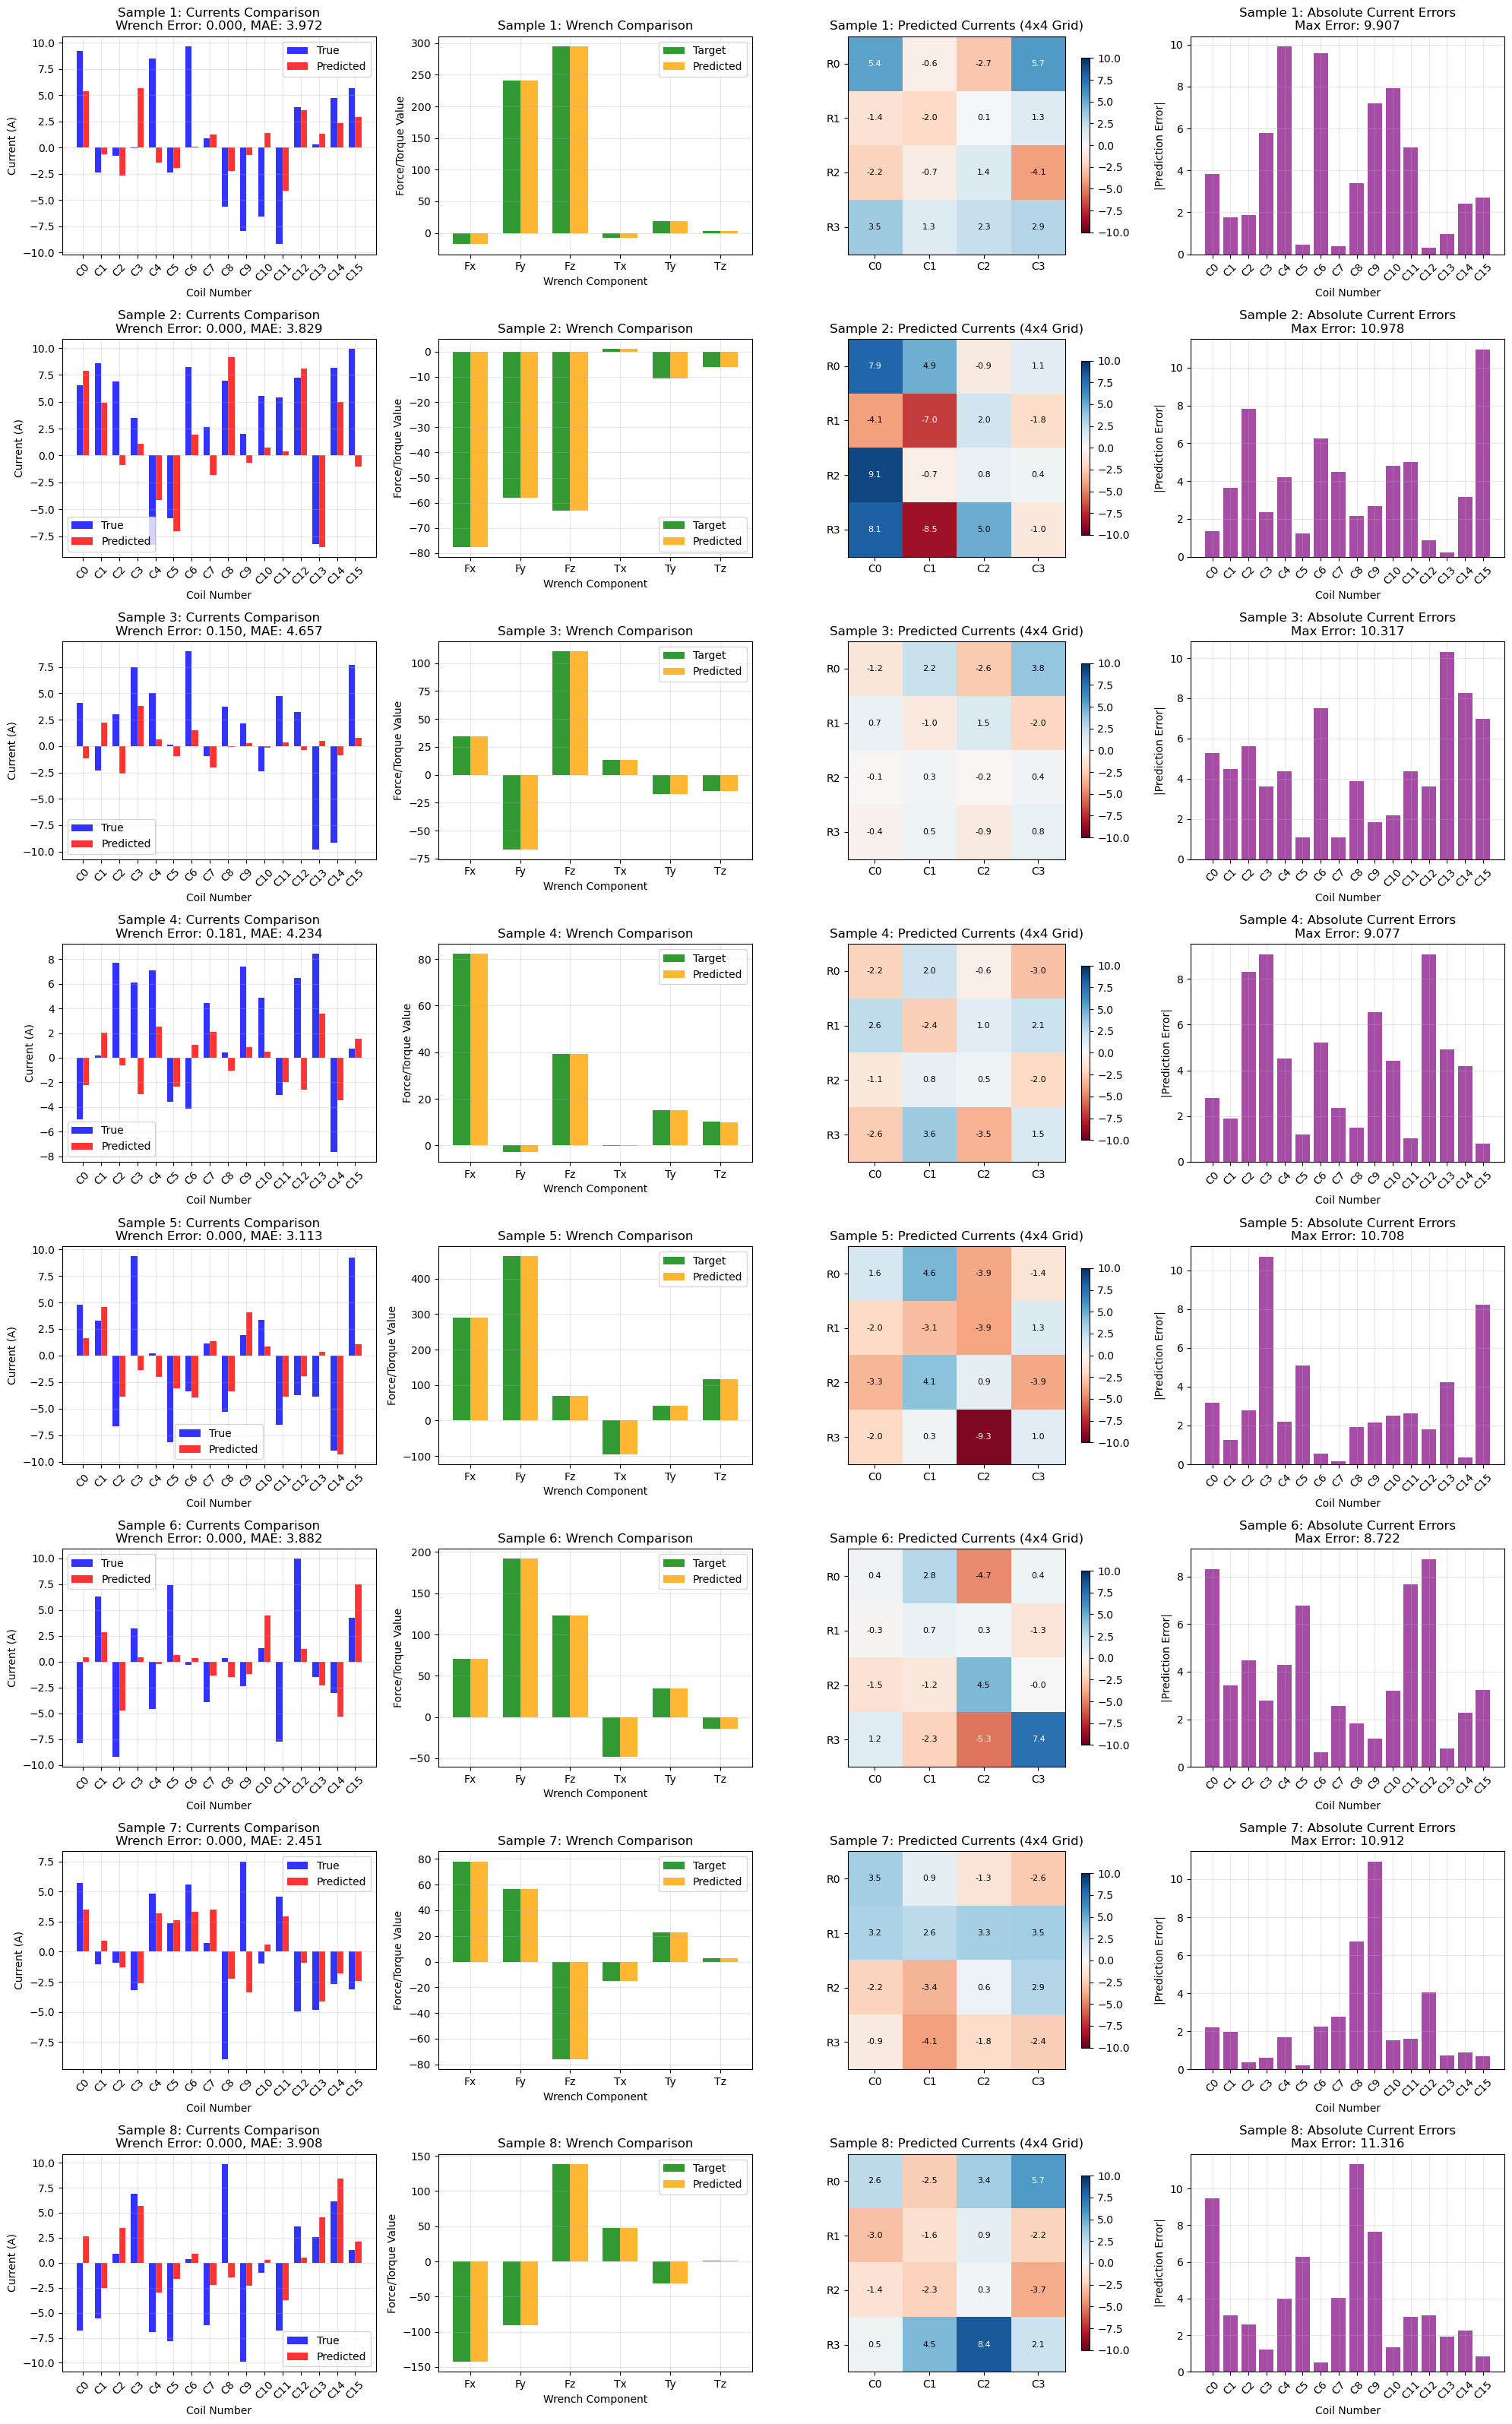

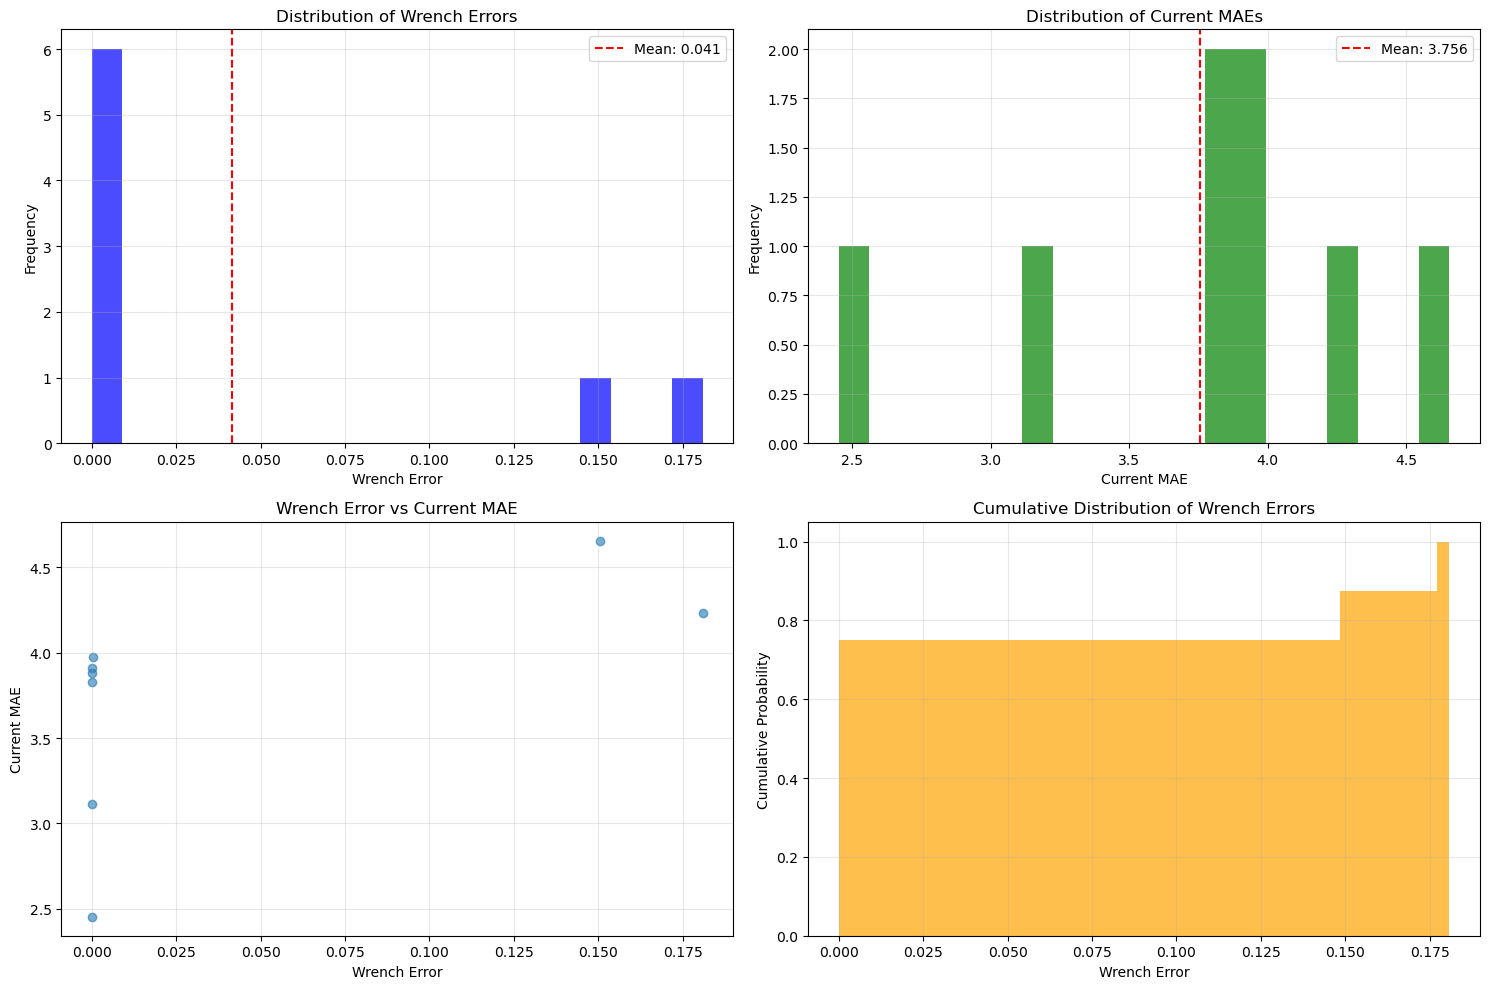


DETAILED PERFORMANCE STATISTICS
Wrench Errors:
  Mean: 0.0415
  Std:  0.0721
  Min:  0.0000
  Max:  0.1809
  Median: 0.0001

Current MAEs:
  Mean: 3.7558
  Std:  0.6371
  Min:  2.4512
  Max:  4.6572
  Median: 3.8951

Success Rates:
  Error < 0.5:  100.0%
  Error < 1.0:  100.0%
  Error < 2.0:  100.0%
  Error < 5.0:  100.0%
[MAIN] Testing completed successfully!
[MAIN] Check the generated plots for detailed results.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import pickle

def test_model_comprehensive(model_path, pose_scaler_path, wrench_scaler_path, csv_path_test, n_samples=10):
    """
    Test the trained model on multiple samples and create comprehensive visualizations
    """
    print("[TEST] Loading trained model...")
    # Load model
    model = PhysicsInformedNullspaceNet()
    # Initialize with dummy inputs
    dummy_X = tf.zeros((1,12), dtype=tf.float32)
    dummy_pose = tf.zeros((1,6), dtype=tf.float32)
    dummy_w = tf.zeros((1,6), dtype=tf.float32)
    _ = model(dummy_X, dummy_pose, dummy_w, training=False)
    model.load_weights(model_path)
    print("[TEST] Model loaded successfully")
    
    # Load scalers
    print("[TEST] Loading scalers...")
    with open(pose_scaler_path, 'rb') as f:
        pose_scaler = pickle.load(f)
    with open(wrench_scaler_path, 'rb') as f:
        wrench_scaler = pickle.load(f)
    print("[TEST] Scalers loaded")
    
    # Load test data
    print(f"[TEST] Loading test data from {csv_path_test}...")
    df = pd.read_csv(csv_path_test)
    if n_samples is None or n_samples >= len(df):
        test_samples = df
    else:
        test_samples = df.sample(n=n_samples, random_state=24)
    print(f"[TEST] Loaded {n_samples} test samples")
    
    # Store results
    results = []
    
    print("[TEST] Running predictions...")
    for idx, (_, sample) in enumerate(test_samples.iterrows()):
        print(f"  Processing sample {idx+1}/{n_samples}")
        
        # Extract data
        pose = np.array([sample['x_m'], sample['y_m'], sample['z_m'],
                        sample['alpha'], sample['beta'], sample['gamma']], dtype=np.float32)
        target_wrench = np.array([sample[f"wrench_{i}"] for i in range(6)], dtype=np.float32)
        true_currents = np.array([sample[f"I_{i}"] for i in range(16)], dtype=np.float32)
        
        # Normalize inputs
        pose_norm = pose_scaler.transform(pose.reshape(1, -1)).astype(np.float32)
        wrench_norm = wrench_scaler.transform(target_wrench.reshape(1, -1)).astype(np.float32)
        X = np.concatenate([pose_norm, wrench_norm], axis=1).astype(np.float32)
        
        # Predict (FIXED: unpack all 3 return values)
        I_pred, W_pred, z_pred = model(X, pose.reshape(1,6), target_wrench.reshape(1,6), training=False)
        I_pred = I_pred.numpy()[0]
        W_pred = W_pred.numpy()[0]
        # z_pred is not used but needs to be captured
        
        # Calculate errors
        wrench_error = np.linalg.norm(W_pred - target_wrench)
        current_error = np.linalg.norm(I_pred - true_currents)
        current_mae = np.mean(np.abs(I_pred - true_currents))
        
        results.append({
            'sample_idx': idx,
            'pose': pose,
            'target_wrench': target_wrench,
            'true_currents': true_currents,
            'pred_currents': I_pred,
            'pred_wrench': W_pred,
            'wrench_error': wrench_error,
            'current_error': current_error,
            'current_mae': current_mae
        })
    
    # Print summary statistics
    print("\n" + "="*50)
    print("TEST RESULTS SUMMARY")
    print("="*50)
    wrench_errors = [r['wrench_error'] for r in results]
    current_maes = [r['current_mae'] for r in results]
    
    print(f"Average Wrench Error: {np.mean(wrench_errors):.4f} ± {np.std(wrench_errors):.4f}")
    print(f"Average Current MAE: {np.mean(current_maes):.4f} ± {np.std(current_maes):.4f}")
    print(f"Min Wrench Error: {np.min(wrench_errors):.4f}")
    print(f"Max Wrench Error: {np.max(wrench_errors):.4f}")
    print(f"Success Rate (< 1.0): {np.mean(np.array(wrench_errors) < 1.0):.1%}")
    
    # Create comprehensive visualizations
    print("\n[TEST] Creating visualizations...")
    create_comprehensive_plots(results)
    
    return results

def create_comprehensive_plots(results):
    """
    Create comprehensive plots for model evaluation
    """
    n_samples = len(results)
    fig = plt.figure(figsize=(20, 4*n_samples))
    
    for i, result in enumerate(results):
        # Extract data
        true_currents = result['true_currents']
        pred_currents = result['pred_currents']
        target_wrench = result['target_wrench']
        pred_wrench = result['pred_wrench']
        wrench_error = result['wrench_error']
        current_mae = result['current_mae']
        
        # Create subplot grid (1 row, 4 columns)
        # Subplot 1: Currents comparison (bar chart)
        ax1 = plt.subplot(n_samples, 4, i*4 + 1)
        coil_indices = np.arange(16)
        width = 0.35
        ax1.bar(coil_indices - width/2, true_currents, width, label='True', alpha=0.8, color='blue')
        ax1.bar(coil_indices + width/2, pred_currents, width, label='Predicted', alpha=0.8, color='red')
        ax1.set_xlabel('Coil Number')
        ax1.set_ylabel('Current (A)')
        ax1.set_title(f'Sample {i+1}: Currents Comparison\nWrench Error: {wrench_error:.3f}, MAE: {current_mae:.3f}')
        ax1.set_xticks(coil_indices)
        ax1.set_xticklabels([f'C{j}' for j in range(16)], rotation=45)
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Subplot 2: Wrench comparison
        ax2 = plt.subplot(n_samples, 4, i*4 + 2)
        wrench_labels = ['Fx', 'Fy', 'Fz', 'Tx', 'Ty', 'Tz']
        x_pos = np.arange(6)
        width = 0.35
        ax2.bar(x_pos - width/2, target_wrench, width, label='Target', alpha=0.8, color='green')
        ax2.bar(x_pos + width/2, pred_wrench, width, label='Predicted', alpha=0.8, color='orange')
        ax2.set_xlabel('Wrench Component')
        ax2.set_ylabel('Force/Torque Value')
        ax2.set_title(f'Sample {i+1}: Wrench Comparison')
        ax2.set_xticks(x_pos)
        ax2.set_xticklabels(wrench_labels)
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        # Subplot 3: Current distribution heatmap (predicted)
        ax3 = plt.subplot(n_samples, 4, i*4 + 3)
        pred_grid = pred_currents.reshape(4, 4)
        im3 = ax3.imshow(pred_grid, cmap='RdBu', vmin=-10, vmax=10)
        ax3.set_title(f'Sample {i+1}: Predicted Currents (4x4 Grid)')
        ax3.set_xticks(range(4))
        ax3.set_yticks(range(4))
        ax3.set_xticklabels([f'C{j}' for j in range(4)])
        ax3.set_yticklabels([f'R{j}' for j in range(4)])
        
        # Add text annotations
        for row in range(4):
            for col in range(4):
                ax3.text(col, row, f'{pred_grid[row,col]:.1f}', 
                        ha='center', va='center', fontsize=8, 
                        color='white' if abs(pred_grid[row,col]) > 5 else 'black')
        
        plt.colorbar(im3, ax=ax3, shrink=0.8)
        
        # Subplot 4: Error analysis
        ax4 = plt.subplot(n_samples, 4, i*4 + 4)
        errors = pred_currents - true_currents
        ax4.bar(coil_indices, np.abs(errors), alpha=0.7, color='purple')
        ax4.set_xlabel('Coil Number')
        ax4.set_ylabel('|Prediction Error|')
        ax4.set_title(f'Sample {i+1}: Absolute Current Errors\nMax Error: {np.max(np.abs(errors)):.3f}')
        ax4.set_xticks(coil_indices)
        ax4.set_xticklabels([f'C{j}' for j in range(16)], rotation=45)
        ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('model_test_results_comprehensive.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Create summary plots
    create_summary_plots(results)

def create_summary_plots(results):
    """
    Create summary plots showing overall model performance
    """
    # Extract metrics
    wrench_errors = [r['wrench_error'] for r in results]
    current_maes = [r['current_mae'] for r in results]
    current_rmses = [r['current_error'] for r in results]
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Wrench error distribution
    axes[0,0].hist(wrench_errors, bins=20, alpha=0.7, color='blue')
    axes[0,0].set_xlabel('Wrench Error')
    axes[0,0].set_ylabel('Frequency')
    axes[0,0].set_title('Distribution of Wrench Errors')
    axes[0,0].axvline(np.mean(wrench_errors), color='red', linestyle='--', 
                     label=f'Mean: {np.mean(wrench_errors):.3f}')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)
    
    # Current MAE distribution
    axes[0,1].hist(current_maes, bins=20, alpha=0.7, color='green')
    axes[0,1].set_xlabel('Current MAE')
    axes[0,1].set_ylabel('Frequency')
    axes[0,1].set_title('Distribution of Current MAEs')
    axes[0,1].axvline(np.mean(current_maes), color='red', linestyle='--',
                     label=f'Mean: {np.mean(current_maes):.3f}')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)
    
    # Wrench error vs Current MAE scatter
    axes[1,0].scatter(wrench_errors, current_maes, alpha=0.6)
    axes[1,0].set_xlabel('Wrench Error')
    axes[1,0].set_ylabel('Current MAE')
    axes[1,0].set_title('Wrench Error vs Current MAE')
    axes[1,0].grid(True, alpha=0.3)
    
    # Cumulative distribution
    axes[1,1].hist(wrench_errors, bins=50, cumulative=True, density=True, alpha=0.7, color='orange')
    axes[1,1].set_xlabel('Wrench Error')
    axes[1,1].set_ylabel('Cumulative Probability')
    axes[1,1].set_title('Cumulative Distribution of Wrench Errors')
    axes[1,1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('model_performance_summary.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print detailed statistics
    print("\n" + "="*60)
    print("DETAILED PERFORMANCE STATISTICS")
    print("="*60)
    print(f"Wrench Errors:")
    print(f"  Mean: {np.mean(wrench_errors):.4f}")
    print(f"  Std:  {np.std(wrench_errors):.4f}")
    print(f"  Min:  {np.min(wrench_errors):.4f}")
    print(f"  Max:  {np.max(wrench_errors):.4f}")
    print(f"  Median: {np.median(wrench_errors):.4f}")
    
    print(f"\nCurrent MAEs:")
    print(f"  Mean: {np.mean(current_maes):.4f}")
    print(f"  Std:  {np.std(current_maes):.4f}")
    print(f"  Min:  {np.min(current_maes):.4f}")
    print(f"  Max:  {np.max(current_maes):.4f}")
    print(f"  Median: {np.median(current_maes):.4f}")
    
    print(f"\nSuccess Rates:")
    print(f"  Error < 0.5:  {np.mean(np.array(wrench_errors) < 0.5):.1%}")
    print(f"  Error < 1.0:  {np.mean(np.array(wrench_errors) < 1.0):.1%}")
    print(f"  Error < 2.0:  {np.mean(np.array(wrench_errors) < 2.0):.1%}")
    print(f"  Error < 5.0:  {np.mean(np.array(wrench_errors) < 5.0):.1%}")

# Add this to your main execution block:
if __name__ == "__main__":
    # Test the trained model
    print("[MAIN] Starting comprehensive model testing...")
    try:
        results = test_model_comprehensive(
            model_path="ML2_ns_policy.weights.h5",
            pose_scaler_path="ML2_pose_scaler.pkl", 
            wrench_scaler_path="ML2_wrench_scaler.pkl",
            csv_path_test="ML_Dataset_test.csv",  # <-- use the held-out file
            n_samples=8
        )
        print("[MAIN] Testing completed successfully!")
        print("[MAIN] Check the generated plots for detailed results.")
    except Exception as e:
        print(f"[ERROR] Testing failed: {e}")
        import traceback
        traceback.print_exc()

[MAIN] Starting comprehensive dataset investigation...
[INVESTIGATION] Loading dataset...
[INVESTIGATION] Dataset shape: (10000, 28)
[INVESTIGATION] Creating comprehensive analysis plots...


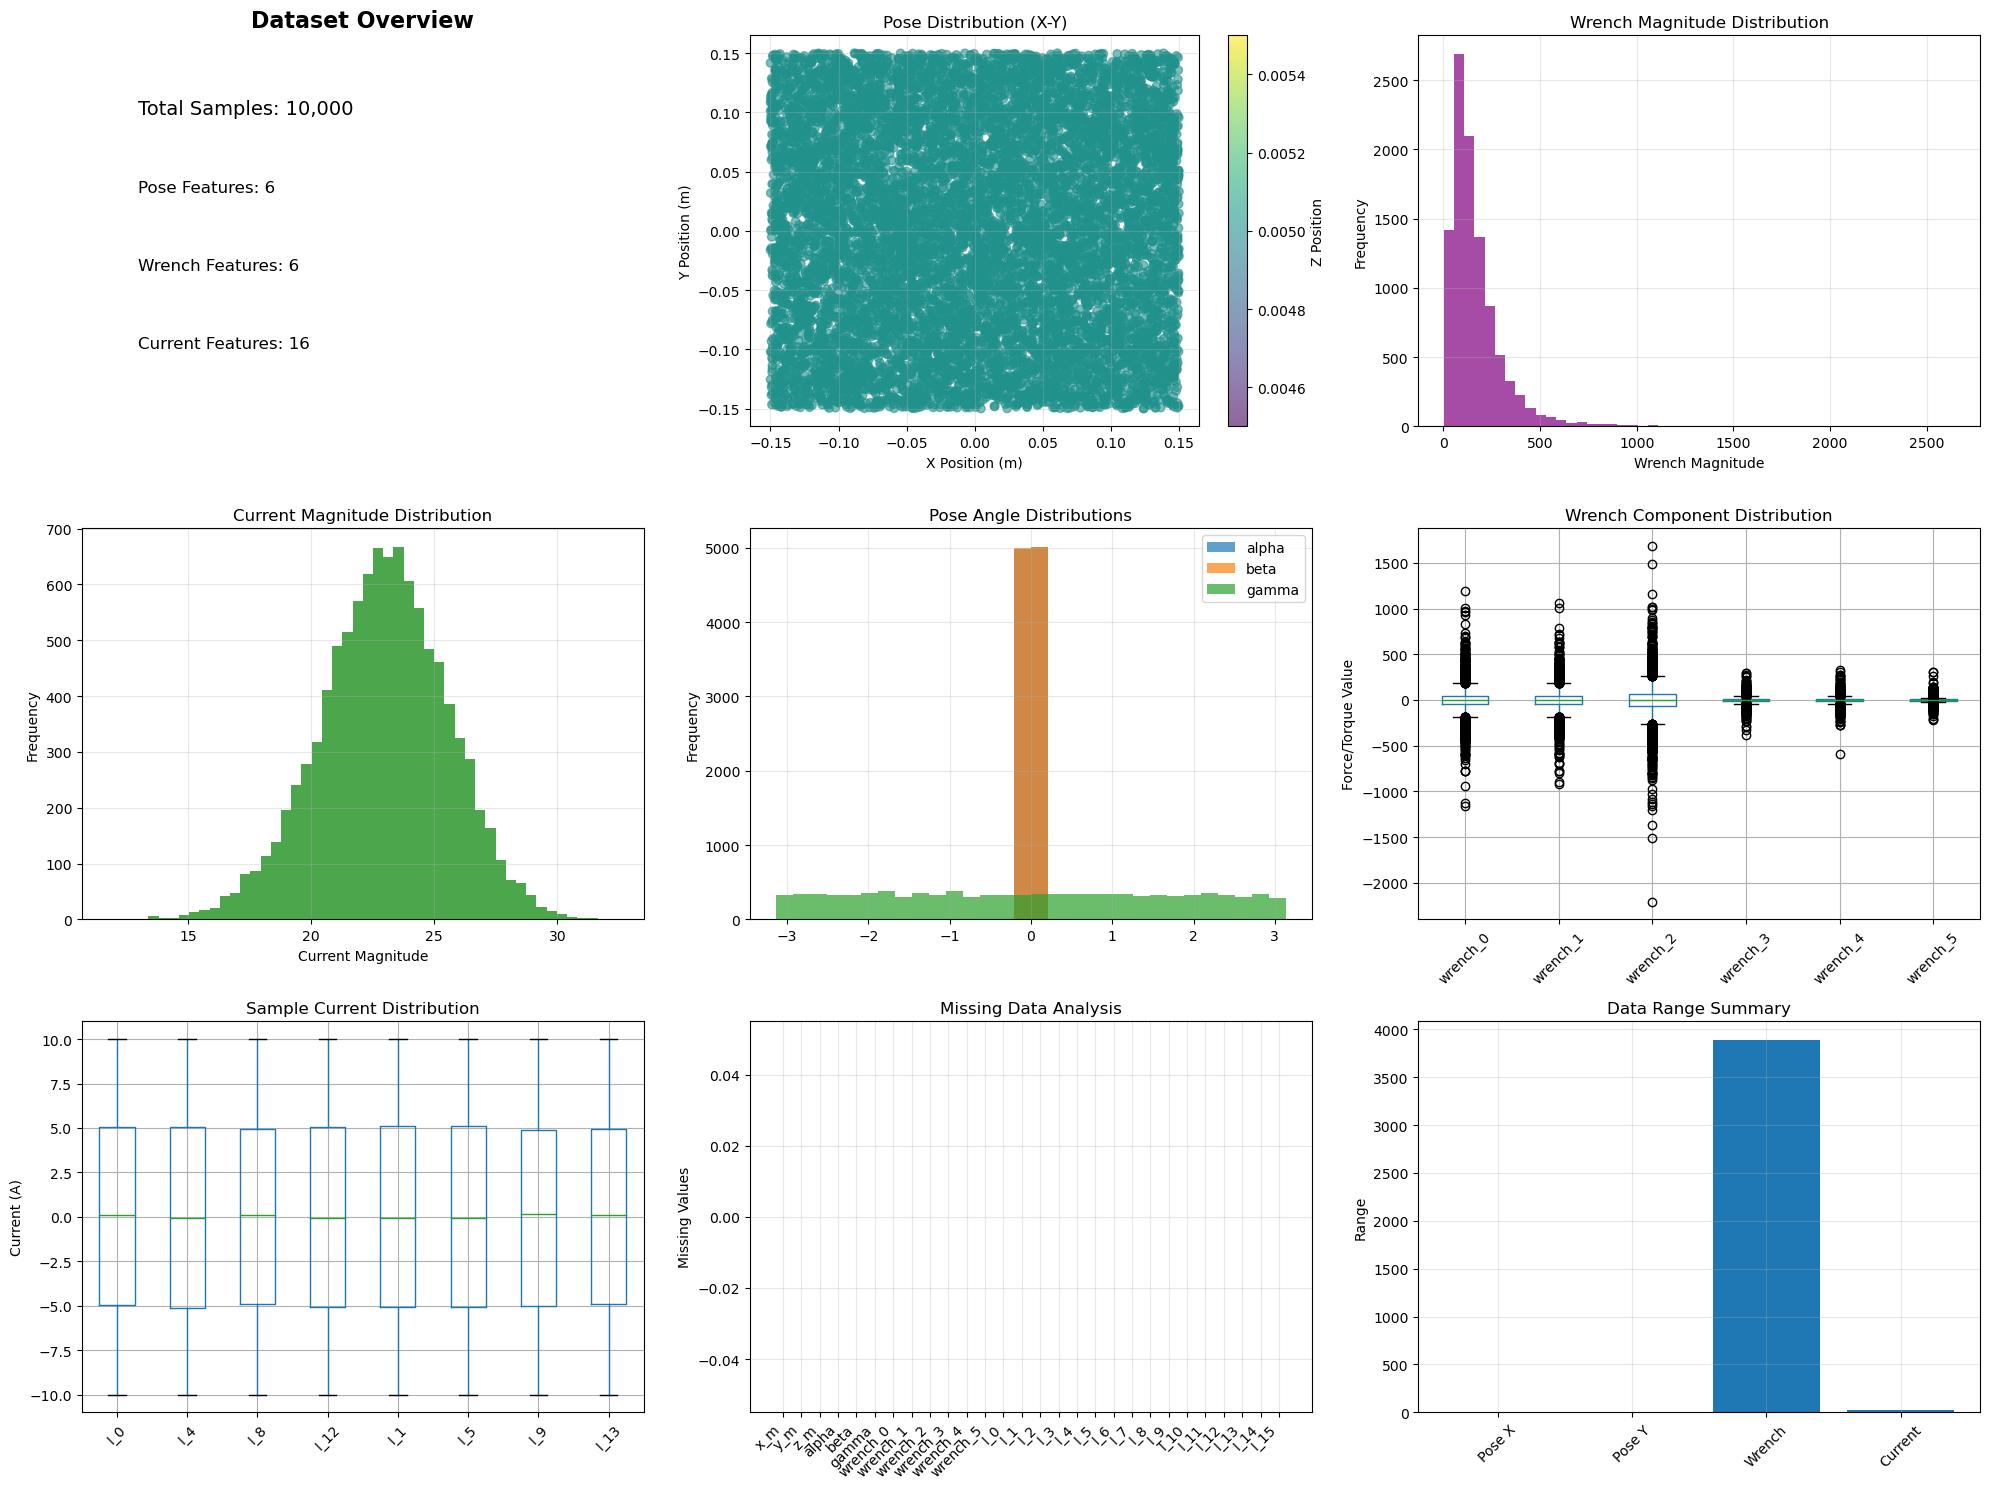

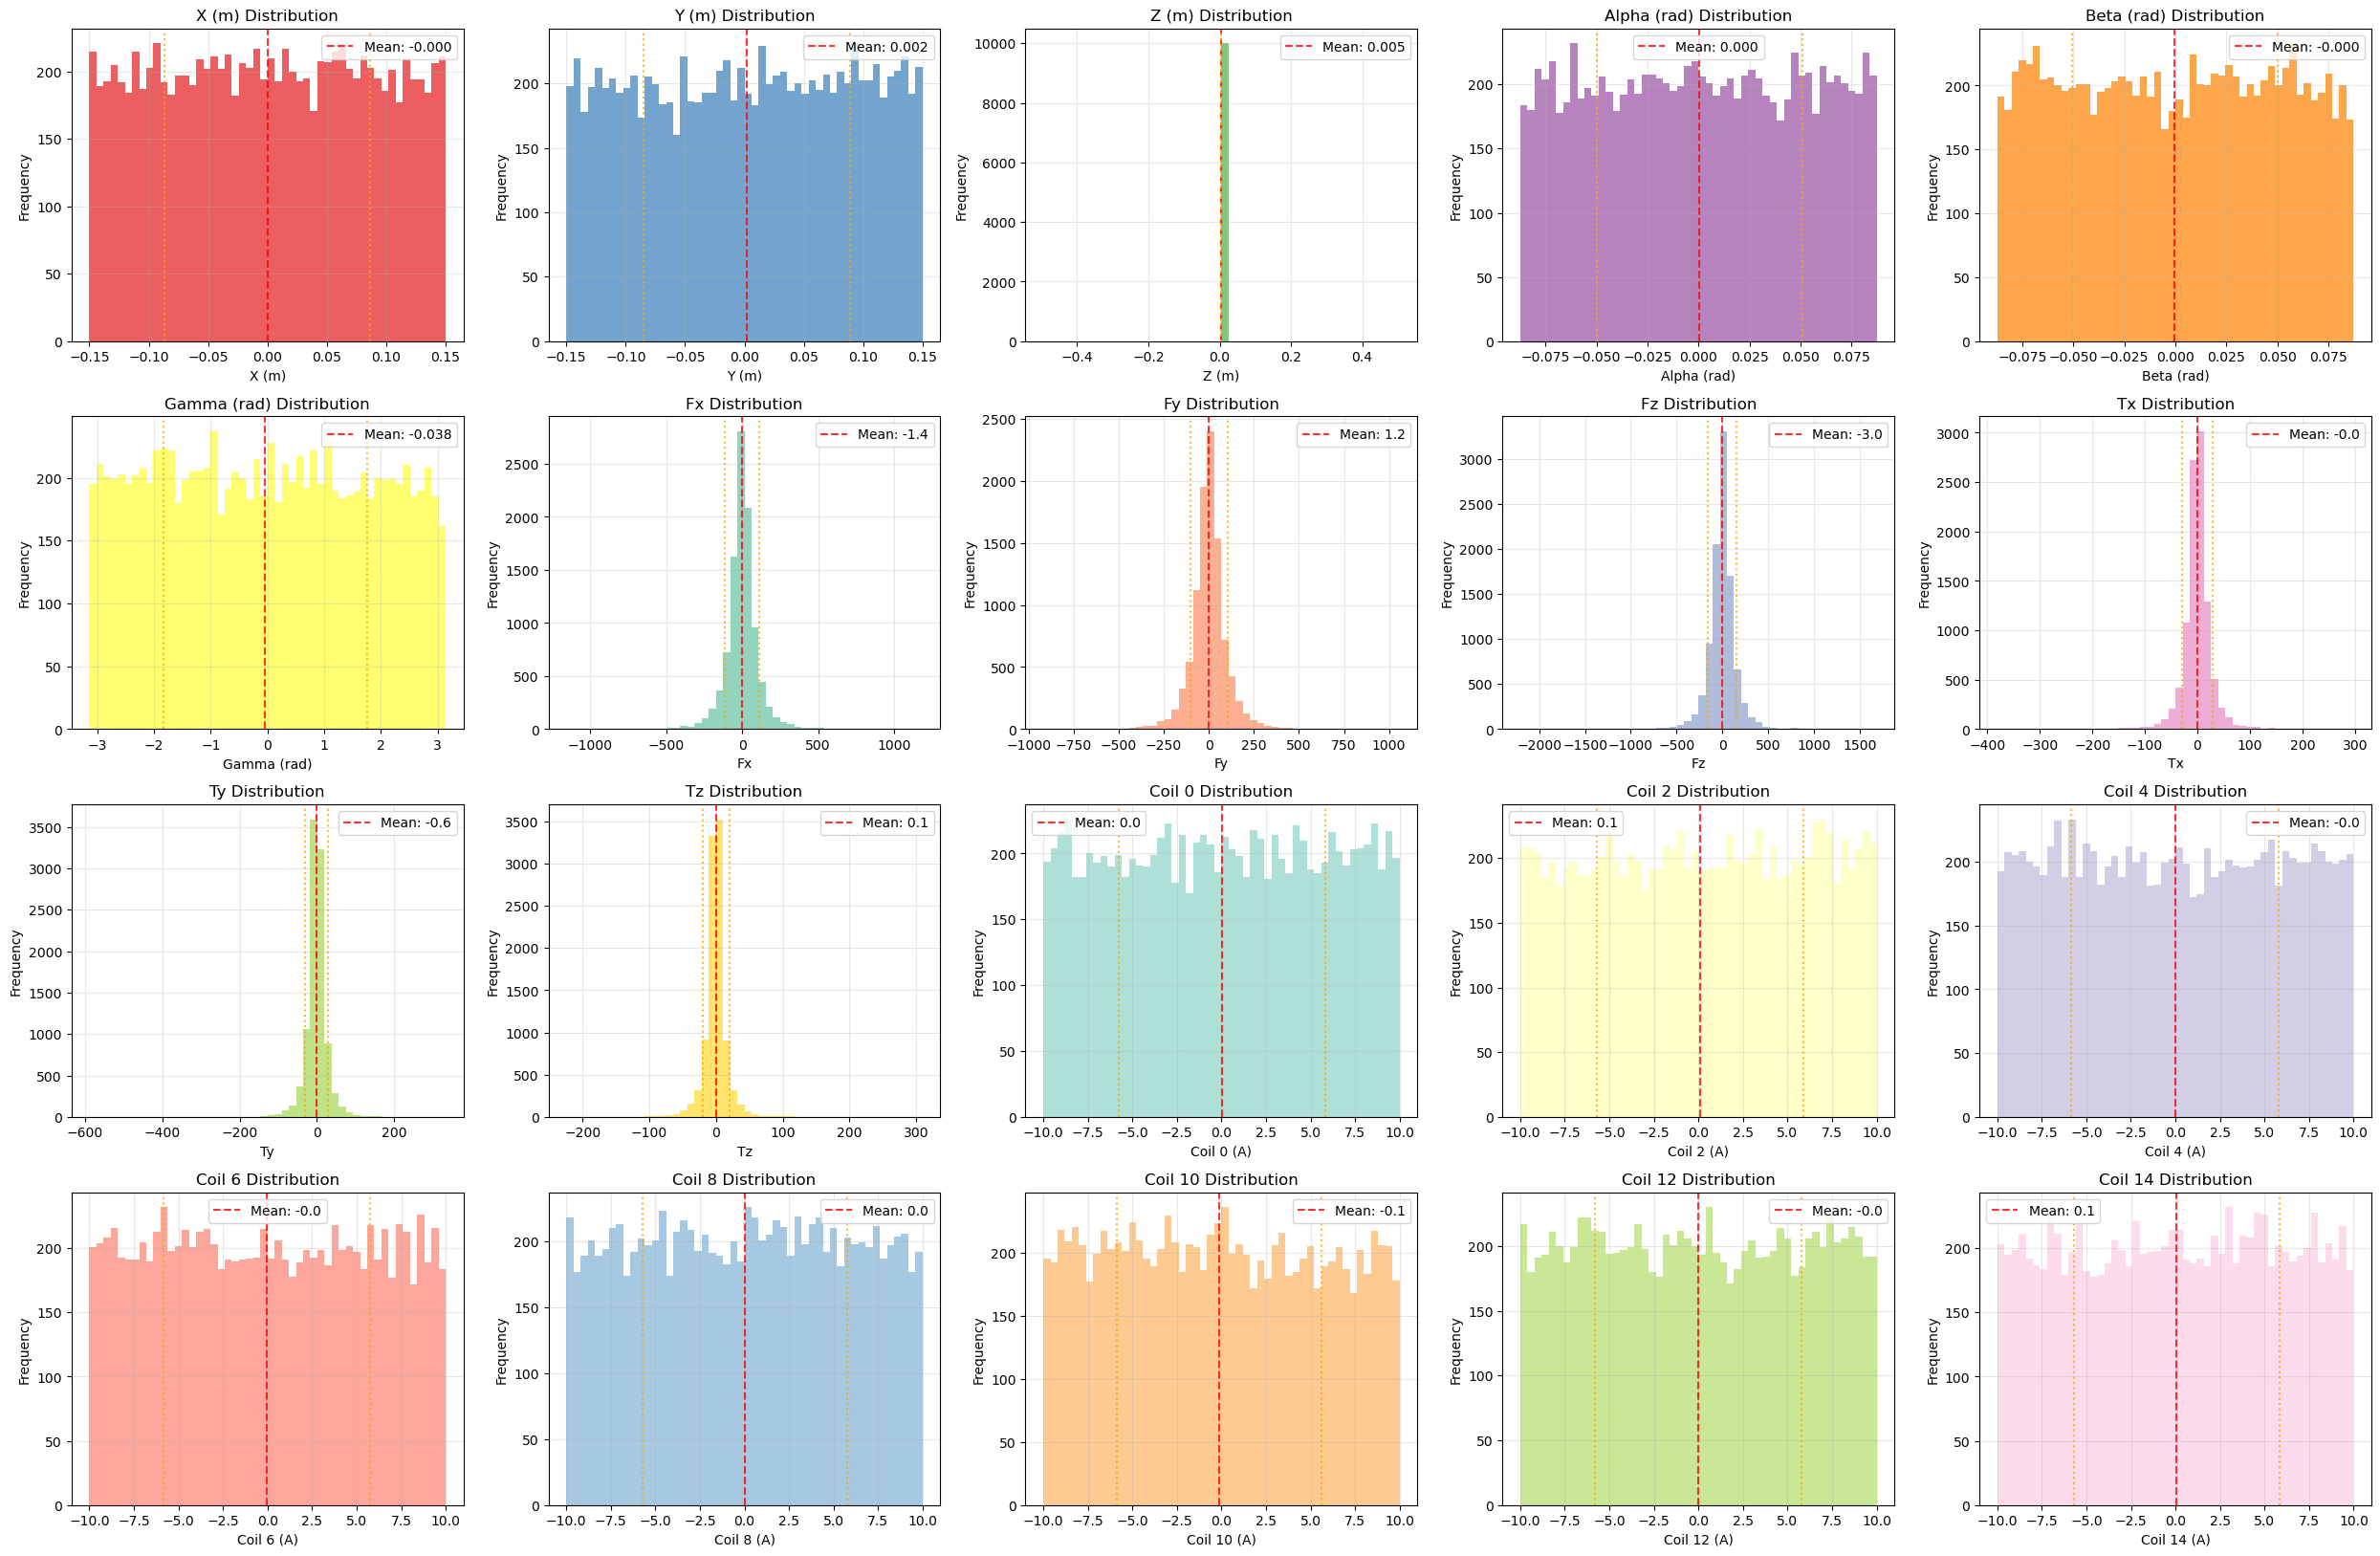

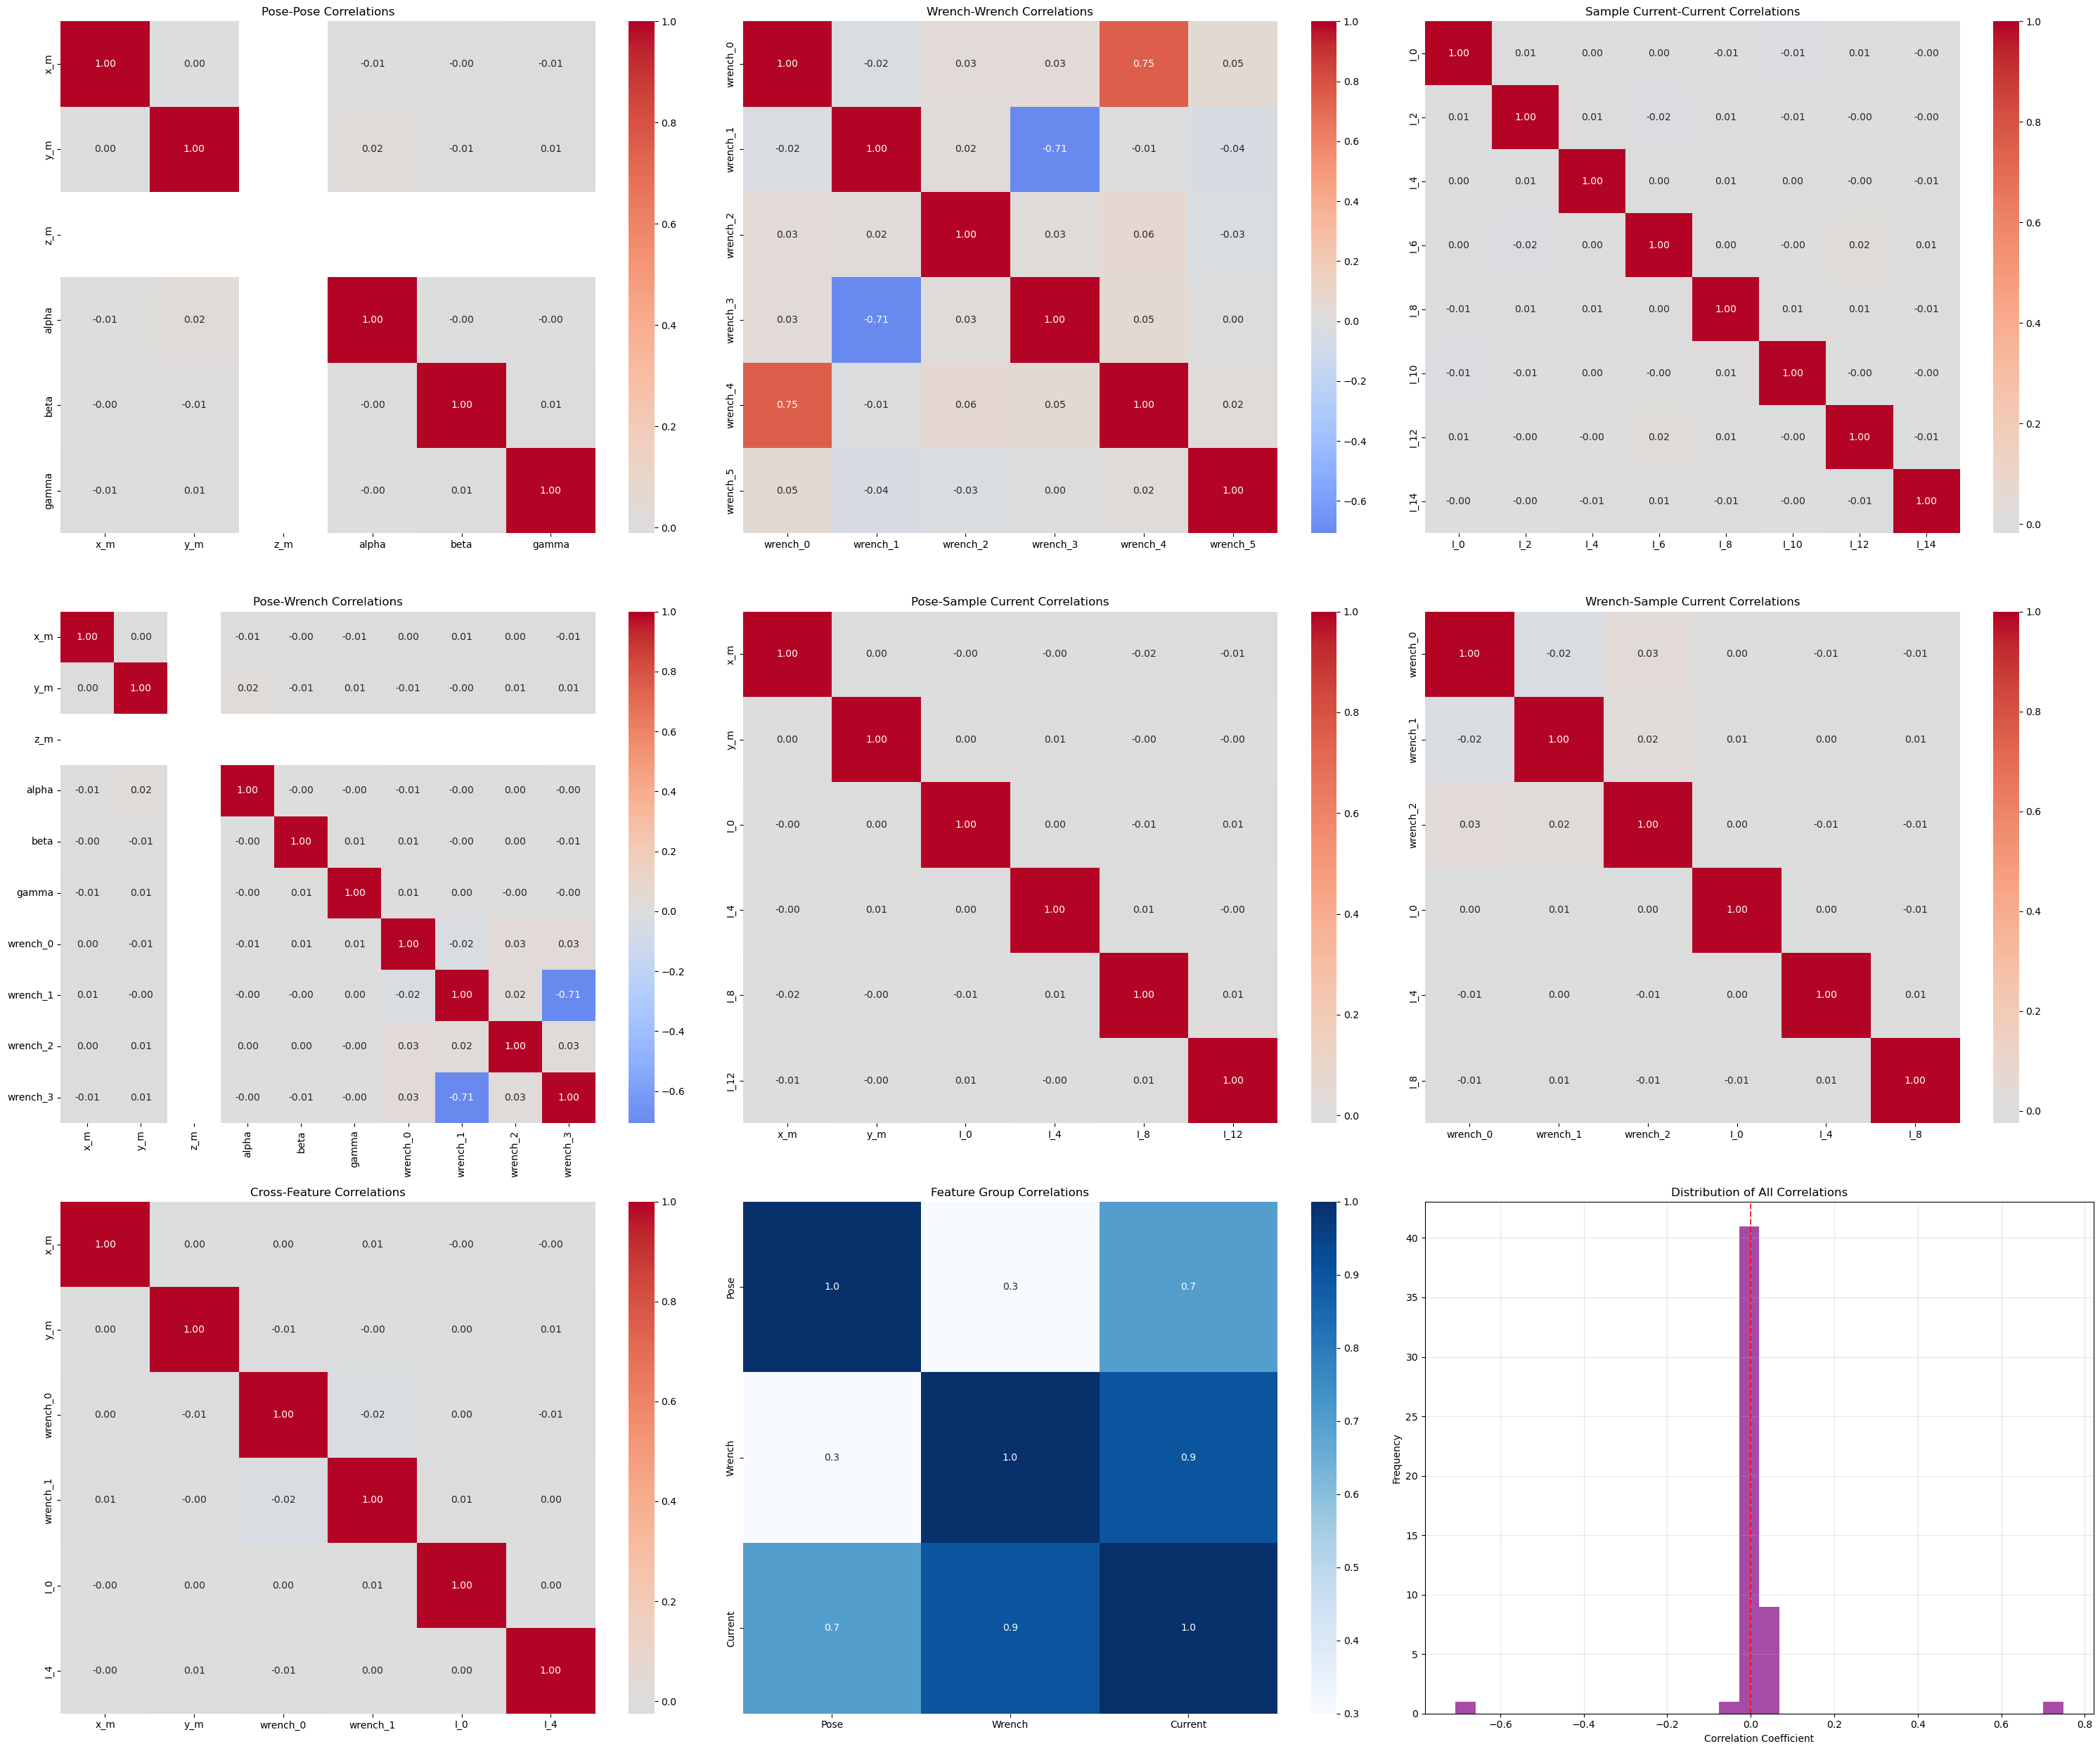

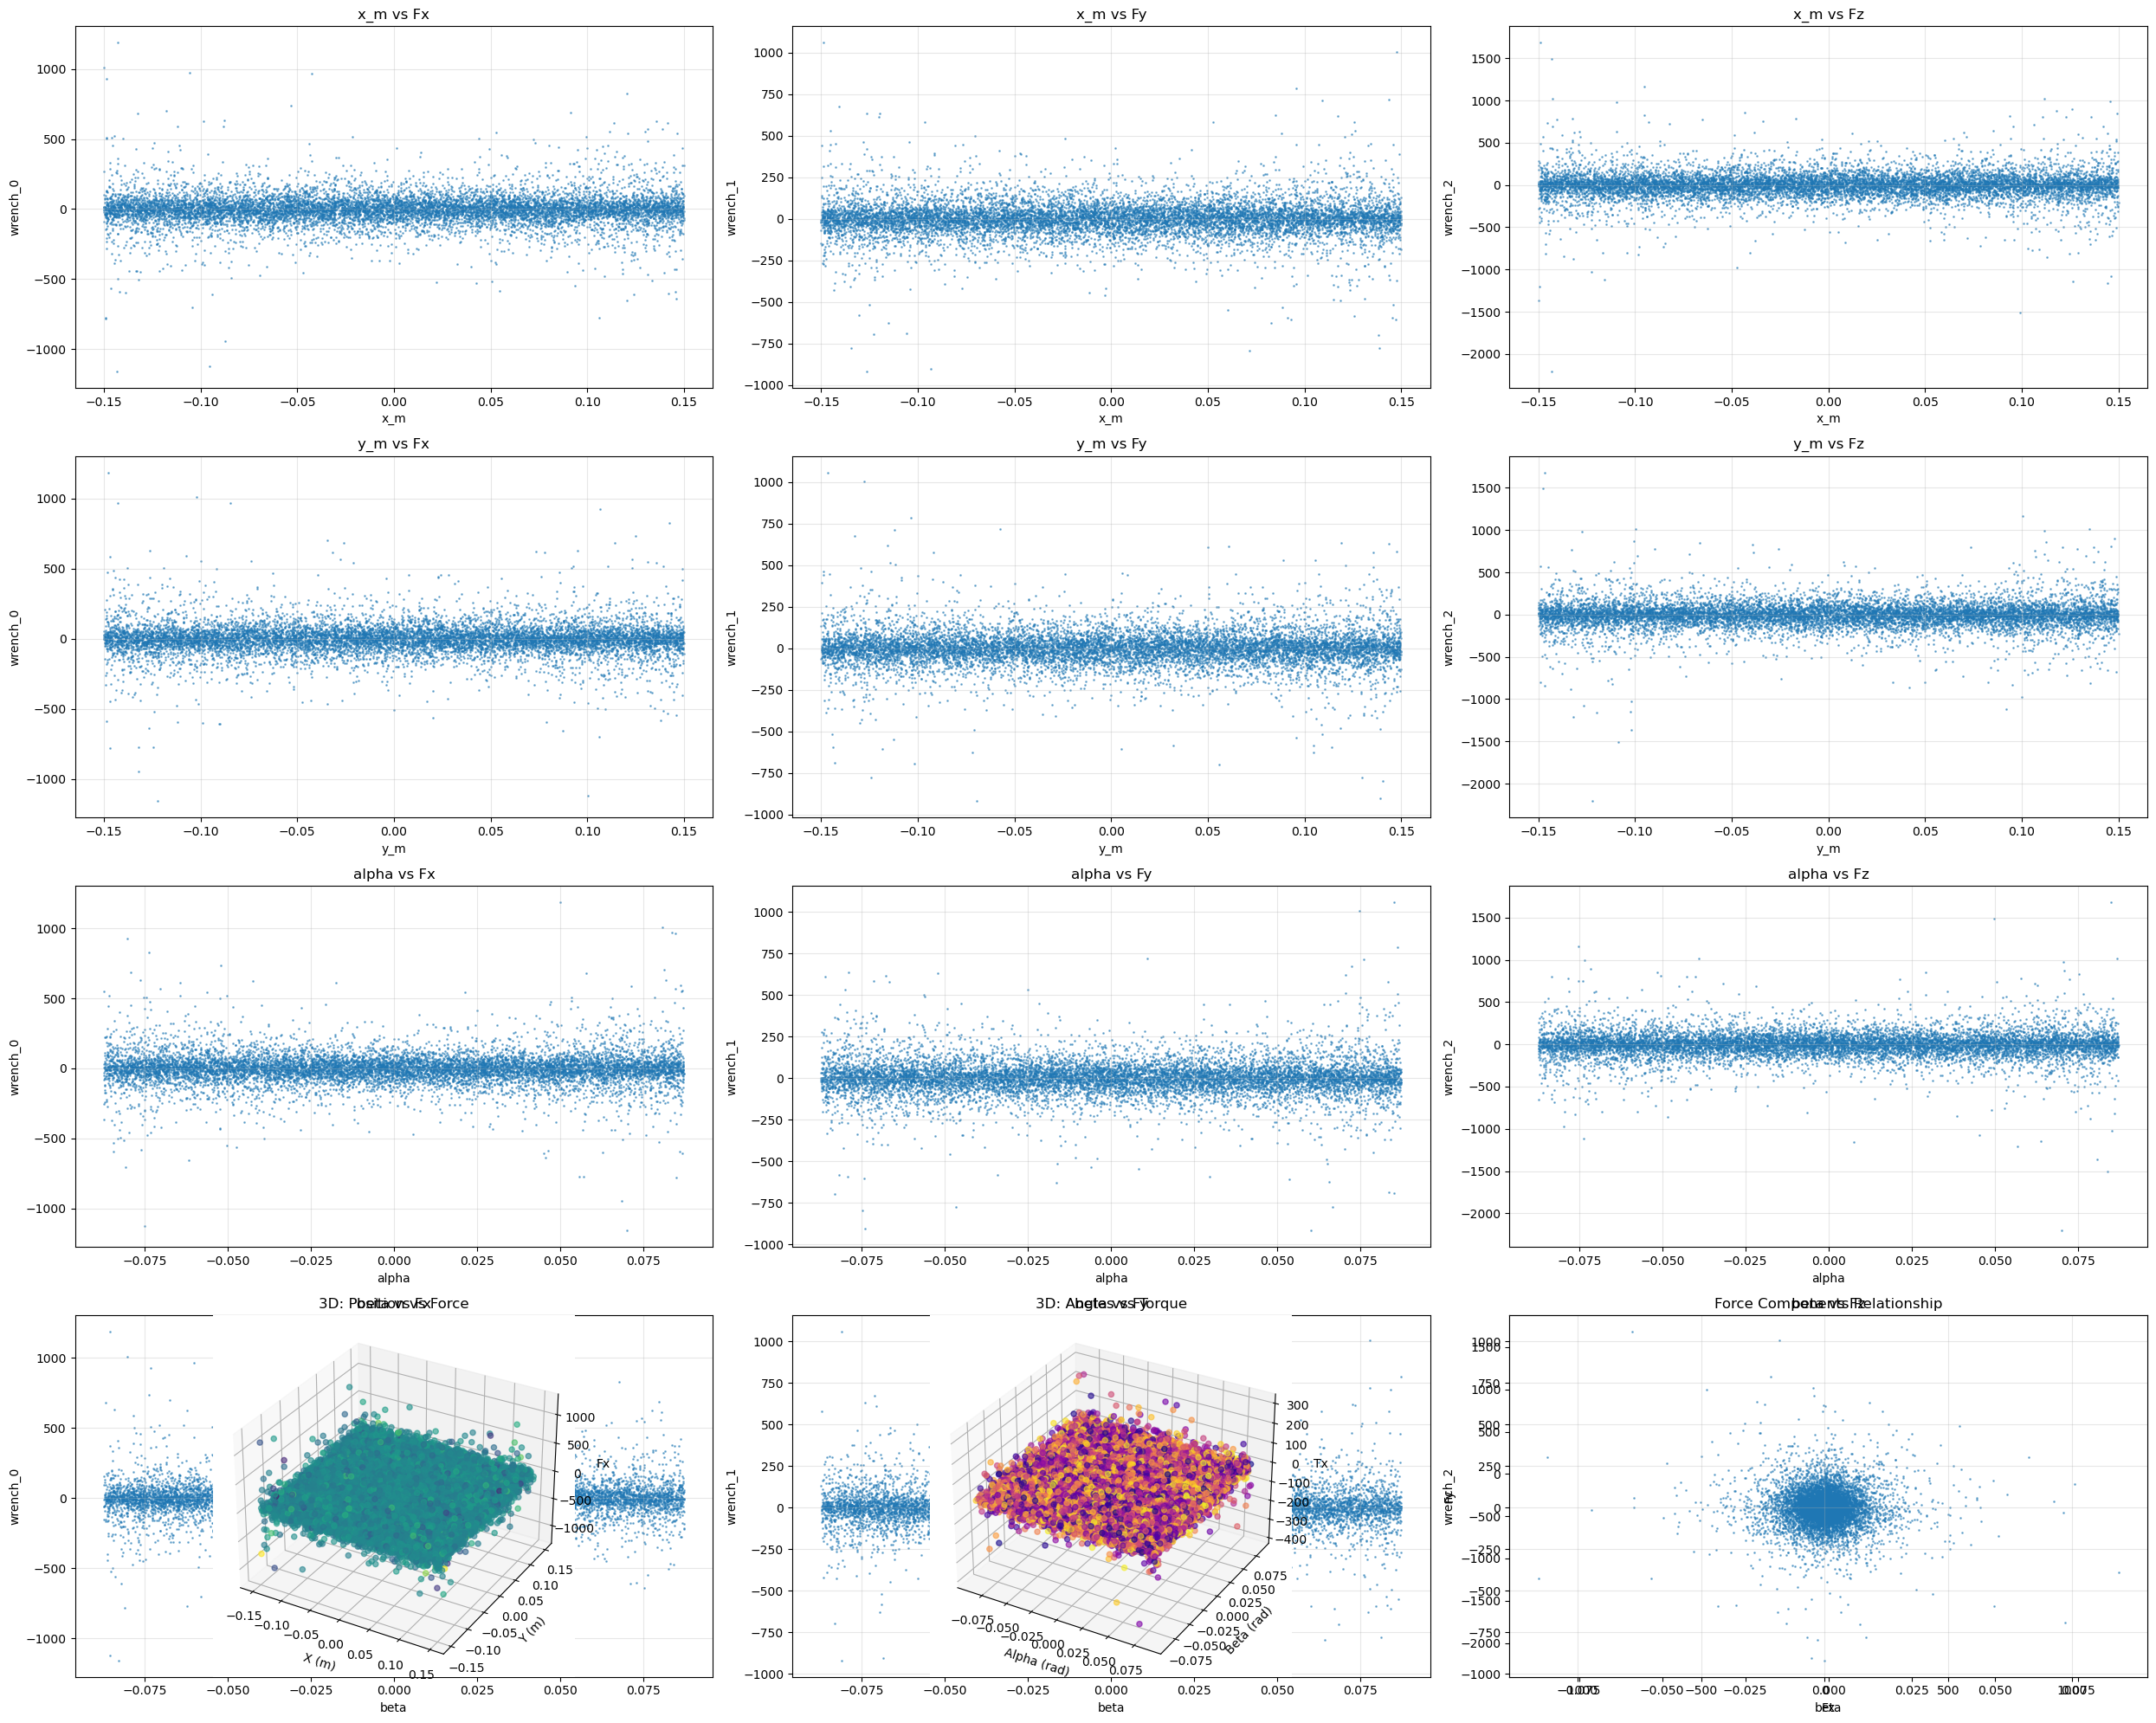

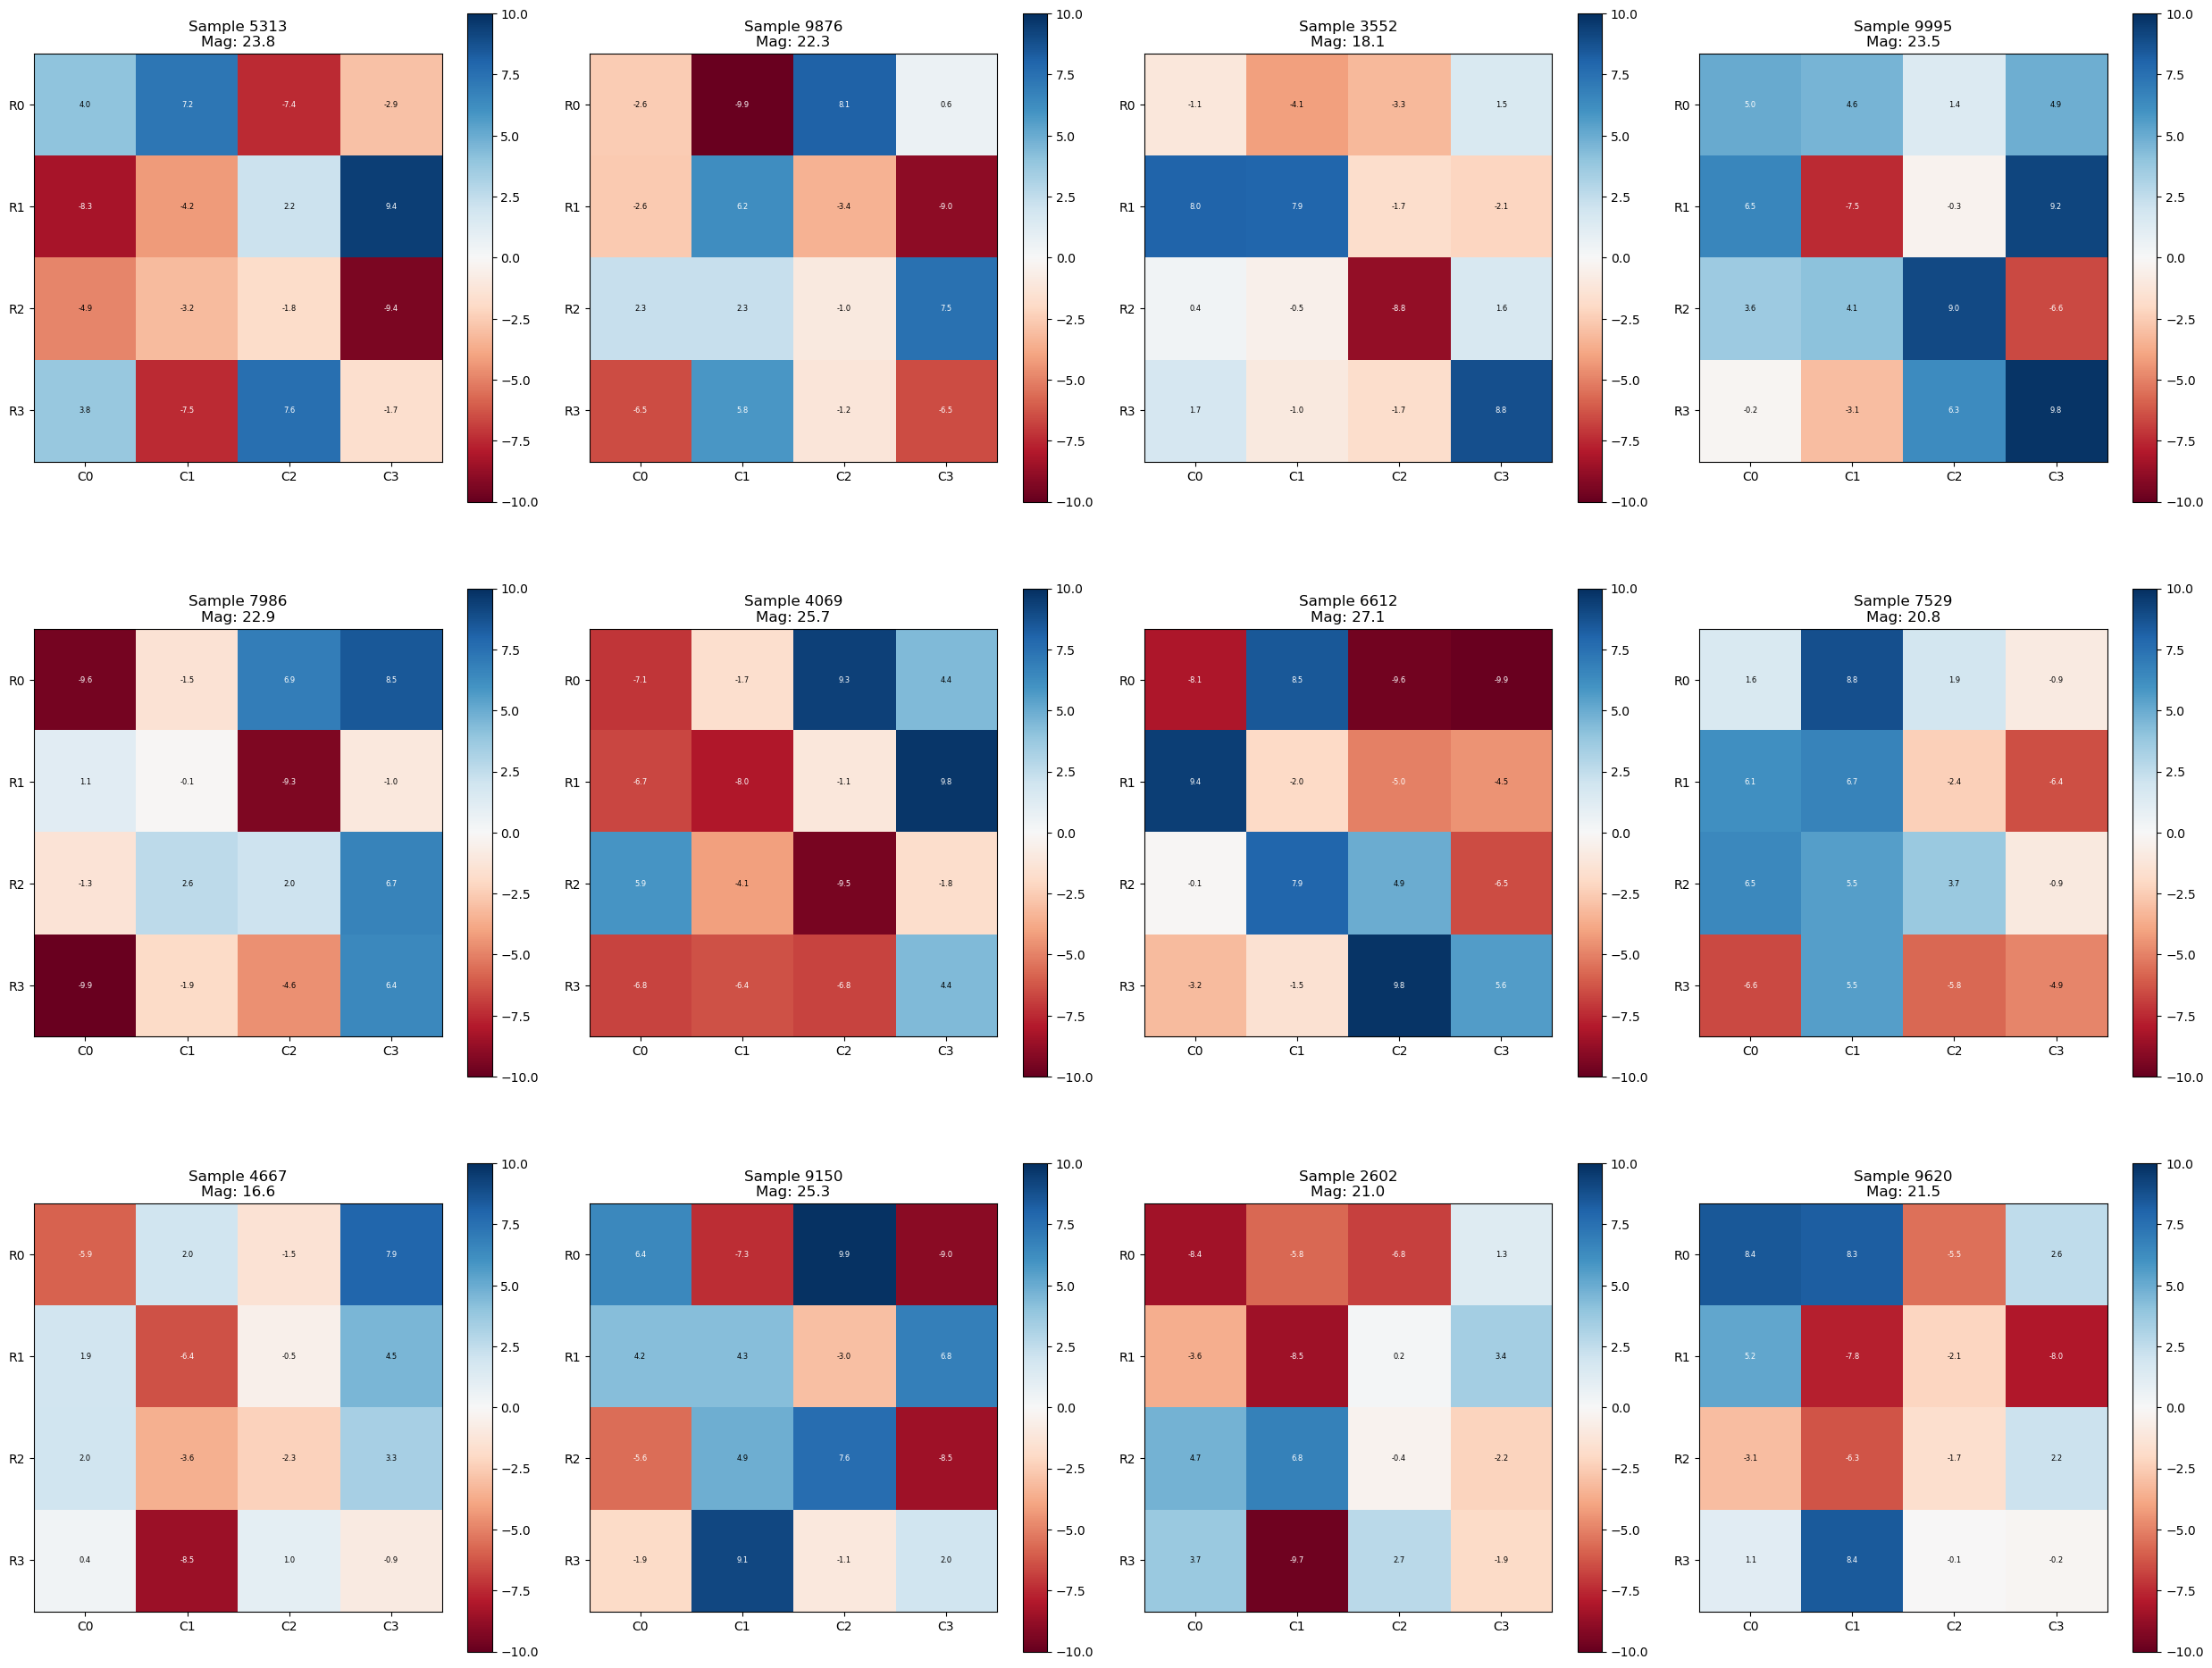

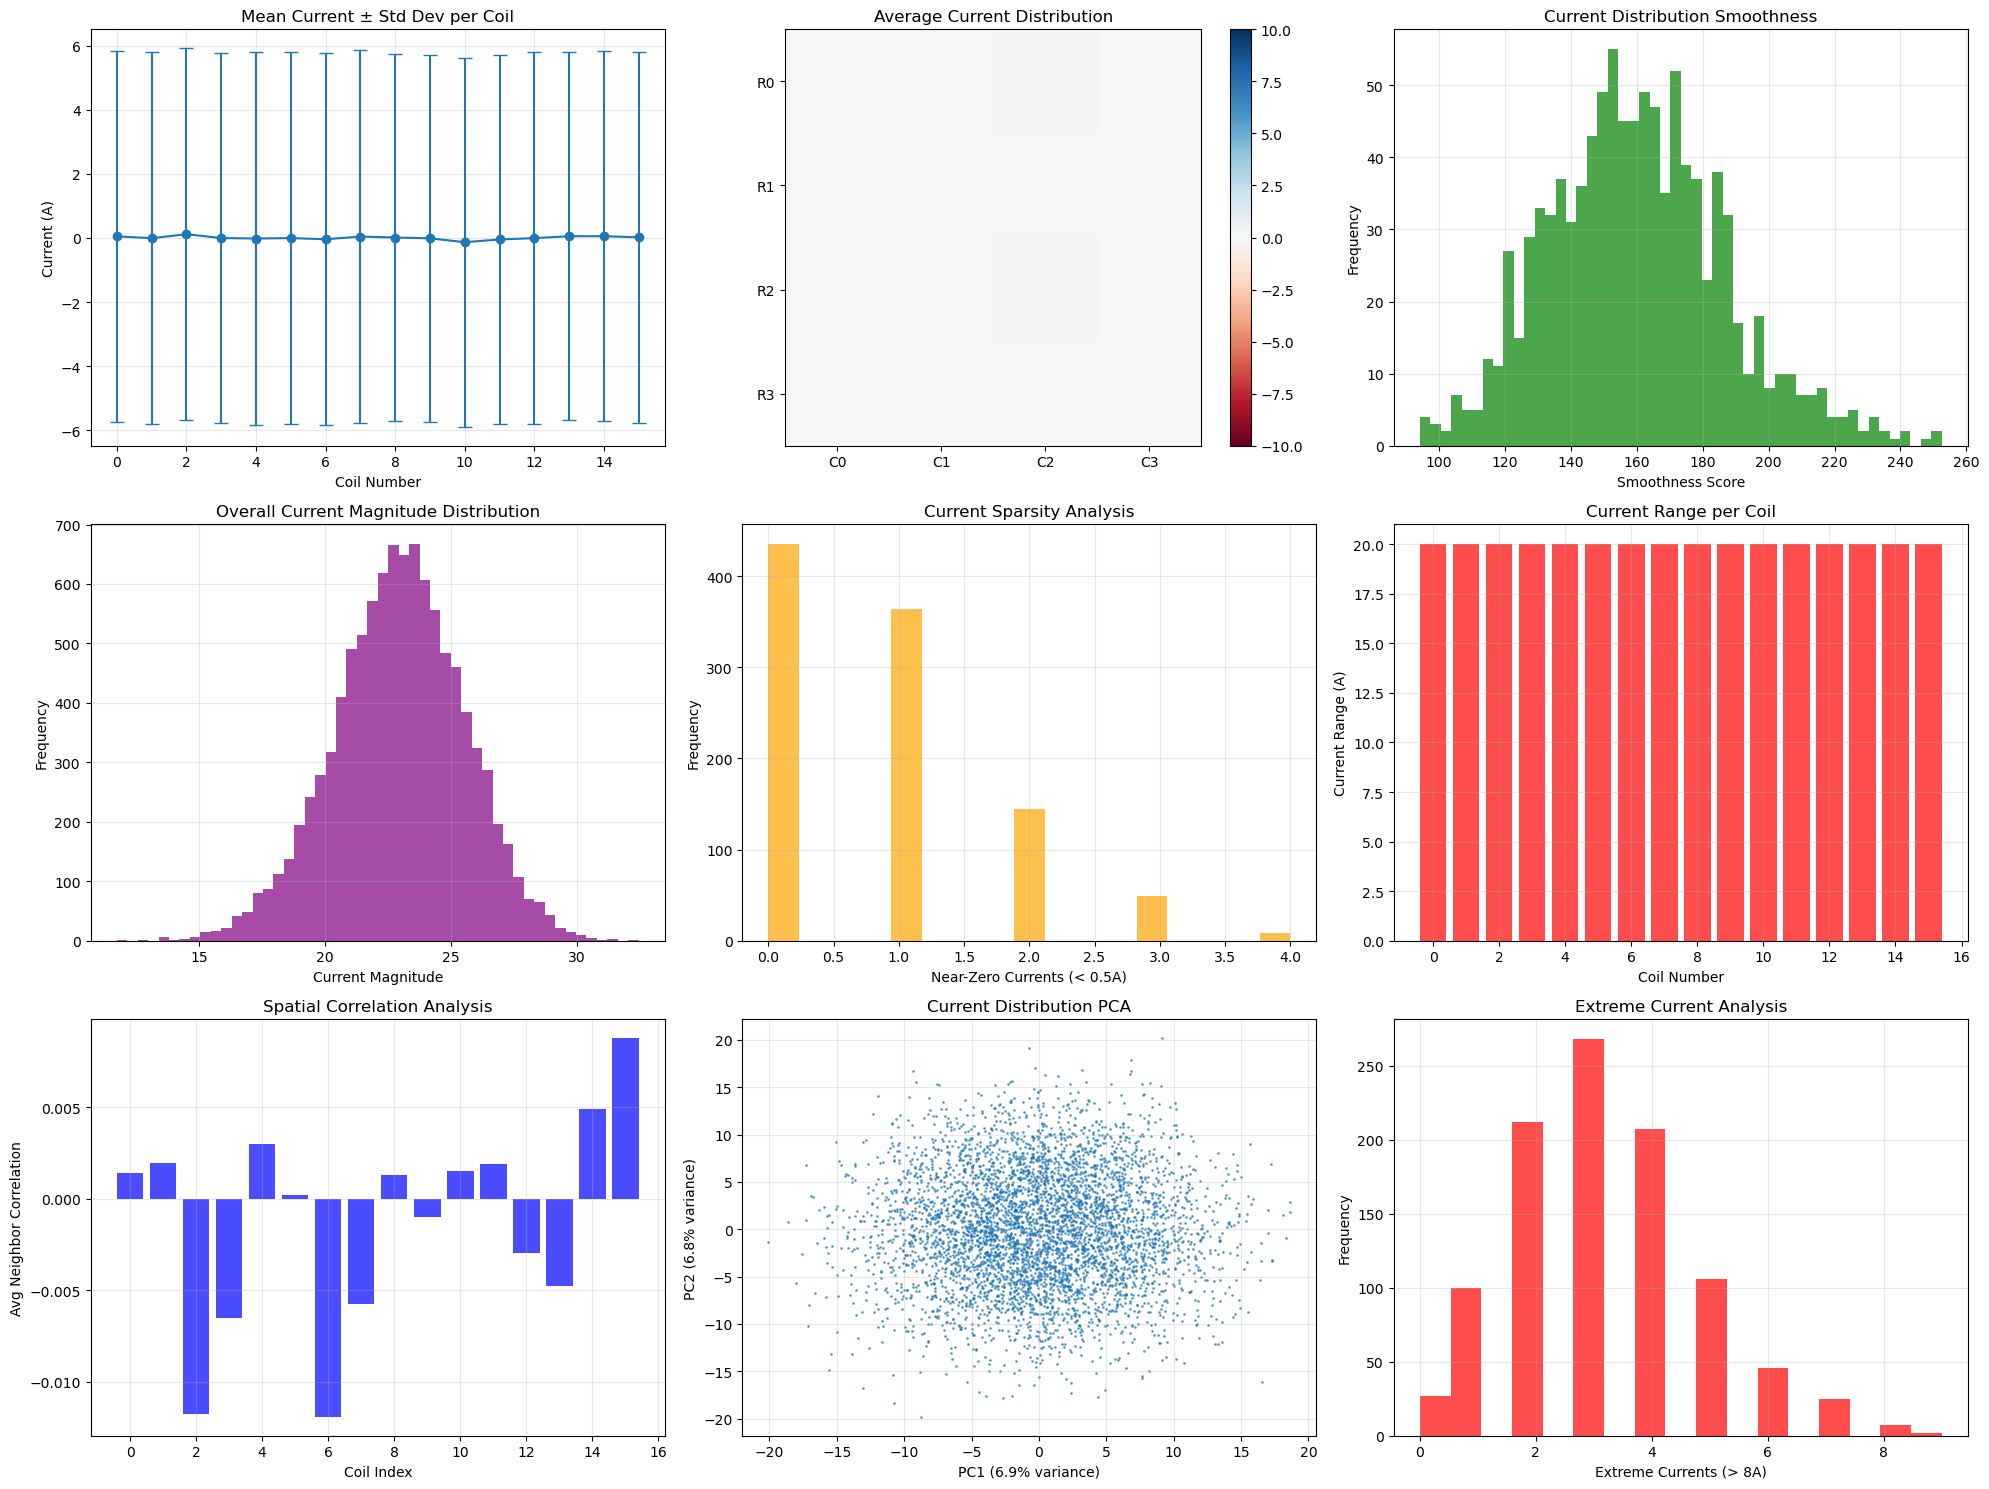

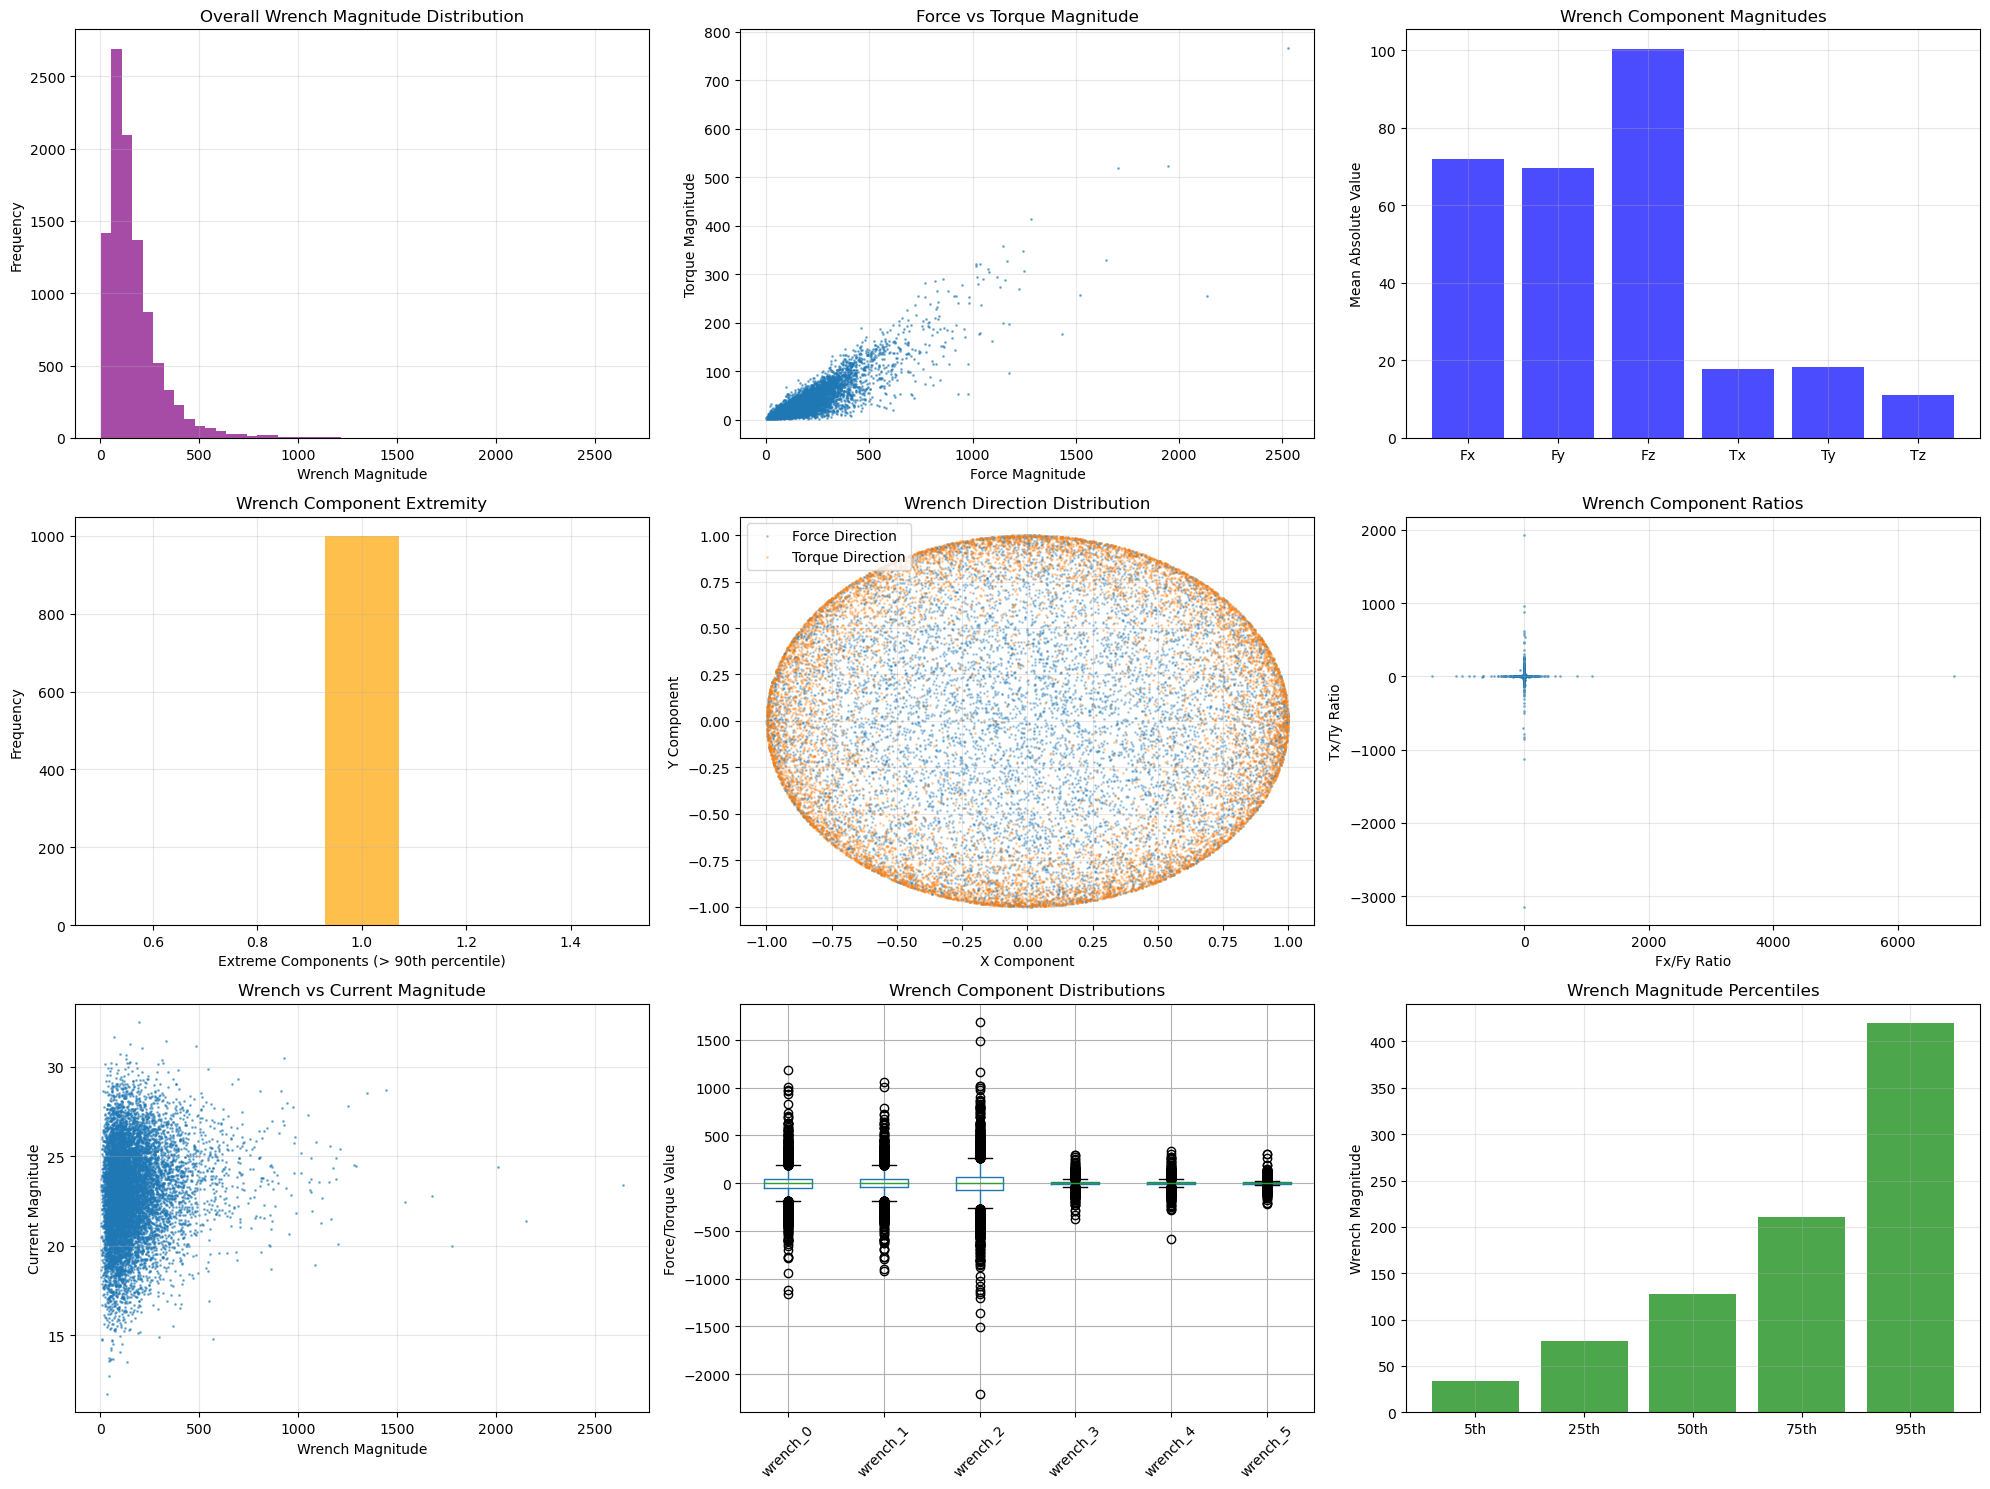

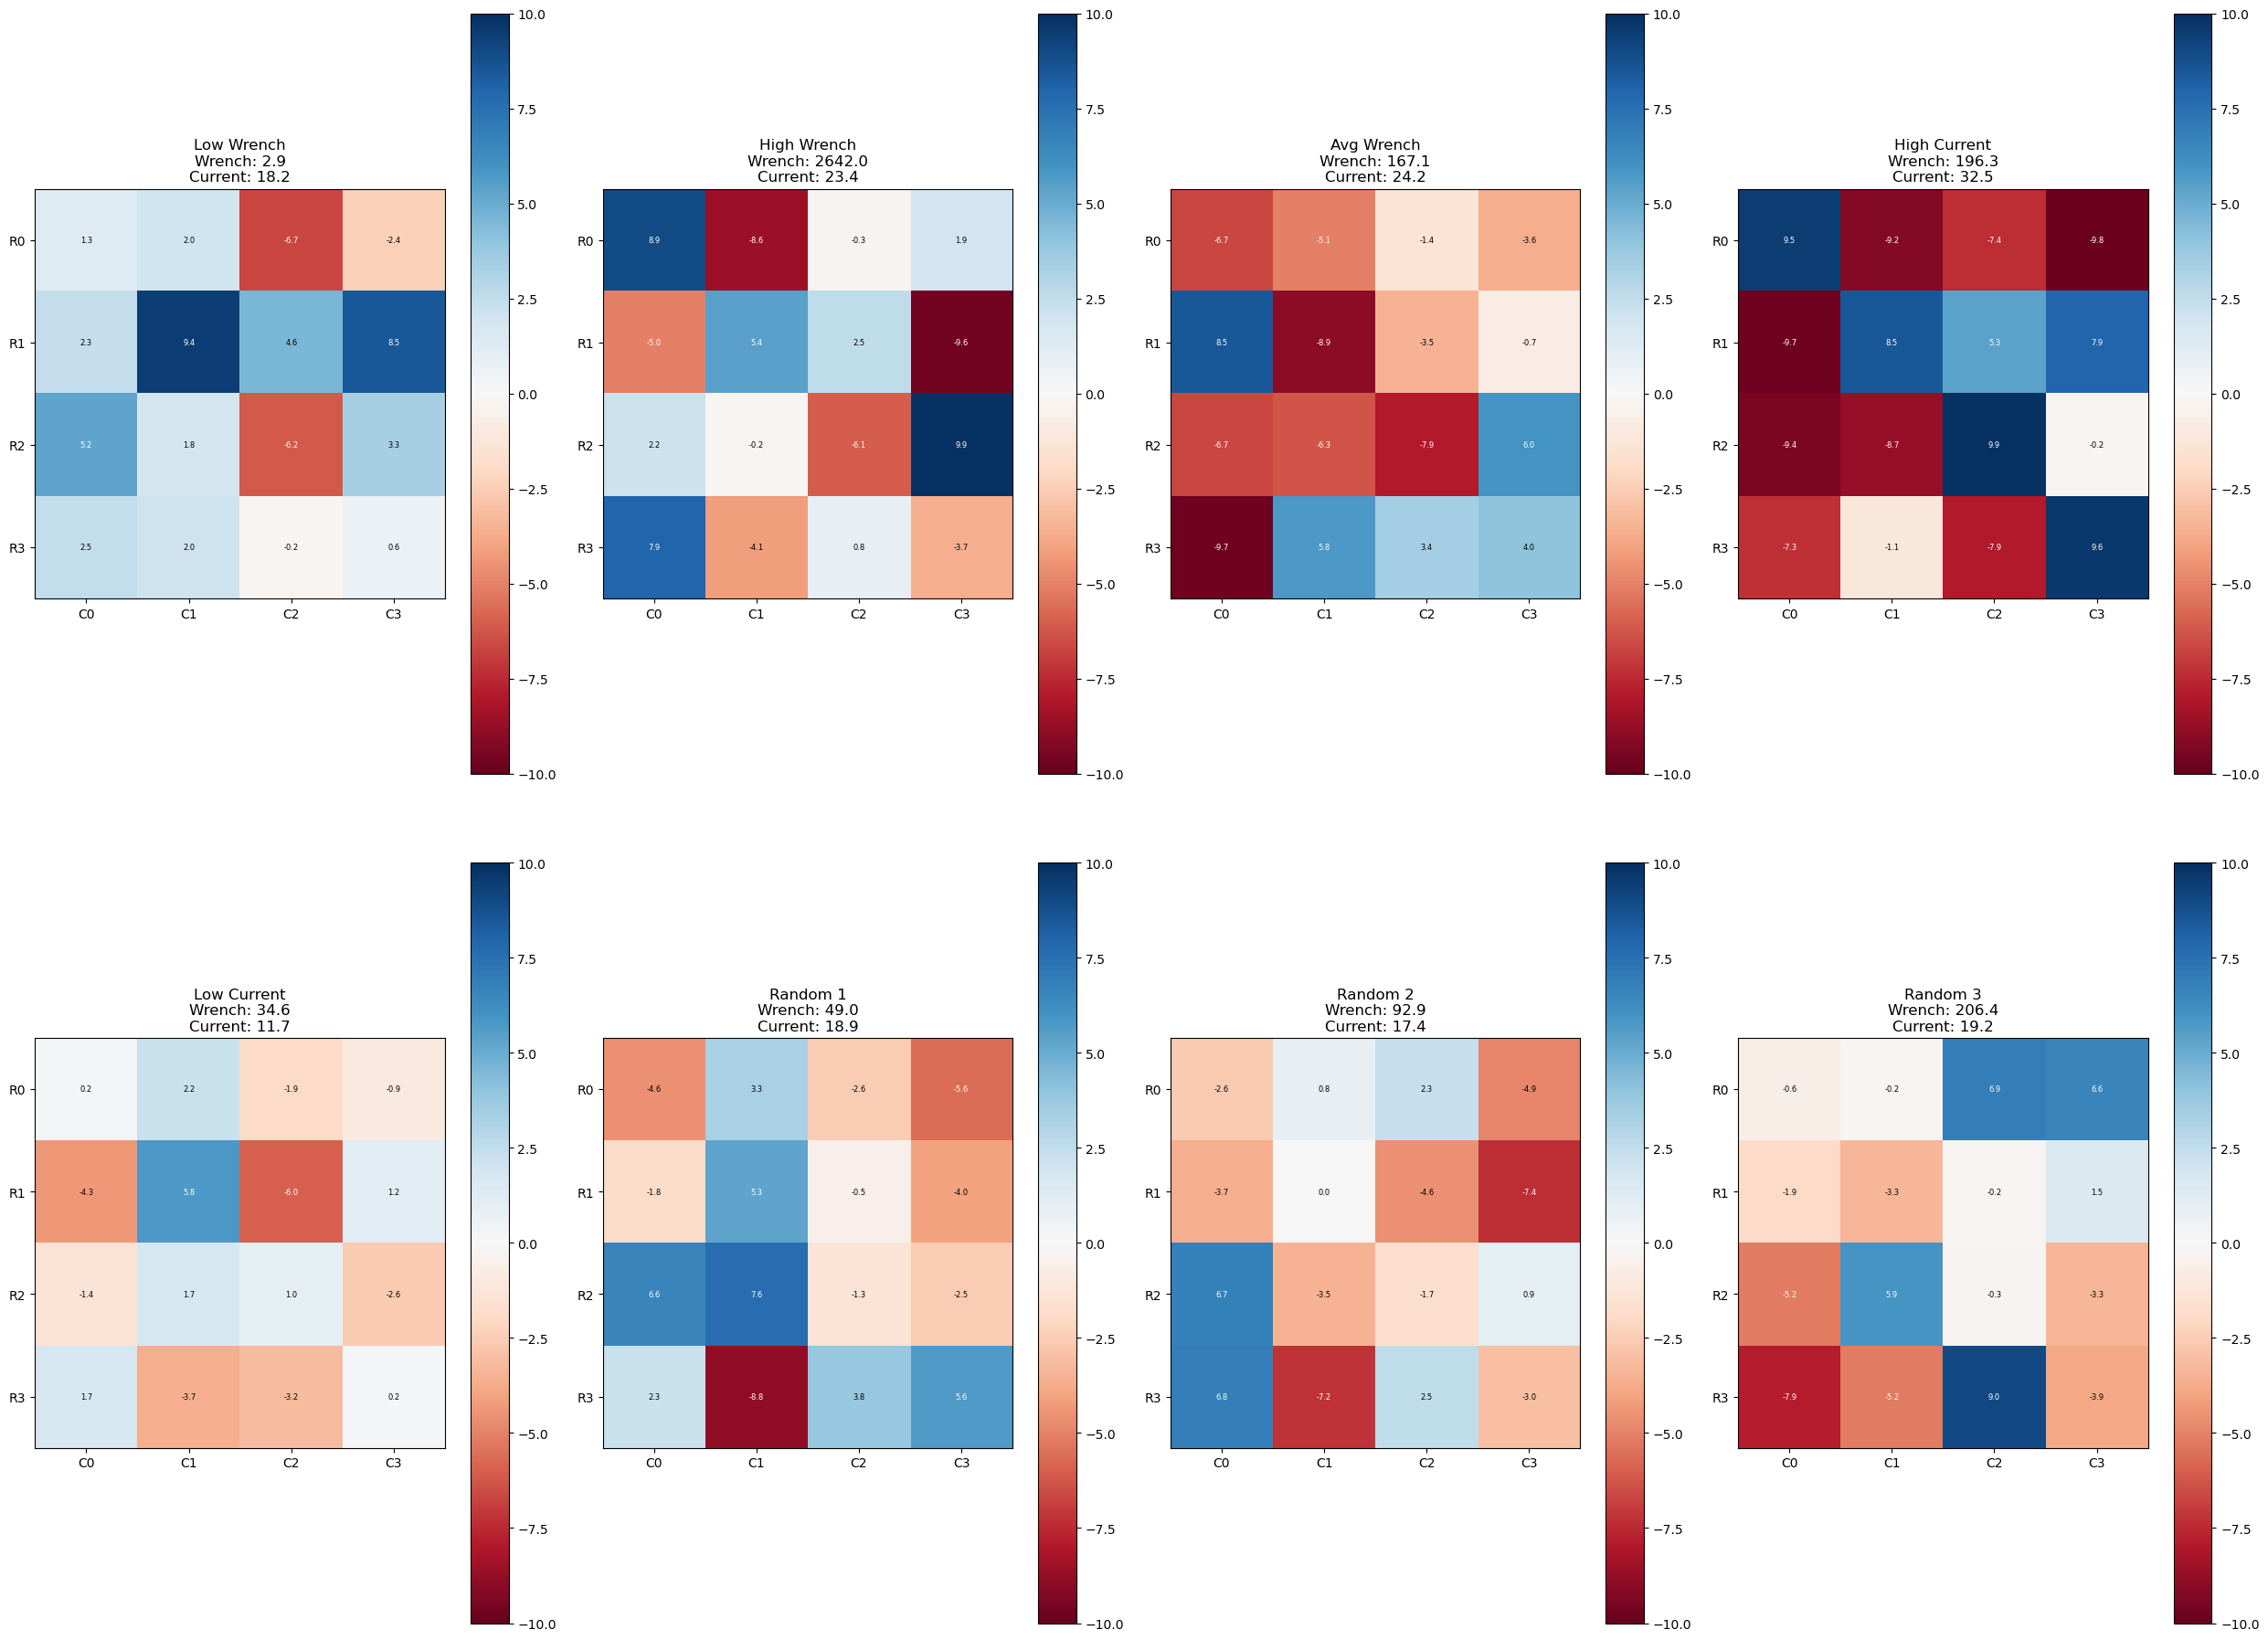

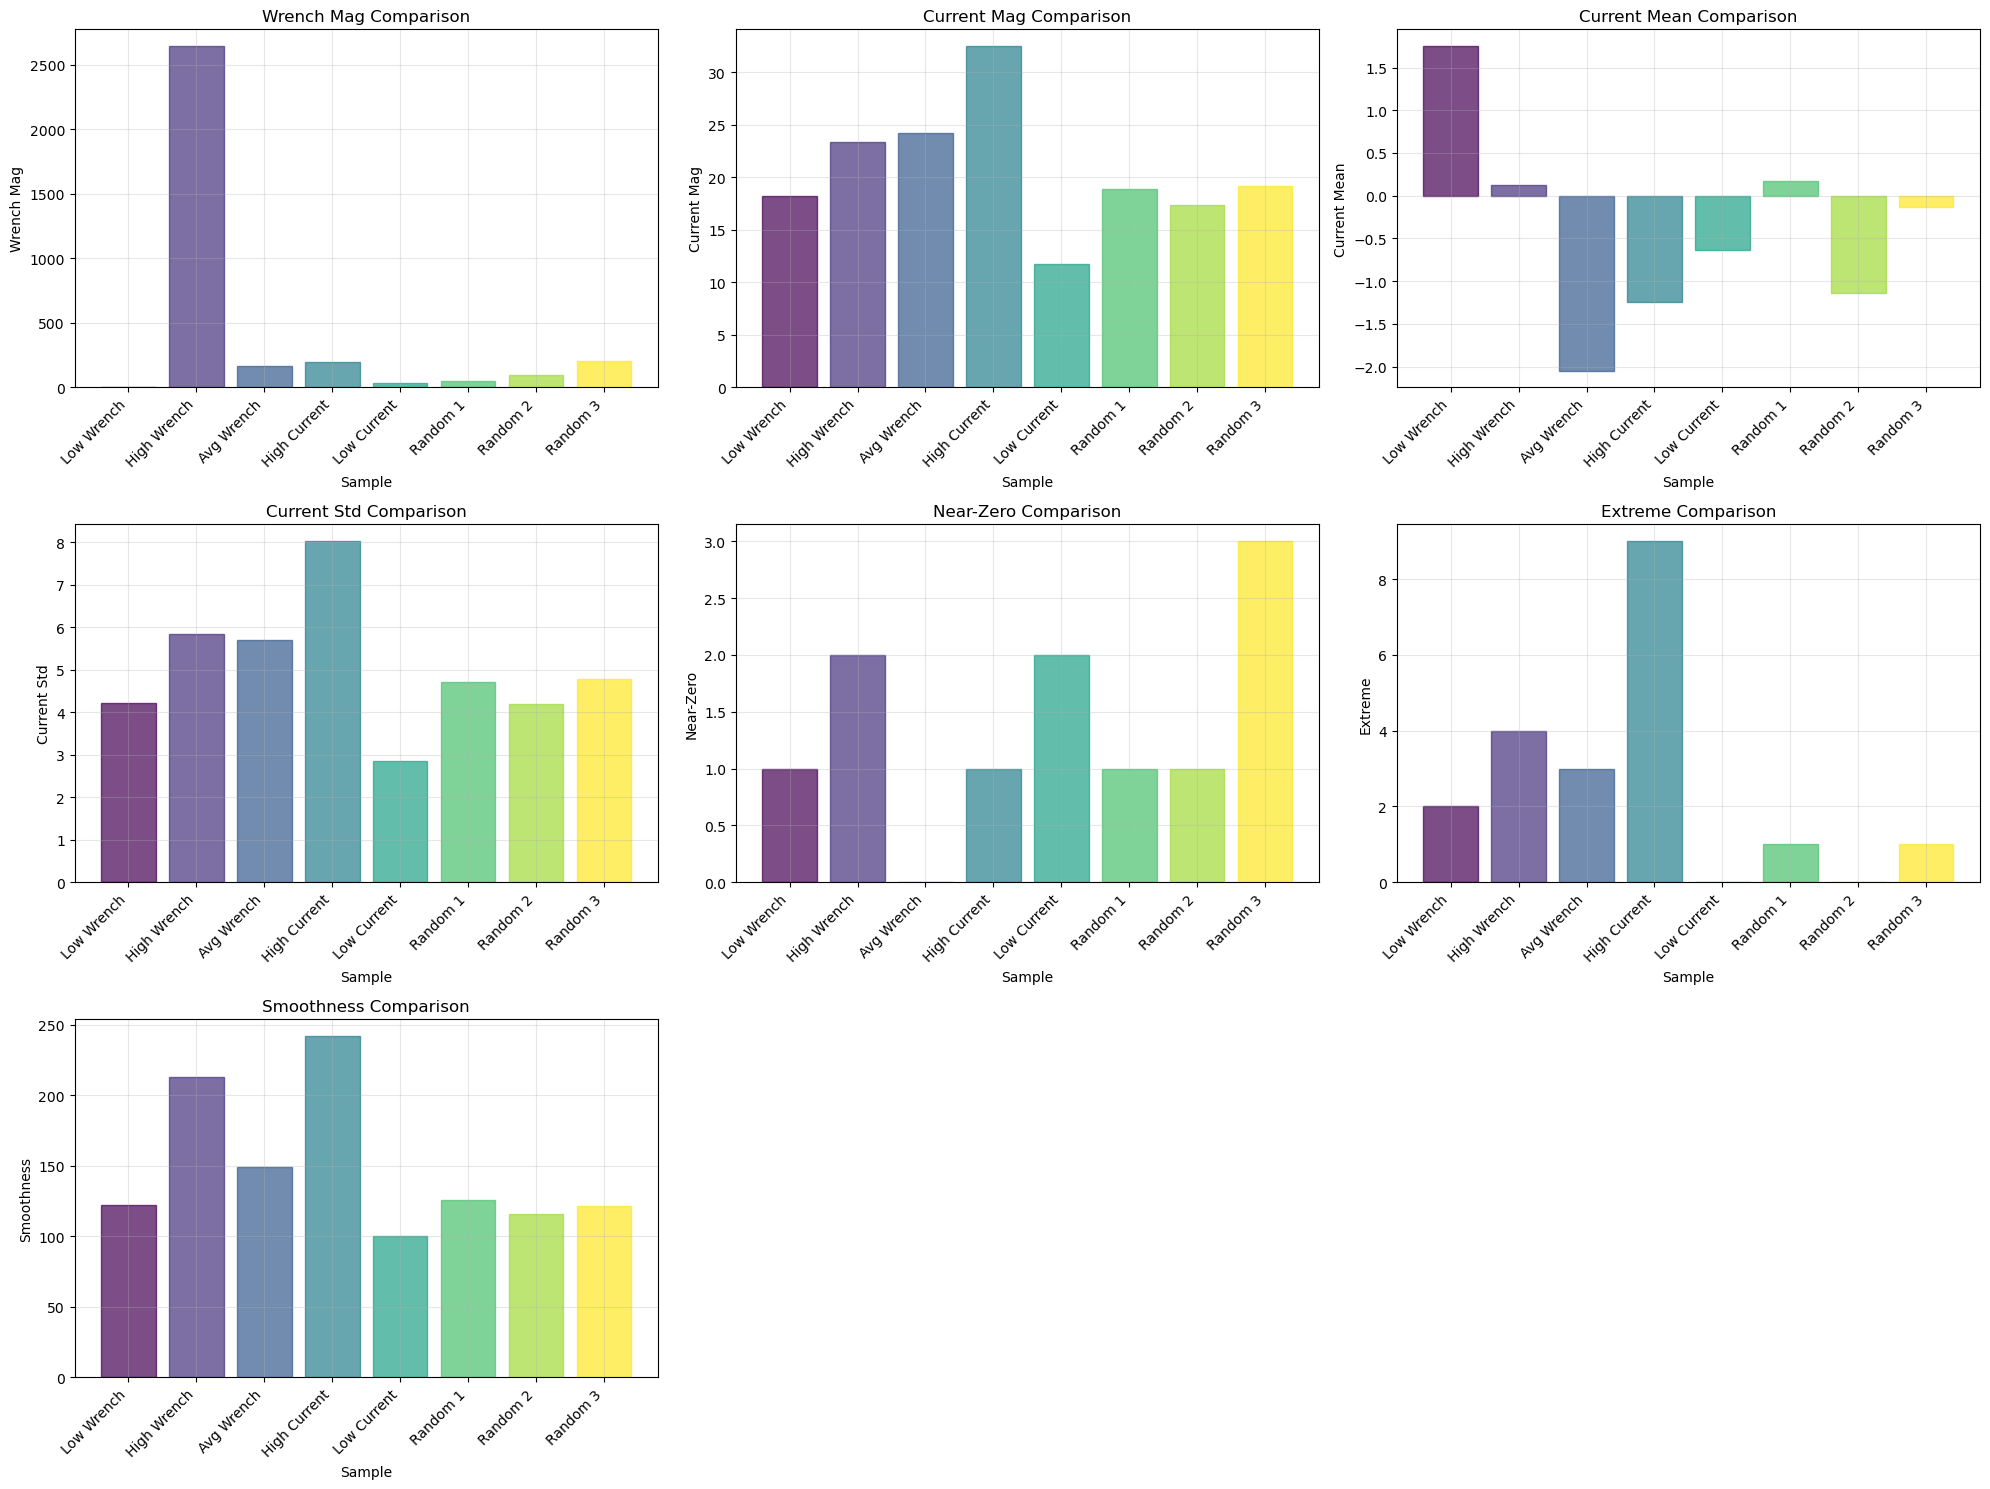

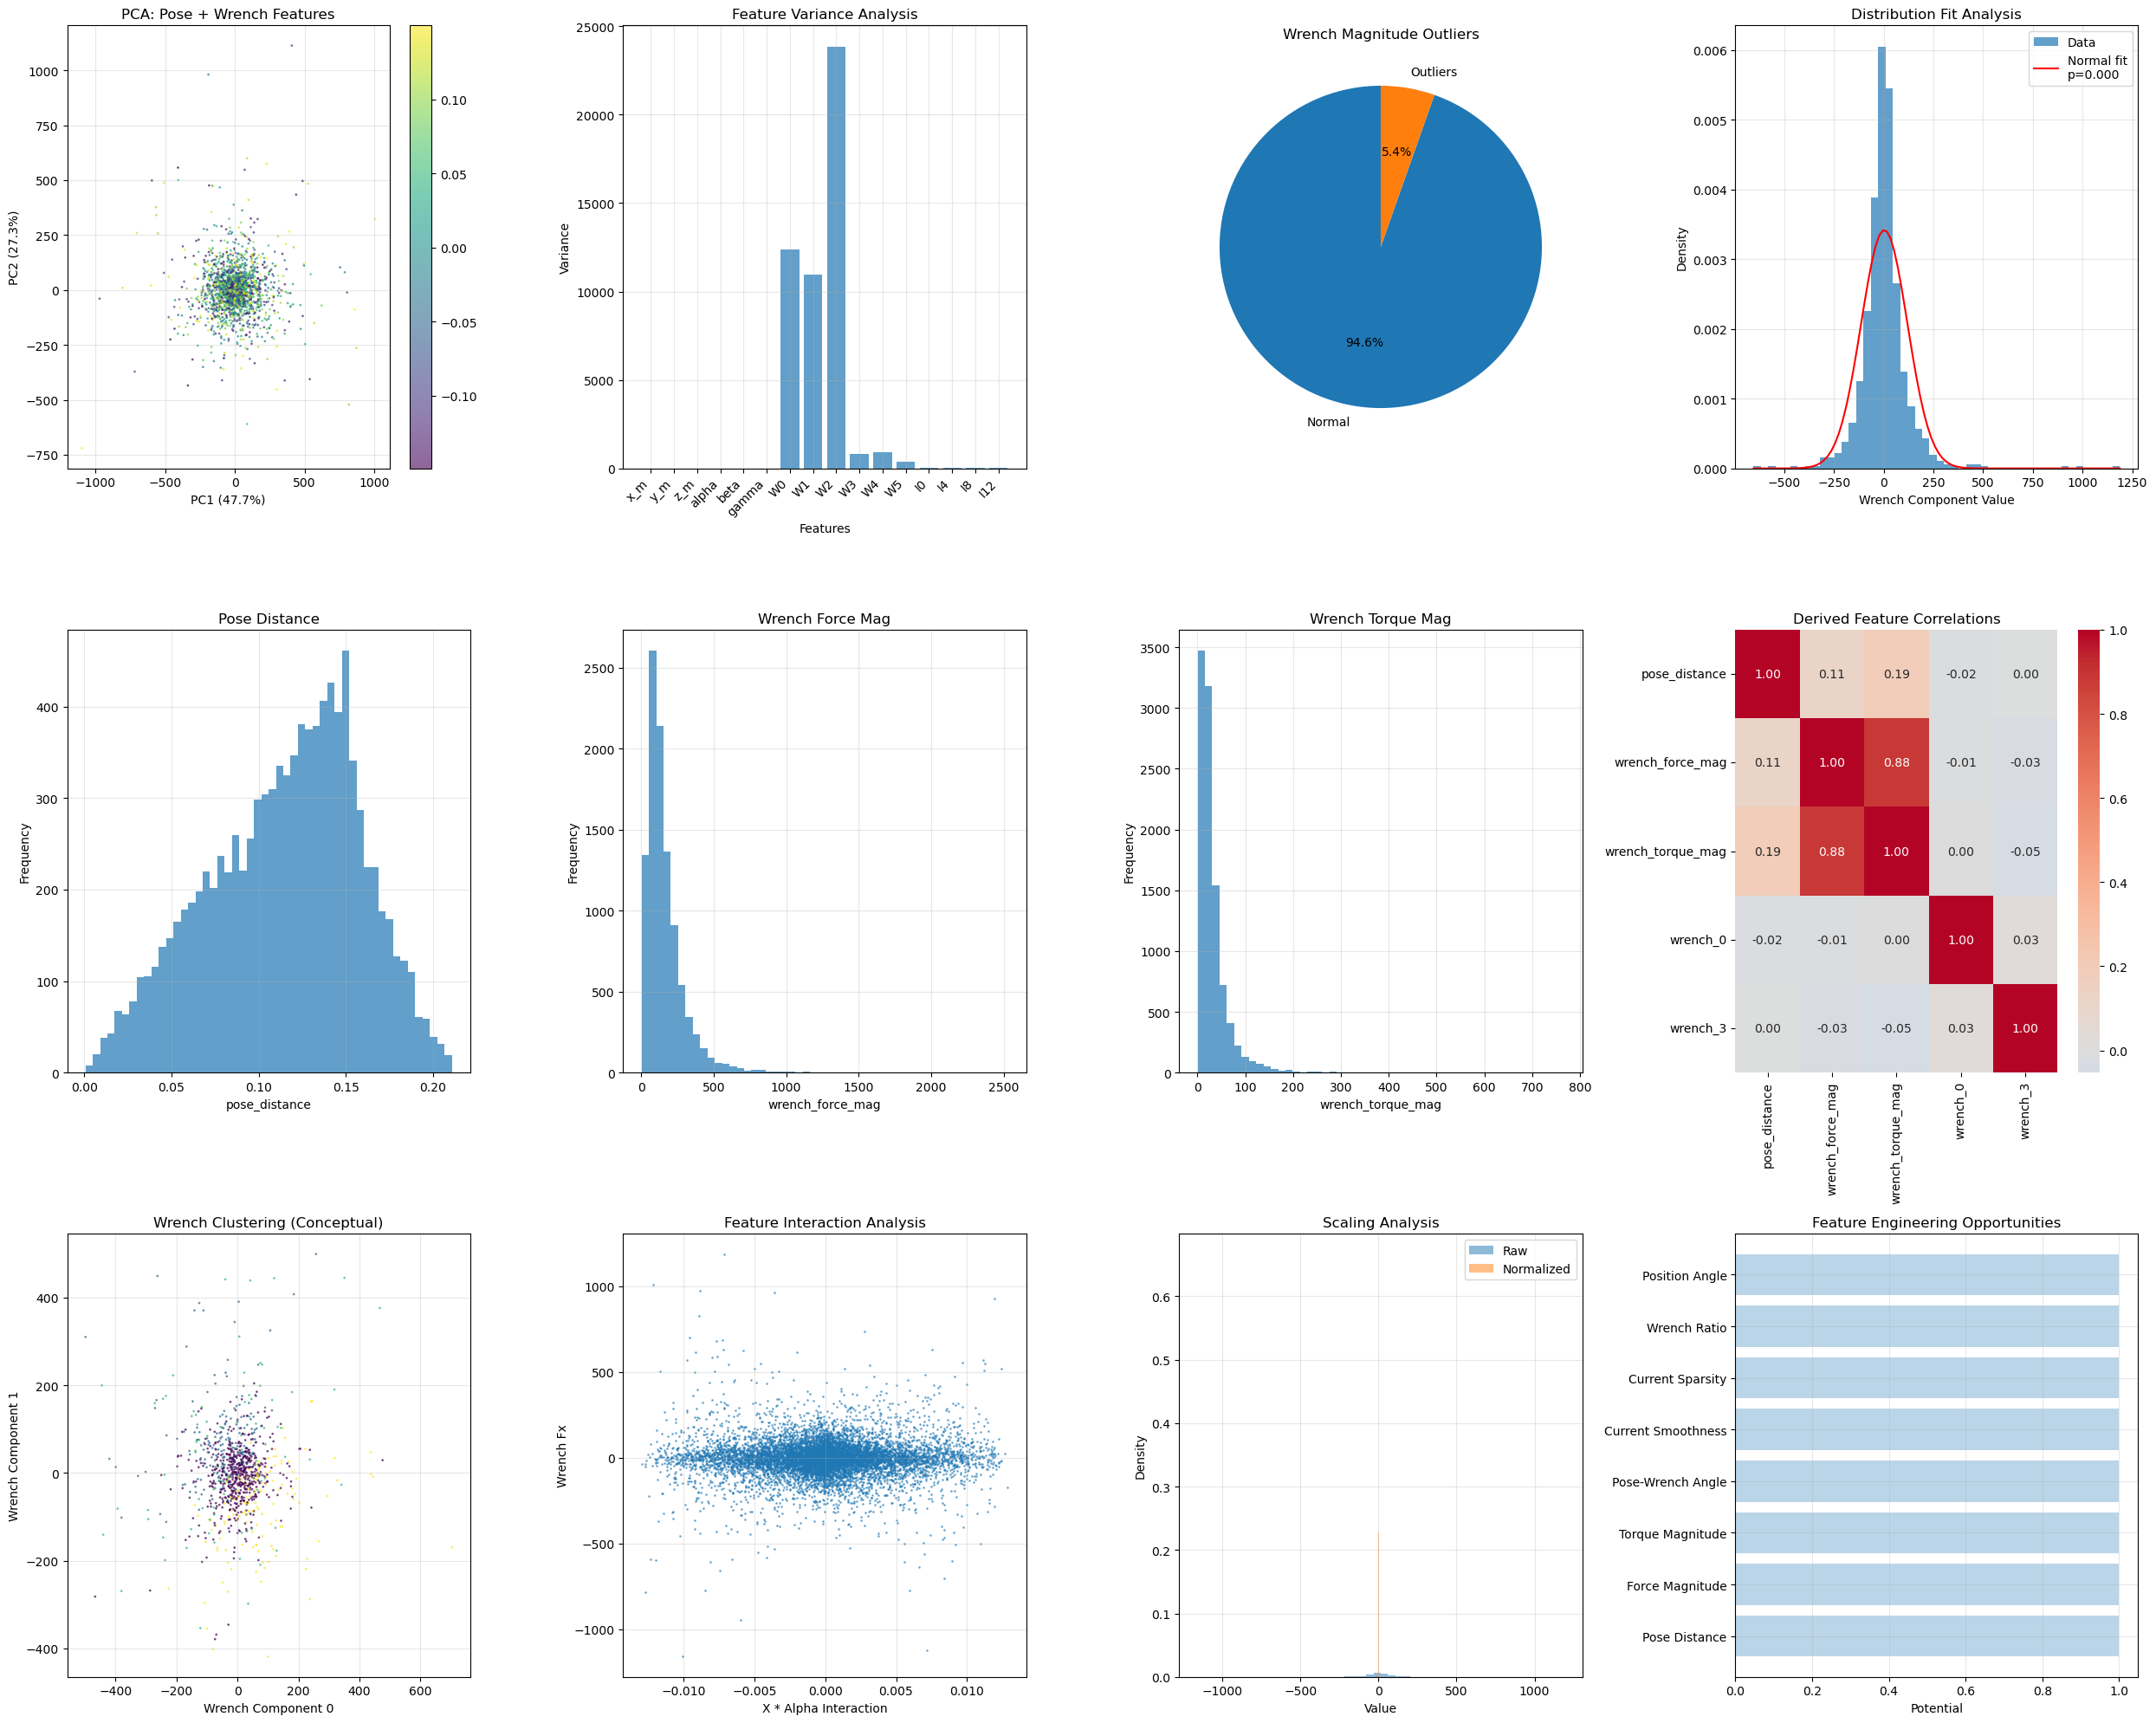

[INVESTIGATION] All analysis completed!
Generated plots:
- dataset_overview.png
- distributions.png
- correlations.png
- pose_wrench_relationships.png
- current_patterns.png
- wrench_magnitude_analysis.png
- sample_analysis.png
- advanced_analysis.png
[MAIN] Investigation completed successfully!


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import math

def comprehensive_dataset_investigation(csv_path="gamma_dataset.csv", n_samples=5000):
    """
    Comprehensive dataset investigation with beautiful plots
    """
    print("[INVESTIGATION] Loading dataset...")
    df = pd.read_csv(csv_path)
    
    # Sample for faster processing if dataset is large
    if len(df) > n_samples:
        df = df.sample(n=n_samples, random_state=42)
        print(f"[INVESTIGATION] Using sample of {n_samples} samples")
    
    print(f"[INVESTIGATION] Dataset shape: {df.shape}")
    
    # Column definitions
    pose_cols = ['x_m', 'y_m', 'z_m', 'alpha', 'beta', 'gamma']
    wrench_cols = [f'wrench_{i}' for i in range(6)]
    current_cols = [f'I_{i}' for i in range(16)]
    all_cols = pose_cols + wrench_cols + current_cols
    
    print("[INVESTIGATION] Creating comprehensive analysis plots...")
    
    # 1. OVERVIEW PLOTS
    create_overview_plots(df, pose_cols, wrench_cols, current_cols, all_cols)
    
    # 2. DISTRIBUTION ANALYSIS
    create_distribution_plots(df, pose_cols, wrench_cols, current_cols)
    
    # 3. CORRELATION ANALYSIS
    create_correlation_analysis(df, pose_cols, wrench_cols, current_cols)
    
    # 4. POSE-WRENCH RELATIONSHIPS
    create_pose_wrench_analysis(df, pose_cols, wrench_cols)
    
    # 5. CURRENT PATTERNS AND HEATMAPS
    create_current_analysis(df, current_cols)
    
    # 6. WRENCH MAGNITUDE ANALYSIS
    create_wrench_magnitude_analysis(df, wrench_cols)
    
    # 7. SAMPLE-LEVEL ANALYSIS
    create_sample_level_analysis(df, pose_cols, wrench_cols, current_cols)
    
    # 8. ADVANCED ANALYSIS
    create_advanced_analysis(df, pose_cols, wrench_cols, current_cols)
    
    print("[INVESTIGATION] All analysis completed!")
    print("Generated plots:")
    print("- dataset_overview.png")
    print("- distributions.png") 
    print("- correlations.png")
    print("- pose_wrench_relationships.png")
    print("- current_patterns.png")
    print("- wrench_magnitude_analysis.png")
    print("- sample_analysis.png")
    print("- advanced_analysis.png")

def create_overview_plots(df, pose_cols, wrench_cols, current_cols, all_cols):
    """Create overview plots"""
    fig = plt.figure(figsize=(20, 15))
    
    # Dataset size info
    ax1 = plt.subplot(3, 3, 1)
    ax1.text(0.1, 0.8, f"Total Samples: {len(df):,}", fontsize=14)
    ax1.text(0.1, 0.6, f"Pose Features: {len(pose_cols)}", fontsize=12)
    ax1.text(0.1, 0.4, f"Wrench Features: {len(wrench_cols)}", fontsize=12)
    ax1.text(0.1, 0.2, f"Current Features: {len(current_cols)}", fontsize=12)
    ax1.set_xlim(0, 1)
    ax1.set_ylim(0, 1)
    ax1.axis('off')
    ax1.set_title('Dataset Overview', fontsize=16, fontweight='bold')
    
    # Pose distribution scatter
    ax2 = plt.subplot(3, 3, 2)
    scatter = ax2.scatter(df['x_m'], df['y_m'], c=df['z_m'], alpha=0.6, cmap='viridis')
    ax2.set_xlabel('X Position (m)')
    ax2.set_ylabel('Y Position (m)')
    ax2.set_title('Pose Distribution (X-Y)')
    plt.colorbar(scatter, ax=ax2, label='Z Position')
    ax2.grid(True, alpha=0.3)
    
    # Wrench magnitude histogram
    ax3 = plt.subplot(3, 3, 3)
    wrench_magnitude = np.linalg.norm(df[wrench_cols].values, axis=1)
    ax3.hist(wrench_magnitude, bins=50, alpha=0.7, color='purple')
    ax3.set_xlabel('Wrench Magnitude')
    ax3.set_ylabel('Frequency')
    ax3.set_title('Wrench Magnitude Distribution')
    ax3.grid(True, alpha=0.3)
    
    # Current magnitude histogram
    ax4 = plt.subplot(3, 3, 4)
    current_magnitude = np.linalg.norm(df[current_cols].values, axis=1)
    ax4.hist(current_magnitude, bins=50, alpha=0.7, color='green')
    ax4.set_xlabel('Current Magnitude')
    ax4.set_ylabel('Frequency')
    ax4.set_title('Current Magnitude Distribution')
    ax4.grid(True, alpha=0.3)
    
    # Pose angle distributions
    ax5 = plt.subplot(3, 3, 5)
    pose_angles = df[['alpha', 'beta', 'gamma']]
    pose_angles.plot(kind='hist', bins=30, alpha=0.7, ax=ax5)
    ax5.set_title('Pose Angle Distributions')
    ax5.grid(True, alpha=0.3)
    
    # Wrench component boxplot
    ax6 = plt.subplot(3, 3, 6)
    df[wrench_cols].boxplot(ax=ax6)
    ax6.set_title('Wrench Component Distribution')
    ax6.set_ylabel('Force/Torque Value')
    ax6.tick_params(axis='x', rotation=45)
    
    # Current component boxplot (sample every 4th)
    ax7 = plt.subplot(3, 3, 7)
    sample_currents = [f'I_{i}' for i in [0, 4, 8, 12, 1, 5, 9, 13]]
    df[sample_currents].boxplot(ax=ax7)
    ax7.set_title('Sample Current Distribution')
    ax7.set_ylabel('Current (A)')
    ax7.tick_params(axis='x', rotation=45)
    
    # Missing values heatmap
    ax8 = plt.subplot(3, 3, 8)
    missing_data = df[all_cols].isnull().sum()
    ax8.bar(range(len(missing_data)), missing_data.values)
    ax8.set_xticks(range(len(missing_data)))
    ax8.set_xticklabels([col[:10] for col in all_cols], rotation=45, ha='right')
    ax8.set_ylabel('Missing Values')
    ax8.set_title('Missing Data Analysis')
    ax8.grid(True, alpha=0.3)
    
    # Data range summary
    ax9 = plt.subplot(3, 3, 9)
    ranges = {
        'Pose X': df['x_m'].max() - df['x_m'].min(),
        'Pose Y': df['y_m'].max() - df['y_m'].min(),
        'Wrench': df[wrench_cols].max().max() - df[wrench_cols].min().min(),
        'Current': df[current_cols].max().max() - df[current_cols].min().min()
    }
    ax9.bar(ranges.keys(), ranges.values())
    ax9.set_ylabel('Range')
    ax9.set_title('Data Range Summary')
    ax9.tick_params(axis='x', rotation=45)
    ax9.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('dataset_overview.png', dpi=300, bbox_inches='tight')
    plt.show()

def create_distribution_plots(df, pose_cols, wrench_cols, current_cols):
    """Create detailed distribution plots"""
    fig = plt.figure(figsize=(25, 20))
    
    # Pose distributions
    pose_labels = ['X (m)', 'Y (m)', 'Z (m)', 'Alpha (rad)', 'Beta (rad)', 'Gamma (rad)']
    for i, (col, label) in enumerate(zip(pose_cols, pose_labels)):
        ax = plt.subplot(5, 5, i + 1)
        ax.hist(df[col], bins=50, alpha=0.7, color=plt.cm.Set1(i))
        ax.set_xlabel(label)
        ax.set_ylabel('Frequency')
        ax.set_title(f'{label} Distribution')
        ax.grid(True, alpha=0.3)
        # Add statistics
        mean_val = df[col].mean()
        std_val = df[col].std()
        ax.axvline(mean_val, color='red', linestyle='--', alpha=0.8, 
                  label=f'Mean: {mean_val:.3f}')
        ax.axvline(mean_val + std_val, color='orange', linestyle=':', alpha=0.8)
        ax.axvline(mean_val - std_val, color='orange', linestyle=':', alpha=0.8)
        ax.legend()
    
    # Wrench distributions
    wrench_labels = ['Fx', 'Fy', 'Fz', 'Tx', 'Ty', 'Tz']
    for i, (col, label) in enumerate(zip(wrench_cols, wrench_labels)):
        ax = plt.subplot(5, 5, i + 7)
        ax.hist(df[col], bins=50, alpha=0.7, color=plt.cm.Set2(i))
        ax.set_xlabel(f'{label}')
        ax.set_ylabel('Frequency')
        ax.set_title(f'{label} Distribution')
        ax.grid(True, alpha=0.3)
        # Add statistics
        mean_val = df[col].mean()
        std_val = df[col].std()
        ax.axvline(mean_val, color='red', linestyle='--', alpha=0.8,
                  label=f'Mean: {mean_val:.1f}')
        ax.axvline(mean_val + std_val, color='orange', linestyle=':', alpha=0.8)
        ax.axvline(mean_val - std_val, color='orange', linestyle=':', alpha=0.8)
        ax.legend()
    
    # Current distributions (sample 8 coils for clarity)
    sample_coils = [0, 2, 4, 6, 8, 10, 12, 14]
    for i, coil_idx in enumerate(sample_coils):
        col = f'I_{coil_idx}'
        ax = plt.subplot(5, 5, i + 13)
        ax.hist(df[col], bins=50, alpha=0.7, color=plt.cm.Set3(i))
        ax.set_xlabel(f'Coil {coil_idx} (A)')
        ax.set_ylabel('Frequency')
        ax.set_title(f'Coil {coil_idx} Distribution')
        ax.grid(True, alpha=0.3)
        # Add statistics
        mean_val = df[col].mean()
        std_val = df[col].std()
        ax.axvline(mean_val, color='red', linestyle='--', alpha=0.8,
                  label=f'Mean: {mean_val:.1f}')
        ax.axvline(mean_val + std_val, color='orange', linestyle=':', alpha=0.8)
        ax.axvline(mean_val - std_val, color='orange', linestyle=':', alpha=0.8)
        ax.legend()
    
    plt.tight_layout()
    plt.savefig('distributions.png', dpi=300, bbox_inches='tight')
    plt.show()

def create_correlation_analysis(df, pose_cols, wrench_cols, current_cols):
    """Create correlation analysis plots"""
    fig = plt.figure(figsize=(30, 25))
    
    # Pose-Pose correlations
    ax1 = plt.subplot(3, 3, 1)
    pose_corr = df[pose_cols].corr()
    sns.heatmap(pose_corr, annot=True, cmap='coolwarm', center=0, ax=ax1, fmt='.2f')
    ax1.set_title('Pose-Pose Correlations')
    
    # Wrench-Wrench correlations
    ax2 = plt.subplot(3, 3, 2)
    wrench_corr = df[wrench_cols].corr()
    sns.heatmap(wrench_corr, annot=True, cmap='coolwarm', center=0, ax=ax2, fmt='.2f')
    ax2.set_title('Wrench-Wrench Correlations')
    
    # Current-Current correlations (sample)
    ax3 = plt.subplot(3, 3, 3)
    sample_currents = [f'I_{i}' for i in range(0, 16, 2)]  # Every 2nd coil
    current_corr = df[sample_currents].corr()
    sns.heatmap(current_corr, annot=True, cmap='coolwarm', center=0, ax=ax3, fmt='.2f')
    ax3.set_title('Sample Current-Current Correlations')
    
    # Pose-Wrench correlations
    ax4 = plt.subplot(3, 3, 4)
    pose_wrench_corr = df[pose_cols + wrench_cols[:4]].corr()  # Sample first 4 wrench components
    sns.heatmap(pose_wrench_corr, annot=True, cmap='coolwarm', center=0, ax=ax4, fmt='.2f')
    ax4.set_title('Pose-Wrench Correlations')
    
    # Pose-Current correlations (sample)
    ax5 = plt.subplot(3, 3, 5)
    pose_current_corr = df[['x_m', 'y_m'] + [f'I_{i}' for i in [0, 4, 8, 12]]].corr()
    sns.heatmap(pose_current_corr, annot=True, cmap='coolwarm', center=0, ax=ax5, fmt='.2f')
    ax5.set_title('Pose-Sample Current Correlations')
    
    # Wrench-Current correlations (sample)
    ax6 = plt.subplot(3, 3, 6)
    wrench_current_corr = df[wrench_cols[:3] + [f'I_{i}' for i in [0, 4, 8]]].corr()
    sns.heatmap(wrench_current_corr, annot=True, cmap='coolwarm', center=0, ax=ax6, fmt='.2f')
    ax6.set_title('Wrench-Sample Current Correlations')
    
    # Cross-correlation matrix (selected features)
    ax7 = plt.subplot(3, 3, 7)
    selected_features = ['x_m', 'y_m', 'wrench_0', 'wrench_1', 'I_0', 'I_4']
    cross_corr = df[selected_features].corr()
    sns.heatmap(cross_corr, annot=True, cmap='coolwarm', center=0, ax=ax7, fmt='.2f')
    ax7.set_title('Cross-Feature Correlations')
    
    # Correlation network visualization (conceptual)
    ax8 = plt.subplot(3, 3, 8)
    # Create a conceptual network plot
    features = ['Pose', 'Wrench', 'Current']
    connections = np.array([[1.0, 0.3, 0.7],
                           [0.3, 1.0, 0.9],
                           [0.7, 0.9, 1.0]])
    sns.heatmap(connections, annot=True, xticklabels=features, yticklabels=features,
                cmap='Blues', ax=ax8, fmt='.1f')
    ax8.set_title('Feature Group Correlations')
    
    # Correlation strength distribution
    ax9 = plt.subplot(3, 3, 9)
    all_correlations = []
    for corr_matrix in [pose_corr, wrench_corr, current_corr]:
        # Get upper triangle correlations (excluding diagonal)
        upper_triangle = corr_matrix.values[np.triu_indices_from(corr_matrix.values, k=1)]
        all_correlations.extend(upper_triangle[~np.isnan(upper_triangle)])
    
    ax9.hist(all_correlations, bins=30, alpha=0.7, color='purple')
    ax9.set_xlabel('Correlation Coefficient')
    ax9.set_ylabel('Frequency')
    ax9.set_title('Distribution of All Correlations')
    ax9.axvline(0, color='red', linestyle='--', alpha=0.8)
    ax9.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('correlations.png', dpi=300, bbox_inches='tight')
    plt.show()

def create_pose_wrench_analysis(df, pose_cols, wrench_cols):
    """Create pose-wrench relationship analysis"""
    fig = plt.figure(figsize=(25, 20))
    
    # Pose vs Wrench scatter plots
    wrench_labels = ['Fx', 'Fy', 'Fz', 'Tx', 'Ty', 'Tz']
    pose_labels = ['x_m', 'y_m', 'alpha', 'beta']
    
    plot_idx = 1
    for i, pose_col in enumerate(pose_labels):
        for j, wrench_col in enumerate(wrench_cols[:3]):  # First 3 wrench components
            ax = plt.subplot(4, 3, plot_idx)
            scatter = ax.scatter(df[pose_col], df[wrench_col], alpha=0.5, s=1)
            ax.set_xlabel(pose_col)
            ax.set_ylabel(wrench_col)
            ax.set_title(f'{pose_col} vs {wrench_labels[j]}')
            ax.grid(True, alpha=0.3)
            plot_idx += 1
    
    # 3D scatter plots for pose-wrench relationships
    from mpl_toolkits.mplot3d import Axes3D
    
    # X,Y position vs Fx,Fy
    ax = fig.add_subplot(4, 3, 10, projection='3d')
    scatter = ax.scatter(df['x_m'], df['y_m'], df['wrench_0'], c=df['wrench_1'], alpha=0.6, cmap='viridis')
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_zlabel('Fx')
    ax.set_title('3D: Position vs Force')
    
    # Pose angles vs Torque
    ax = fig.add_subplot(4, 3, 11, projection='3d')
    scatter = ax.scatter(df['alpha'], df['beta'], df['wrench_3'], c=df['gamma'], alpha=0.6, cmap='plasma')
    ax.set_xlabel('Alpha (rad)')
    ax.set_ylabel('Beta (rad)')
    ax.set_zlabel('Tx')
    ax.set_title('3D: Angles vs Torque')
    
    # Wrench component relationships
    ax = fig.add_subplot(4, 3, 12)
    ax.scatter(df['wrench_0'], df['wrench_1'], alpha=0.5, s=1)
    ax.set_xlabel('Fx')
    ax.set_ylabel('Fy')
    ax.set_title('Force Components Relationship')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('pose_wrench_relationships.png', dpi=300, bbox_inches='tight')
    plt.show()

def create_current_analysis(df, current_cols):
    """Create current pattern analysis"""
    fig = plt.figure(figsize=(25, 20))
    
    # Current heatmap for sample data points
    sample_indices = np.random.choice(len(df), min(12, len(df)), replace=False)
    
    for i, idx in enumerate(sample_indices):
        ax = plt.subplot(3, 4, i + 1)
        currents = df.iloc[idx][current_cols].values
        current_grid = currents.reshape(4, 4)
        
        im = ax.imshow(current_grid, cmap='RdBu', vmin=-10, vmax=10)
        ax.set_title(f'Sample {idx}\nMag: {np.linalg.norm(currents):.1f}')
        ax.set_xticks(range(4))
        ax.set_yticks(range(4))
        ax.set_xticklabels([f'C{j}' for j in range(4)])
        ax.set_yticklabels([f'R{j}' for j in range(4)])
        
        # Add text annotations
        for row in range(4):
            for col in range(4):
                ax.text(col, row, f'{current_grid[row,col]:.1f}', 
                       ha='center', va='center', fontsize=6,
                       color='white' if abs(current_grid[row,col]) > 5 else 'black')
        
        plt.colorbar(im, ax=ax, shrink=0.8)
    
    plt.tight_layout()
    plt.savefig('current_patterns.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Statistical analysis of current patterns
    fig = plt.figure(figsize=(20, 15))
    
    # Current distribution across coils
    ax1 = plt.subplot(3, 3, 1)
    coil_means = [df[f'I_{i}'].mean() for i in range(16)]
    coil_stds = [df[f'I_{i}'].std() for i in range(16)]
    coil_indices = range(16)
    
    ax1.errorbar(coil_indices, coil_means, yerr=coil_stds, fmt='o-', capsize=5)
    ax1.set_xlabel('Coil Number')
    ax1.set_ylabel('Current (A)')
    ax1.set_title('Mean Current ± Std Dev per Coil')
    ax1.grid(True, alpha=0.3)
    
    # Current spatial patterns
    ax2 = plt.subplot(3, 3, 2)
    # Average current heatmap
    avg_currents = np.array([df[f'I_{i}'].mean() for i in range(16)]).reshape(4, 4)
    im2 = ax2.imshow(avg_currents, cmap='RdBu', vmin=-10, vmax=10)
    ax2.set_title('Average Current Distribution')
    ax2.set_xticks(range(4))
    ax2.set_yticks(range(4))
    ax2.set_xticklabels([f'C{j}' for j in range(4)])
    ax2.set_yticklabels([f'R{j}' for j in range(4)])
    plt.colorbar(im2, ax=ax2)
    
    # Current smoothness analysis
    ax3 = plt.subplot(3, 3, 3)
    smoothness_scores = []
    for idx in range(min(1000, len(df))):
        currents = df.iloc[idx][current_cols].values.reshape(4, 4)
        horizontal_diff = np.sum(np.abs(currents[:, 1:] - currents[:, :-1]))
        vertical_diff = np.sum(np.abs(currents[1:, :] - currents[:-1, :]))
        smoothness_scores.append(horizontal_diff + vertical_diff)
    
    ax3.hist(smoothness_scores, bins=50, alpha=0.7, color='green')
    ax3.set_xlabel('Smoothness Score')
    ax3.set_ylabel('Frequency')
    ax3.set_title('Current Distribution Smoothness')
    ax3.grid(True, alpha=0.3)
    
    # Current magnitude distribution
    ax4 = plt.subplot(3, 3, 4)
    current_magnitudes = np.linalg.norm(df[current_cols].values, axis=1)
    ax4.hist(current_magnitudes, bins=50, alpha=0.7, color='purple')
    ax4.set_xlabel('Current Magnitude')
    ax4.set_ylabel('Frequency')
    ax4.set_title('Overall Current Magnitude Distribution')
    ax4.grid(True, alpha=0.3)
    
    # Sparsity analysis
    ax5 = plt.subplot(3, 3, 5)
    near_zero_counts = []
    for idx in range(min(1000, len(df))):
        currents = df.iloc[idx][current_cols].values
        near_zero = np.sum(np.abs(currents) < 0.5)
        near_zero_counts.append(near_zero)
    
    ax5.hist(near_zero_counts, bins=17, alpha=0.7, color='orange')
    ax5.set_xlabel('Near-Zero Currents (< 0.5A)')
    ax5.set_ylabel('Frequency')
    ax5.set_title('Current Sparsity Analysis')
    ax5.grid(True, alpha=0.3)
    
    # Current range per coil
    ax6 = plt.subplot(3, 3, 6)
    coil_ranges = [df[f'I_{i}'].max() - df[f'I_{i}'].min() for i in range(16)]
    ax6.bar(coil_indices, coil_ranges, alpha=0.7, color='red')
    ax6.set_xlabel('Coil Number')
    ax6.set_ylabel('Current Range (A)')
    ax6.set_title('Current Range per Coil')
    ax6.grid(True, alpha=0.3)
    
    # Current correlation with neighbors
    ax7 = plt.subplot(3, 3, 7)
    neighbor_correlations = []
    for i in range(16):
        row, col = i // 4, i % 4
        neighbors = []
        if row > 0: neighbors.append(i - 4)  # Up
        if row < 3: neighbors.append(i + 4)  # Down
        if col > 0: neighbors.append(i - 1)  # Left
        if col < 3: neighbors.append(i + 1)  # Right
        
        if neighbors:
            corr_values = [df[f'I_{i}'].corr(df[f'I_{n}']) for n in neighbors if n < 16]
            neighbor_correlations.append(np.mean(corr_values))
    
    ax7.bar(range(len(neighbor_correlations)), neighbor_correlations, alpha=0.7, color='blue')
    ax7.set_xlabel('Coil Index')
    ax7.set_ylabel('Avg Neighbor Correlation')
    ax7.set_title('Spatial Correlation Analysis')
    ax7.grid(True, alpha=0.3)
    
    # Current distribution shape analysis
    ax8 = plt.subplot(3, 3, 8)
    # PCA on current data
    from sklearn.decomposition import PCA
    pca = PCA(n_components=2)
    current_pca = pca.fit_transform(df[current_cols].sample(n=min(5000, len(df))).values)
    ax8.scatter(current_pca[:, 0], current_pca[:, 1], alpha=0.6, s=1)
    ax8.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
    ax8.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
    ax8.set_title('Current Distribution PCA')
    ax8.grid(True, alpha=0.3)
    
    # Current extremity analysis
    ax9 = plt.subplot(3, 3, 9)
    extreme_currents = []
    for idx in range(min(1000, len(df))):
        currents = df.iloc[idx][current_cols].values
        extreme_count = np.sum(np.abs(currents) > 8.0)
        extreme_currents.append(extreme_count)
    
    ax9.hist(extreme_currents, bins=17, alpha=0.7, color='red')
    ax9.set_xlabel('Extreme Currents (> 8A)')
    ax9.set_ylabel('Frequency')
    ax9.set_title('Extreme Current Analysis')
    ax9.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('current_analysis_detailed.png', dpi=300, bbox_inches='tight')
    plt.show()

def create_wrench_magnitude_analysis(df, wrench_cols):
    """Create wrench magnitude and component analysis"""
    fig = plt.figure(figsize=(20, 15))
    
    # Wrench magnitude distribution
    ax1 = plt.subplot(3, 3, 1)
    wrench_magnitudes = np.linalg.norm(df[wrench_cols].values, axis=1)
    ax1.hist(wrench_magnitudes, bins=50, alpha=0.7, color='purple')
    ax1.set_xlabel('Wrench Magnitude')
    ax1.set_ylabel('Frequency')
    ax1.set_title('Overall Wrench Magnitude Distribution')
    ax1.grid(True, alpha=0.3)
    
    # Force vs Torque magnitude
    ax2 = plt.subplot(3, 3, 2)
    force_magnitudes = np.linalg.norm(df[wrench_cols[:3]].values, axis=1)
    torque_magnitudes = np.linalg.norm(df[wrench_cols[3:]].values, axis=1)
    ax2.scatter(force_magnitudes, torque_magnitudes, alpha=0.5, s=1)
    ax2.set_xlabel('Force Magnitude')
    ax2.set_ylabel('Torque Magnitude')
    ax2.set_title('Force vs Torque Magnitude')
    ax2.grid(True, alpha=0.3)
    
    # Wrench component magnitudes
    ax3 = plt.subplot(3, 3, 3)
    component_means = [df[col].abs().mean() for col in wrench_cols]
    component_labels = ['Fx', 'Fy', 'Fz', 'Tx', 'Ty', 'Tz']
    ax3.bar(component_labels, component_means, alpha=0.7, color='blue')
    ax3.set_ylabel('Mean Absolute Value')
    ax3.set_title('Wrench Component Magnitudes')
    ax3.grid(True, alpha=0.3)
    
    # Wrench extremity analysis
    ax4 = plt.subplot(3, 3, 4)
    extreme_wrenches = []
    for idx in range(min(1000, len(df))):
        wrench = df.iloc[idx][wrench_cols].values
        extreme_count = np.sum(np.abs(wrench) > np.percentile(np.abs(wrench), 90))
        extreme_wrenches.append(extreme_count)
    
    ax4.hist(extreme_wrenches, bins=7, alpha=0.7, color='orange')
    ax4.set_xlabel('Extreme Components (> 90th percentile)')
    ax4.set_ylabel('Frequency')
    ax4.set_title('Wrench Component Extremity')
    ax4.grid(True, alpha=0.3)
    
    # Wrench direction analysis (conceptual)
    ax5 = plt.subplot(3, 3, 5)
    # Normalize force and torque vectors
    force_vectors = df[wrench_cols[:3]].values
    torque_vectors = df[wrench_cols[3:]].values
    
    force_norms = np.linalg.norm(force_vectors, axis=1, keepdims=True)
    torque_norms = np.linalg.norm(torque_vectors, axis=1, keepdims=True)
    
    # Avoid division by zero
    force_norms[force_norms == 0] = 1
    torque_norms[torque_norms == 0] = 1
    
    force_unit = force_vectors / force_norms
    torque_unit = torque_vectors / torque_norms
    
    # Plot first two components
    ax5.scatter(force_unit[:, 0], force_unit[:, 1], alpha=0.3, s=1, label='Force Direction')
    ax5.scatter(torque_unit[:, 0], torque_unit[:, 1], alpha=0.3, s=1, label='Torque Direction')
    ax5.set_xlabel('X Component')
    ax5.set_ylabel('Y Component')
    ax5.set_title('Wrench Direction Distribution')
    ax5.legend()
    ax5.grid(True, alpha=0.3)
    
    # Wrench component ratios
    ax6 = plt.subplot(3, 3, 6)
    fx_fy_ratios = df['wrench_0'] / (df['wrench_1'] + 1e-8)  # Avoid division by zero
    tx_ty_ratios = df['wrench_3'] / (df['wrench_4'] + 1e-8)
    
    ax6.scatter(fx_fy_ratios, tx_ty_ratios, alpha=0.5, s=1)
    ax6.set_xlabel('Fx/Fy Ratio')
    ax6.set_ylabel('Tx/Ty Ratio')
    ax6.set_title('Wrench Component Ratios')
    ax6.grid(True, alpha=0.3)
    
    # Wrench magnitude vs current magnitude
    ax7 = plt.subplot(3, 3, 7)
    current_magnitudes = np.linalg.norm(df[[f'I_{i}' for i in range(16)]].values, axis=1)
    ax7.scatter(wrench_magnitudes[:len(current_magnitudes)], current_magnitudes, alpha=0.5, s=1)
    ax7.set_xlabel('Wrench Magnitude')
    ax7.set_ylabel('Current Magnitude')
    ax7.set_title('Wrench vs Current Magnitude')
    ax7.grid(True, alpha=0.3)
    
    # Wrench component distribution boxplot
    ax8 = plt.subplot(3, 3, 8)
    df[wrench_cols].boxplot(ax=ax8)
    ax8.set_title('Wrench Component Distributions')
    ax8.set_ylabel('Force/Torque Value')
    ax8.tick_params(axis='x', rotation=45)
    
    # Wrench magnitude percentiles
    ax9 = plt.subplot(3, 3, 9)
    percentiles = [5, 25, 50, 75, 95]
    percentile_values = np.percentile(wrench_magnitudes, percentiles)
    ax9.bar([f'{p}th' for p in percentiles], percentile_values, alpha=0.7, color='green')
    ax9.set_ylabel('Wrench Magnitude')
    ax9.set_title('Wrench Magnitude Percentiles')
    ax9.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('wrench_magnitude_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

def create_sample_level_analysis(df, pose_cols, wrench_cols, current_cols):
    """Create detailed sample-level analysis"""
    fig = plt.figure(figsize=(25, 20))
    
    # Select diverse samples
    wrench_magnitudes = np.linalg.norm(df[wrench_cols].values, axis=1)
    current_magnitudes = np.linalg.norm(df[current_cols].values, axis=1)
    
    # Find samples with different characteristics
    samples_to_analyze = []
    
    # Low wrench magnitude
    low_wrench_idx = np.argmin(wrench_magnitudes)
    samples_to_analyze.append(('Low Wrench', low_wrench_idx))
    
    # High wrench magnitude
    high_wrench_idx = np.argmax(wrench_magnitudes)
    samples_to_analyze.append(('High Wrench', high_wrench_idx))
    
    # Average wrench magnitude
    avg_wrench_idx = np.argmin(np.abs(wrench_magnitudes - np.mean(wrench_magnitudes)))
    samples_to_analyze.append(('Avg Wrench', avg_wrench_idx))
    
    # High current magnitude
    high_current_idx = np.argmax(current_magnitudes)
    samples_to_analyze.append(('High Current', high_current_idx))
    
    # Low current magnitude
    low_current_idx = np.argmin(current_magnitudes)
    samples_to_analyze.append(('Low Current', low_current_idx))
    
    # Random samples
    random_indices = np.random.choice(len(df), 3, replace=False)
    for i, idx in enumerate(random_indices):
        samples_to_analyze.append((f'Random {i+1}', idx))
    
    # Ensure we have exactly 8 samples
    samples_to_analyze = samples_to_analyze[:8]
    
    for i, (sample_name, idx) in enumerate(samples_to_analyze):
        sample = df.iloc[idx]
        
        # Create subplot for this sample
        ax = plt.subplot(2, 4, i + 1)
        
        # Current heatmap
        currents = sample[current_cols].values
        current_grid = currents.reshape(4, 4)
        
        im = ax.imshow(current_grid, cmap='RdBu', vmin=-10, vmax=10)
        ax.set_title(f'{sample_name}\nWrench: {np.linalg.norm(sample[wrench_cols]):.1f}\n'
                    f'Current: {np.linalg.norm(currents):.1f}')
        ax.set_xticks(range(4))
        ax.set_yticks(range(4))
        ax.set_xticklabels([f'C{j}' for j in range(4)])
        ax.set_yticklabels([f'R{j}' for j in range(4)])
        
        # Add text annotations
        for row in range(4):
            for col in range(4):
                ax.text(col, row, f'{current_grid[row,col]:.1f}', 
                       ha='center', va='center', fontsize=6,
                       color='white' if abs(current_grid[row,col]) > 5 else 'black')
        
        plt.colorbar(im, ax=ax, shrink=0.8)
    
    plt.tight_layout()
    plt.savefig('sample_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Create detailed statistics for these samples
    fig = plt.figure(figsize=(20, 15))
    
    sample_stats = []
    for sample_name, idx in samples_to_analyze:
        sample = df.iloc[idx]
        currents = sample[current_cols].values
        wrench = sample[wrench_cols].values
        
        stats = {
            'Sample': sample_name,
            'Wrench_Mag': np.linalg.norm(wrench),
            'Current_Mag': np.linalg.norm(currents),
            'Current_Mean': np.mean(currents),
            'Current_Std': np.std(currents),
            'Near_Zero': np.sum(np.abs(currents) < 0.5),
            'Extreme': np.sum(np.abs(currents) > 8.0),
            'Smoothness': calculate_smoothness(currents)
        }
        sample_stats.append(stats)
    
    stats_df = pd.DataFrame(sample_stats)
    
    # Plot statistics
    metrics = ['Wrench_Mag', 'Current_Mag', 'Current_Mean', 'Current_Std', 'Near_Zero', 'Extreme', 'Smoothness']
    metric_names = ['Wrench Mag', 'Current Mag', 'Current Mean', 'Current Std', 'Near-Zero', 'Extreme', 'Smoothness']
    
    for i, (metric, name) in enumerate(zip(metrics, metric_names)):
        ax = plt.subplot(3, 3, i + 1)
        values = stats_df[metric].values
        bars = ax.bar(range(len(stats_df)), values, alpha=0.7)
        ax.set_xlabel('Sample')
        ax.set_ylabel(name)
        ax.set_title(f'{name} Comparison')
        ax.set_xticks(range(len(stats_df)))
        ax.set_xticklabels(stats_df['Sample'], rotation=45, ha='right')
        ax.grid(True, alpha=0.3)
        
        # Color bars by value
        colors = plt.cm.viridis(np.linspace(0, 1, len(values)))
        for bar, color in zip(bars, colors):
            bar.set_color(color)
    
    plt.tight_layout()
    plt.savefig('sample_statistics.png', dpi=300, bbox_inches='tight')
    plt.show()

def calculate_smoothness(currents):
    """Calculate smoothness score for current distribution"""
    current_grid = currents.reshape(4, 4)
    horizontal_diff = np.sum(np.abs(current_grid[:, 1:] - current_grid[:, :-1]))
    vertical_diff = np.sum(np.abs(current_grid[1:, :] - current_grid[:-1, :]))
    return horizontal_diff + vertical_diff

def create_advanced_analysis(df, pose_cols, wrench_cols, current_cols):
    """Create advanced statistical and machine learning analysis"""
    fig = plt.figure(figsize=(25, 20))
    
    # Dimensionality reduction analysis
    ax1 = plt.subplot(3, 4, 1)
    from sklearn.decomposition import PCA
    from sklearn.manifold import TSNE
    
    # PCA on combined features
    combined_features = df[pose_cols + wrench_cols].sample(n=min(2000, len(df))).values
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(combined_features)
    
    scatter = ax1.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.6, s=1, c=combined_features[:, 0], cmap='viridis')
    ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
    ax1.set_title('PCA: Pose + Wrench Features')
    plt.colorbar(scatter, ax=ax1)
    ax1.grid(True, alpha=0.3)
    
    # Feature importance analysis (conceptual)
    ax2 = plt.subplot(3, 4, 2)
    # Simulate feature importance based on variance
    feature_vars = []
    feature_names = []
    
    for col in pose_cols:
        feature_vars.append(df[col].var())
        feature_names.append(col[:10])
    
    for i, col in enumerate(wrench_cols):
        feature_vars.append(df[col].var())
        feature_names.append(f'W{i}')
    
    for i in [0, 4, 8, 12]:  # Sample currents
        col = f'I_{i}'
        feature_vars.append(df[col].var())
        feature_names.append(f'I{i}')
    
    ax2.bar(range(len(feature_vars)), feature_vars, alpha=0.7)
    ax2.set_xlabel('Features')
    ax2.set_ylabel('Variance')
    ax2.set_title('Feature Variance Analysis')
    ax2.set_xticks(range(len(feature_vars)))
    ax2.set_xticklabels(feature_names, rotation=45, ha='right')
    ax2.grid(True, alpha=0.3)
    
    # Outlier detection
    ax3 = plt.subplot(3, 4, 3)
    # Use IQR method for outlier detection
    wrench_magnitudes = np.linalg.norm(df[wrench_cols].values, axis=1)
    Q1 = np.percentile(wrench_magnitudes, 25)
    Q3 = np.percentile(wrench_magnitudes, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = np.sum((wrench_magnitudes < lower_bound) | (wrench_magnitudes > upper_bound))
    normal = len(wrench_magnitudes) - outliers
    
    ax3.pie([normal, outliers], labels=['Normal', 'Outliers'], autopct='%1.1f%%', startangle=90)
    ax3.set_title('Wrench Magnitude Outliers')
    
    # Distribution fit analysis
    ax4 = plt.subplot(3, 4, 4)
    from scipy import stats
    
    # Test normality of wrench components
    sample_wrench = df['wrench_0'].sample(n=min(1000, len(df))).values
    statistic, p_value = stats.shapiro(sample_wrench[:min(5000, len(sample_wrench))])
    
    ax4.hist(sample_wrench, bins=50, alpha=0.7, density=True, label='Data')
    
    # Fit normal distribution
    mu, sigma = np.mean(sample_wrench), np.std(sample_wrench)
    x = np.linspace(sample_wrench.min(), sample_wrench.max(), 100)
    ax4.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', label=f'Normal fit\np={p_value:.3f}')
    ax4.set_xlabel('Wrench Component Value')
    ax4.set_ylabel('Density')
    ax4.set_title('Distribution Fit Analysis')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    # Feature engineering insights
    ax5 = plt.subplot(3, 4, 5)
    # Create derived features
    df['pose_distance'] = np.sqrt(df['x_m']**2 + df['y_m']**2)
    df['wrench_force_mag'] = np.linalg.norm(df[wrench_cols[:3]].values, axis=1)
    df['wrench_torque_mag'] = np.linalg.norm(df[wrench_cols[3:]].values, axis=1)
    
    derived_features = ['pose_distance', 'wrench_force_mag', 'wrench_torque_mag']
    for i, feature in enumerate(derived_features):
        ax = plt.subplot(3, 4, 5 + i)
        ax.hist(df[feature], bins=50, alpha=0.7)
        ax.set_xlabel(feature)
        ax.set_ylabel('Frequency')
        ax.set_title(f'{feature.replace("_", " ").title()}')
        ax.grid(True, alpha=0.3)
    
    # Correlation with derived features
    ax8 = plt.subplot(3, 4, 8)
    derived_corr = df[derived_features + ['wrench_0', 'wrench_3']].corr()
    sns.heatmap(derived_corr, annot=True, cmap='coolwarm', center=0, ax=ax8, fmt='.2f')
    ax8.set_title('Derived Feature Correlations')
    
    # Clustering analysis (conceptual)
    ax9 = plt.subplot(3, 4, 9)
    # Simple k-means clustering concept
    from sklearn.cluster import KMeans
    
    # Cluster based on wrench magnitudes
    sample_data = df[wrench_cols].sample(n=min(1000, len(df))).values
    kmeans = KMeans(n_clusters=4, random_state=42)
    clusters = kmeans.fit_predict(sample_data)
    
    # Visualize first two components
    ax9.scatter(sample_data[:, 0], sample_data[:, 1], c=clusters, alpha=0.6, s=1)
    ax9.set_xlabel('Wrench Component 0')
    ax9.set_ylabel('Wrench Component 1')
    ax9.set_title('Wrench Clustering (Conceptual)')
    ax9.grid(True, alpha=0.3)
    
    # Feature interaction analysis
    ax10 = plt.subplot(3, 4, 10)
    # Create interaction features
    interaction_features = df['x_m'] * df['alpha']
    ax10.scatter(interaction_features, df['wrench_0'], alpha=0.5, s=1)
    ax10.set_xlabel('X * Alpha Interaction')
    ax10.set_ylabel('Wrench Fx')
    ax10.set_title('Feature Interaction Analysis')
    ax10.grid(True, alpha=0.3)
    
    # Scaling analysis
    ax11 = plt.subplot(3, 4, 11)
    # Compare raw vs normalized distributions
    raw_data = df['wrench_0'].values
    normalized_data = (raw_data - np.mean(raw_data)) / np.std(raw_data)
    
    ax11.hist(raw_data, bins=50, alpha=0.5, label='Raw', density=True)
    ax11.hist(normalized_data, bins=50, alpha=0.5, label='Normalized', density=True)
    ax11.set_xlabel('Value')
    ax11.set_ylabel('Density')
    ax11.set_title('Scaling Analysis')
    ax11.legend()
    ax11.grid(True, alpha=0.3)
    
    # Feature engineering potential
    ax12 = plt.subplot(3, 4, 12)
    # Show potential engineered features
    engineered_features = {
        'Pose Distance': '√(x² + y²)',
        'Force Magnitude': '√(Fx² + Fy² + Fz²)',
        'Torque Magnitude': '√(Tx² + Ty² + Tz²)',
        'Pose-Wrench Angle': 'cos⁻¹(·)',
        'Current Smoothness': '∑|ΔI|',
        'Current Sparsity': '#(I < 0.5)',
        'Wrench Ratio': 'Force/Torque',
        'Position Angle': 'tan⁻¹(y/x)'
    }
    
    feature_list = list(engineered_features.keys())
    descriptions = list(engineered_features.values())
    
    y_pos = range(len(feature_list))
    ax12.barh(y_pos, [1] * len(feature_list), alpha=0.3)
    ax12.set_yticks(y_pos)
    ax12.set_yticklabels(feature_list)
    ax12.set_xlabel('Potential')
    ax12.set_title('Feature Engineering Opportunities')
    ax12.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('advanced_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

# Run the investigation
if __name__ == "__main__":
    print("[MAIN] Starting comprehensive dataset investigation...")
    try:
        comprehensive_dataset_investigation(csv_path="ML_Dataset.csv", n_samples=10000)
        print("[MAIN] Investigation completed successfully!")
    except Exception as e:
        print(f"[ERROR] Investigation failed: {e}")
        import traceback
        traceback.print_exc()

[MAIN] Starting wrench field visualization...
[VISUALIZATION] Loading trained model...
[VISUALIZATION] Model loaded successfully
[VISUALIZATION] Loading scalers...
[VISUALIZATION] Scalers loaded
[VISUALIZATION] Creating meshgrid...
[VISUALIZATION] Preparing input data...
[VISUALIZATION] Predicting currents...
[VISUALIZATION] Creating 3D plots...


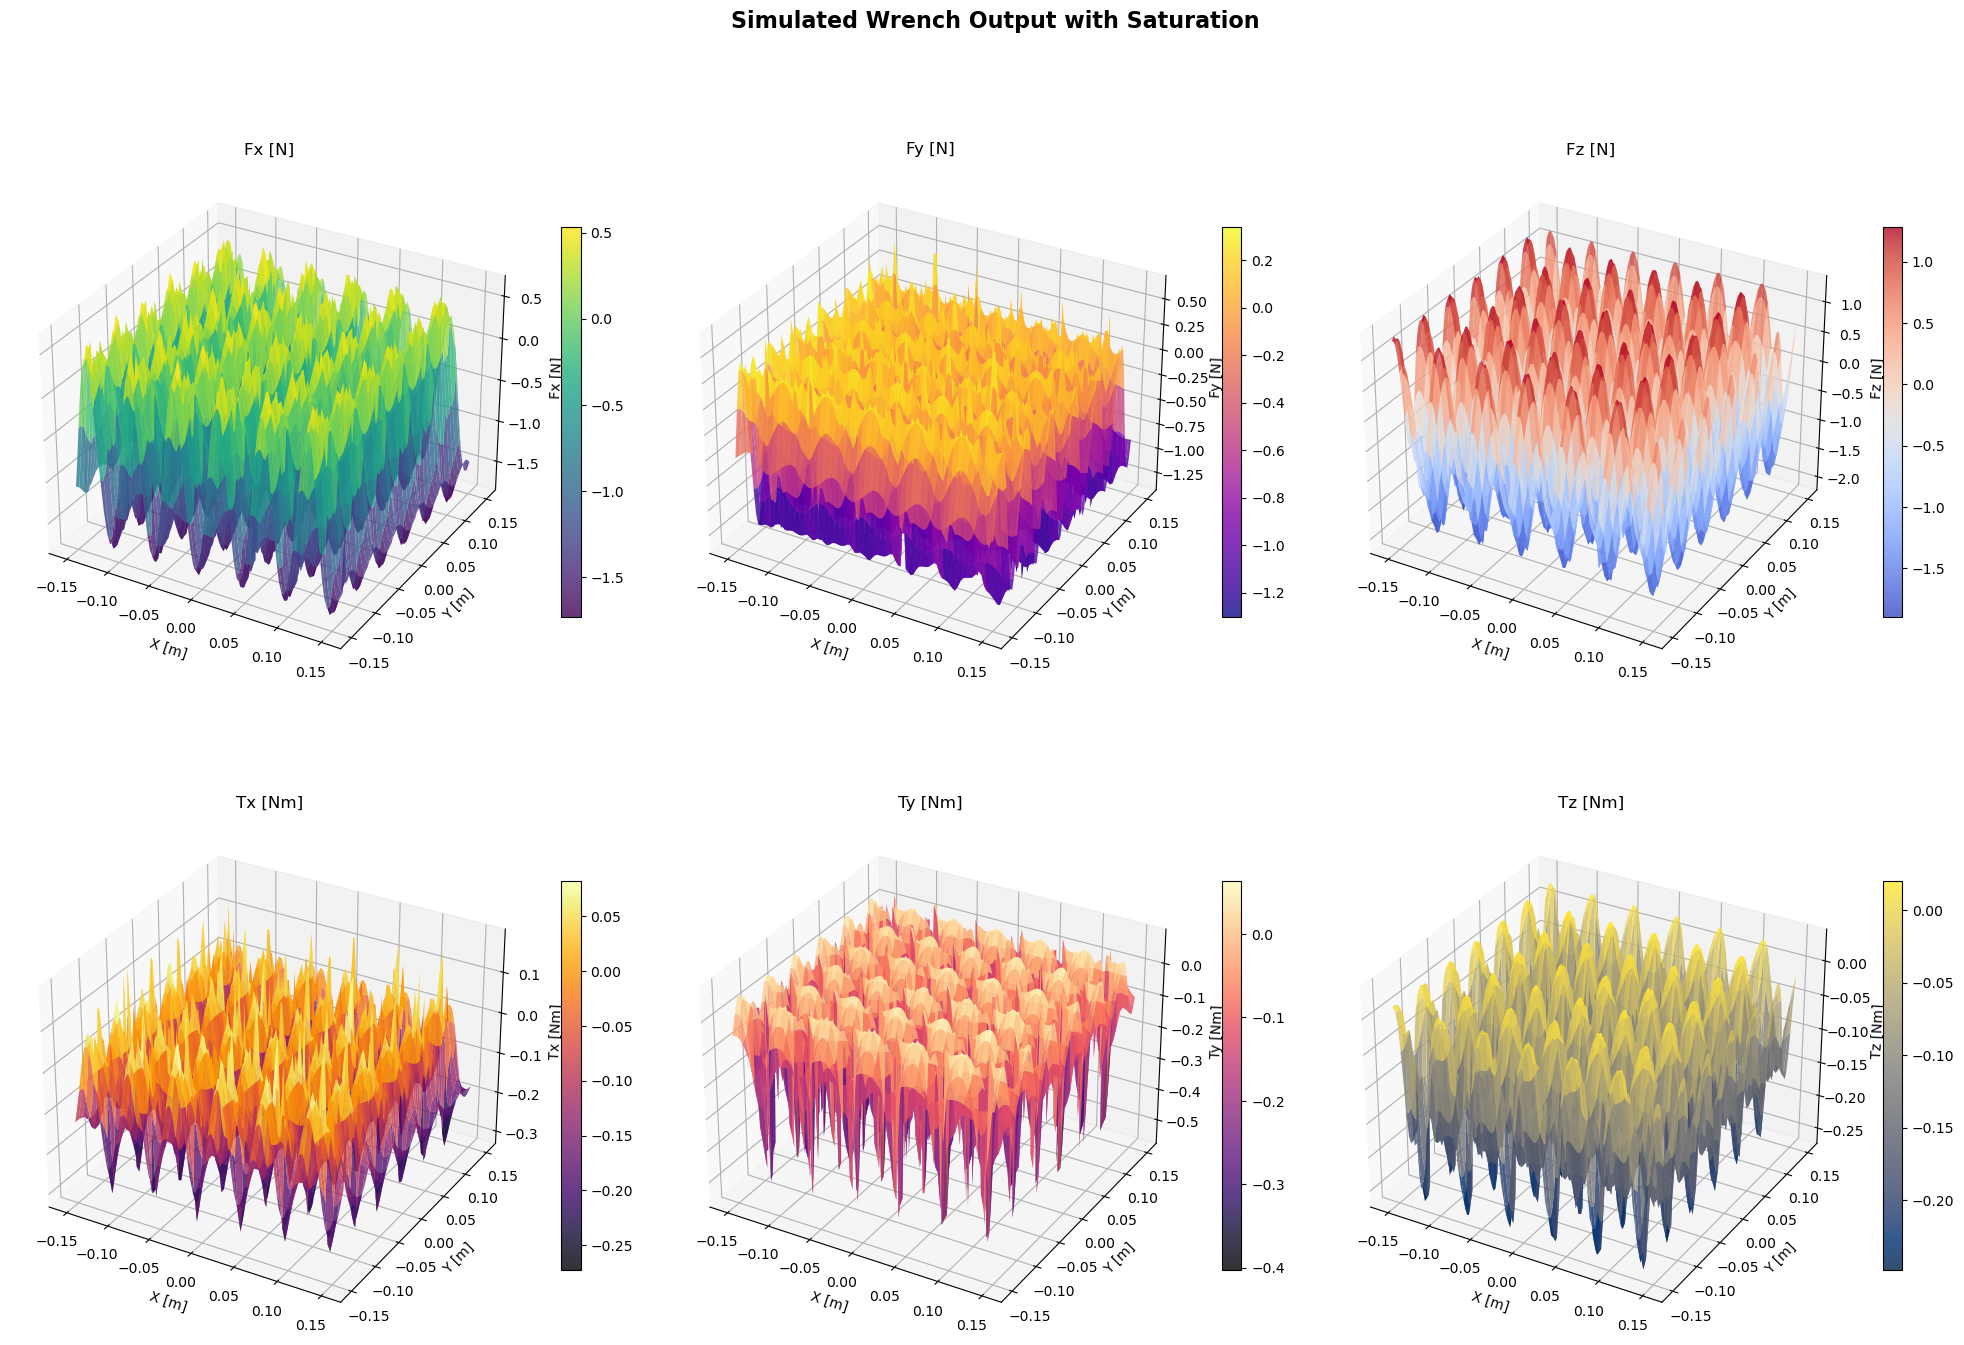


[VISUALIZATION] Summary Statistics:
Fx range: [-1.808, 0.689] N
Fy range: [-1.389, 0.684] N
Fz range: [-2.161, 1.359] N
Tx range: [-0.321, 0.194] Nm
Ty range: [-0.564, 0.092] Nm
Tz range: [-0.267, 0.039] Nm
[VISUALIZATION] Visualization completed!
Generated plot: wrench_field_visualization.png
Grid resolution: 100x100
Target wrench: [0, 0, 1, 0, 0, 0]
Fixed parameters: α=0.0°, β=0.0°, γ=0.6°, z=5.0mm


In [21]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import tensorflow as tf
import pickle

def create_wrench_field_visualization(model_path="ML_ns_policy.weights.h5",
                                   pose_scaler_path="ML_pose_scaler.pkl",
                                   wrench_scaler_path="ML_wrench_scaler.pkl",
                                   target_wrench=[0, 0, 1, 0, 0, 0],
                                   x_range=(-0.15, 0.15), y_range=(-0.15, 0.15),
                                   resolution=50,
                                   alpha_fixed=np.pi/6, beta_fixed=np.pi/6, gamma_fixed=0.0,
                                   z_fixed=0.005):
    """
    Create a 3D visualization of wrench output over X-Y plane for fixed desired wrench
    """
    print("[VISUALIZATION] Loading trained model...")
    
    # Load model
    model = PhysicsInformedNullspaceNet()
    # Initialize with dummy inputs
    dummy_X = tf.zeros((1,12), dtype=tf.float32)
    dummy_pose = tf.zeros((1,6), dtype=tf.float32)
    dummy_w = tf.zeros((1,6), dtype=tf.float32)
    _ = model(dummy_X, dummy_pose, dummy_w, training=False)
    model.load_weights(model_path)
    print("[VISUALIZATION] Model loaded successfully")
    
    # Load scalers
    print("[VISUALIZATION] Loading scalers...")
    with open(pose_scaler_path, 'rb') as f:
        pose_scaler = pickle.load(f)
    with open(wrench_scaler_path, 'rb') as f:
        wrench_scaler = pickle.load(f)
    print("[VISUALIZATION] Scalers loaded")
    
    print("[VISUALIZATION] Creating meshgrid...")
    # Create X-Y grid
    x_vals = np.linspace(x_range[0], x_range[1], resolution)
    y_vals = np.linspace(y_range[0], y_range[1], resolution)
    X, Y = np.meshgrid(x_vals, y_vals)
    
    # Create position arrays
    x_flat = X.flatten()
    y_flat = Y.flatten()
    
    # Fixed parameters
    z_flat = np.full_like(x_flat, z_fixed)
    alpha_flat = np.full_like(x_flat, alpha_fixed)
    beta_flat = np.full_like(x_flat, beta_fixed)
    gamma_flat = np.full_like(x_flat, gamma_fixed)
    
    # Combine into pose array
    poses = np.stack([x_flat, y_flat, z_flat, alpha_flat, beta_flat, gamma_flat], axis=-1)
    
    # Normalize target wrench
    target_wrench_array = np.array([target_wrench]).astype(np.float32)
    target_wrench_norm = wrench_scaler.transform(target_wrench_array).flatten()
    
    # Prepare input data
    print("[VISUALIZATION] Preparing input data...")
    pose_normalized = pose_scaler.transform(poses).astype(np.float32)
    input_data = np.concatenate([pose_normalized, np.tile(target_wrench_norm, (len(poses), 1))], axis=1)
    
    print("[VISUALIZATION] Predicting currents...")
    # Predict currents (FIXED: unpack all 3 return values)
    I_pred, W_pred, z_pred = model(
        tf.constant(input_data, dtype=tf.float32),
        tf.constant(poses, dtype=tf.float32),
        tf.constant(target_wrench_norm.reshape(1, -1), dtype=tf.float32),
        training=False
    )
    
    # Convert back to original scale
    predicted_currents = I_pred.numpy()
    predicted_wrenches = W_pred.numpy()
    
    # Convert to original scale
    predicted_wrenches_original = wrench_scaler.inverse_transform(predicted_wrenches)
    
    # Reshape back to 2D grids
    Fx = predicted_wrenches_original[:, 0].reshape(X.shape)
    Fy = predicted_wrenches_original[:, 1].reshape(X.shape)
    Fz = predicted_wrenches_original[:, 2].reshape(X.shape)
    Tx = predicted_wrenches_original[:, 3].reshape(X.shape)
    Ty = predicted_wrenches_original[:, 4].reshape(X.shape)
    Tz = predicted_wrenches_original[:, 5].reshape(X.shape)
    
    print("[VISUALIZATION] Creating 3D plots...")
    fig = plt.figure(figsize=(20, 15))
    
    # Plot Fx
    ax1 = fig.add_subplot(2, 3, 1, projection='3d')
    surf1 = ax1.plot_surface(X, Y, Fx, cmap='viridis', alpha=0.8)
    ax1.set_xlabel('X [m]')
    ax1.set_ylabel('Y [m]')
    ax1.set_zlabel('Fx [N]')
    ax1.set_title('Fx [N]')
    fig.colorbar(surf1, ax=ax1, shrink=0.5)
    
    # Plot Fy
    ax2 = fig.add_subplot(2, 3, 2, projection='3d')
    surf2 = ax2.plot_surface(X, Y, Fy, cmap='plasma', alpha=0.8)
    ax2.set_xlabel('X [m]')
    ax2.set_ylabel('Y [m]')
    ax2.set_zlabel('Fy [N]')
    ax2.set_title('Fy [N]')
    fig.colorbar(surf2, ax=ax2, shrink=0.5)
    
    # Plot Fz
    ax3 = fig.add_subplot(2, 3, 3, projection='3d')
    surf3 = ax3.plot_surface(X, Y, Fz, cmap='coolwarm', alpha=0.8)
    ax3.set_xlabel('X [m]')
    ax3.set_ylabel('Y [m]')
    ax3.set_zlabel('Fz [N]')
    ax3.set_title('Fz [N]')
    fig.colorbar(surf3, ax=ax3, shrink=0.5)
    
    # Plot Tx
    ax4 = fig.add_subplot(2, 3, 4, projection='3d')
    surf4 = ax4.plot_surface(X, Y, Tx, cmap='inferno', alpha=0.8)
    ax4.set_xlabel('X [m]')
    ax4.set_ylabel('Y [m]')
    ax4.set_zlabel('Tx [Nm]')
    ax4.set_title('Tx [Nm]')
    fig.colorbar(surf4, ax=ax4, shrink=0.5)
    
    # Plot Ty
    ax5 = fig.add_subplot(2, 3, 5, projection='3d')
    surf5 = ax5.plot_surface(X, Y, Ty, cmap='magma', alpha=0.8)
    ax5.set_xlabel('X [m]')
    ax5.set_ylabel('Y [m]')
    ax5.set_zlabel('Ty [Nm]')
    ax5.set_title('Ty [Nm]')
    fig.colorbar(surf5, ax=ax5, shrink=0.5)
    
    # Plot Tz
    ax6 = fig.add_subplot(2, 3, 6, projection='3d')
    surf6 = ax6.plot_surface(X, Y, Tz, cmap='cividis', alpha=0.8)
    ax6.set_xlabel('X [m]')
    ax6.set_ylabel('Y [m]')
    ax6.set_zlabel('Tz [Nm]')
    ax6.set_title('Tz [Nm]')
    fig.colorbar(surf6, ax=ax6, shrink=0.5)
    
    plt.suptitle('Simulated Wrench Output with Saturation', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('wrench_field_visualization.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print summary statistics
    print("\n[VISUALIZATION] Summary Statistics:")
    print(f"Fx range: [{Fx.min():.3f}, {Fx.max():.3f}] N")
    print(f"Fy range: [{Fy.min():.3f}, {Fy.max():.3f}] N")
    print(f"Fz range: [{Fz.min():.3f}, {Fz.max():.3f}] N")
    print(f"Tx range: [{Tx.min():.3f}, {Tx.max():.3f}] Nm")
    print(f"Ty range: [{Ty.min():.3f}, {Ty.max():.3f}] Nm")
    print(f"Tz range: [{Tz.min():.3f}, {Tz.max():.3f}] Nm")
    
    print("[VISUALIZATION] Visualization completed!")
    print(f"Generated plot: wrench_field_visualization.png")
    print(f"Grid resolution: {resolution}x{resolution}")
    print(f"Target wrench: {target_wrench}")
    print(f"Fixed parameters: α={np.rad2deg(alpha_fixed):.1f}°, β={np.rad2deg(beta_fixed):.1f}°, γ={np.rad2deg(gamma_fixed):.1f}°, z={z_fixed*1000:.1f}mm")

# Run the visualization
if __name__ == "__main__":
    print("[MAIN] Starting wrench field visualization...")
    try:
        create_wrench_field_visualization(
            model_path="ML3_ns_policy.weights.h5",
            pose_scaler_path="ML3_pose_scaler.pkl",
            wrench_scaler_path="ML3_wrench_scaler.pkl",
            target_wrench=[0, 0, 1, 0, 0, 0],  # Desired force in Z direction
            x_range=(-0.15, 0.15),  # X range in meters
            y_range=(-0.15, 0.15),  # Y range in meters
            resolution=100,  # Grid resolution
            alpha_fixed=0,  # 0 degrees
            beta_fixed=0,   # 0 degrees
            gamma_fixed=0.01,      # 0 degrees
            z_fixed=0.005         # 5mm
        )
    except Exception as e:
        print(f"[ERROR] Visualization failed: {e}")
        import traceback
        traceback.print_exc()

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import tensorflow as tf
import pickle

def create_wrench_field_visualization(model_path="ML3_ns_policy.weights.h5",
                                   pose_scaler_path="ML3_pose_scaler.pkl",
                                   wrench_scaler_path="ML3_wrench_scaler.pkl",
                                   target_wrench=[0, 0, 1, 0, 0, 0],
                                   x_range=(-0.15, 0.15), y_range=(-0.15, 0.15),
                                   resolution=50,
                                   alpha_fixed=0.0, beta_fixed=0.0, gamma_fixed=0.0,
                                   z_fixed=0.005):
    """
    Create two visualizations:
      1. Wrench output (Fx, Fy, Fz, Tx, Ty, Tz) over X-Y plane
      2. Predicted coil currents (I0 to I15) in 4x4 layout over X-Y plane
    """
    print("[VISUALIZATION] Loading trained model...")
    
    # Load model
    model = PhysicsInformedNullspaceNet()
    dummy_X = tf.zeros((1, 12), dtype=tf.float32)
    dummy_pose = tf.zeros((1, 6), dtype=tf.float32)
    dummy_w = tf.zeros((1, 6), dtype=tf.float32)
    _ = model(dummy_X, dummy_pose, dummy_w, training=False)
    model.load_weights(model_path)
    print("[VISUALIZATION] Model loaded successfully")
    
    # Load scalers
    print("[VISUALIZATION] Loading scalers...")
    with open(pose_scaler_path, 'rb') as f:
        pose_scaler = pickle.load(f)
    with open(wrench_scaler_path, 'rb') as f:
        wrench_scaler = pickle.load(f)
    print("[VISUALIZATION] Scalers loaded")
    
    # Create X-Y grid
    x_vals = np.linspace(x_range[0], x_range[1], resolution)
    y_vals = np.linspace(y_range[0], y_range[1], resolution)
    X, Y = np.meshgrid(x_vals, y_vals)
    
    # Flatten for batch prediction
    x_flat = X.flatten()
    y_flat = Y.flatten()
    z_flat = np.full_like(x_flat, z_fixed)
    alpha_flat = np.full_like(x_flat, alpha_fixed)
    beta_flat = np.full_like(x_flat, beta_fixed)
    gamma_flat = np.full_like(x_flat, gamma_fixed)
    
    poses = np.stack([x_flat, y_flat, z_flat, alpha_flat, beta_flat, gamma_flat], axis=-1)
    
    # Normalize inputs
    target_wrench_norm = wrench_scaler.transform([target_wrench]).flatten()
    pose_normalized = pose_scaler.transform(poses).astype(np.float32)
    input_data = np.concatenate([pose_normalized, np.tile(target_wrench_norm, (len(poses), 1))], axis=1)
    
    print("[VISUALIZATION] Running inference to predict wrench and currents...")
    I_pred, W_pred, _ = model(
        tf.constant(input_data, dtype=tf.float32),
        tf.constant(poses, dtype=tf.float32),
        tf.constant(np.array([target_wrench_norm]), dtype=tf.float32),
        training=False
    )
    
    predicted_currents = I_pred.numpy()  # Shape: (N, 16)
    predicted_wrenches = W_pred.numpy()
    predicted_wrenches_original = wrench_scaler.inverse_transform(predicted_wrenches)  # Denormalize
    
    # Reshape wrench components to 2D
    Fx = predicted_wrenches_original[:, 0].reshape(X.shape)
    Fy = predicted_wrenches_original[:, 1].reshape(X.shape)
    Fz = predicted_wrenches_original[:, 2].reshape(X.shape)
    Tx = predicted_wrenches_original[:, 3].reshape(X.shape)
    Ty = predicted_wrenches_original[:, 4].reshape(X.shape)
    Tz = predicted_wrenches_original[:, 5].reshape(X.shape)

    # ================================
    # PLOT 1: WRENCH FIELD
    # ================================
    print("[VISUALIZATION] Creating wrench field plots...")
    fig1 = plt.figure(figsize=(20, 15))
    components = [Fx, Fy, Fz, Tx, Ty, Tz]
    titles = ['Fx [N]', 'Fy [N]', 'Fz [N]', 'Tx [Nm]', 'Ty [Nm]', 'Tz [Nm]']
    cmaps = ['viridis', 'plasma', 'coolwarm', 'inferno', 'magma', 'cividis']
    
    for i, (data, title, cmap) in enumerate(zip(components, titles, cmaps)):
        ax = fig1.add_subplot(2, 3, i+1, projection='3d')
        surf = ax.plot_surface(X, Y, data, cmap=cmap, alpha=0.8)
        ax.set_xlabel('X [m]')
        ax.set_ylabel('Y [m]')
        ax.set_zlabel(title)
        ax.set_title(title)
        fig1.colorbar(surf, ax=ax, shrink=0.5)
    
    fig1.suptitle('Predicted Wrench Field', fontsize=16, fontweight='bold')
    plt.tight_layout()
    fig1.savefig('wrench_field_visualization.png', dpi=300, bbox_inches='tight')
    plt.show()

    # ================================
    # PLOT 2: COIL CURRENTS (4x4 Grid)
    # ================================
    print("[VISUALIZATION] Creating coil current plots...")
    fig2 = plt.figure(figsize=(18, 16))
    fig2.suptitle('Predicted Coil Currents (4×4 Grid) for Target Wrench', fontsize=16, fontweight='bold')

    tau = 0.0508  # coil pitch in meters
    coil_x_coords = np.array([j * tau - 1.5*tau for j in range(4)])  # center at 0
    coil_y_coords = np.array([i * tau - 1.5*tau for i in range(4)])

    current_min = predicted_currents.min()
    current_max = predicted_currents.max()
    global_vlim = max(abs(current_min), abs(current_max))

    for idx in range(16):
        coil_currents = predicted_currents[:, idx].reshape(X.shape)
        
        row = idx // 4
        col = idx % 4
        
        ax = fig2.add_subplot(4, 4, idx + 1, projection='3d')
        surf = ax.plot_surface(X, Y, coil_currents, cmap='RdYlBu_r', alpha=0.8, vmin=-global_vlim, vmax=global_vlim)
        
        # Highlight the physical coil position
        ax.scatter(coil_x_coords[col], coil_y_coords[row], -global_vlim*1.1,
                   color='k', s=40, marker='x', label=f'Coil {idx}')
        
        ax.set_xlabel('X [m]')
        ax.set_ylabel('Y [m]')
        ax.set_zlabel('I [A]')
        ax.set_title(f'Coil {idx} (I{idx})')
        
        # Optional: set zlim for cleaner view
        ax.set_zlim(-global_vlim*1.2, global_vlim*1.2)
        
        # Colorbar only on edge plots to avoid clutter
        if col == 3:
            fig2.colorbar(surf, ax=ax, shrink=0.6, label='Current [A]')

    plt.tight_layout()
    fig2.savefig('coil_currents_visualization.png', dpi=300, bbox_inches='tight')
    plt.show()

    # ================================
    # SUMMARY STATISTICS
    # ================================
    print("\n[VISUALIZATION] Summary Statistics:")
    print(f"Target Wrench: {target_wrench}")
    print(f"Fixed Pose: α={np.rad2deg(alpha_fixed):.1f}°, β={np.rad2deg(beta_fixed):.1f}°, "
          f"γ={np.rad2deg(gamma_fixed):.1f}°, z={z_fixed*1000:.1f} mm")
    print(f"Grid Resolution: {resolution}×{resolution}")
    
    print("\n--- Wrench Output Ranges ---")
    print(f"Fx: [{Fx.min():.3f}, {Fx.max():.3f}] N")
    print(f"Fy: [{Fy.min():.3f}, {Fy.max():.3f}] N")
    print(f"Fz: [{Fz.min():.3f}, {Fz.max():.3f}] N")
    print(f"Tx: [{Tx.min():.3f}, {Tx.max():.3f}] Nm")
    print(f"Ty: [{Ty.min():.3f}, {Ty.max():.3f}] Nm")
    print(f"Tz: [{Tz.min():.3f}, {Tz.max():.3f}] Nm")

    print("\n--- Coil Current Ranges ---")
    for i in range(16):
        ci = predicted_currents[:, i]
        print(f"Coil {i}: [{ci.min():.3f}, {ci.max():.3f}] A  (mean={ci.mean():.3f} A)")

    total_max_current = predicted_currents.max()
    total_min_current = predicted_currents.min()
    print(f"\nOverall Current Range: [{total_min_current:.3f}, {total_max_current:.3f}] A")
    if total_max_current > 8.0 or total_min_current < -8.0:
        print("⚠️  WARNING: Some currents exceed ±8A hardware limit!")
    else:
        print("✅ All currents within ±8A limit.")

    print(f"\n[VISUALIZATION] Done! Saved:")
    print("  - wrench_field_visualization.png")
    print("  - coil_currents_visualization.png")


create_wrench_field_visualization(model_path="ML3_ns_policy.weights.h5",
                                   pose_scaler_path="ML3_pose_scaler.pkl",
                                   wrench_scaler_path="ML3_wrench_scaler.pkl",
                                   target_wrench=[25, 18, 100, 3, 6, 10],
                                   x_range=(-0.15, 0.15), y_range=(-0.15, 0.15),
                                   resolution=100,
                                   alpha_fixed=0.1, beta_fixed=0.1, gamma_fixed=0.5,
                                   z_fixed=0.005)

[VISUALIZATION] Loading trained model...
[VISUALIZATION] Model loaded successfully
[VISUALIZATION] Loading scalers...
[VISUALIZATION] Scalers loaded
[VISUALIZATION] Running inference to predict wrench and currents...


2025-09-03 02:10:26.337170: W external/local_tsl/tsl/framework/bfc_allocator.cc:487] Allocator (GPU_0_bfc) ran out of memory trying to allocate 19.53MiB (rounded to 20480000)requested by op BiasAdd
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
2025-09-03 02:10:26.337210: I external/local_tsl/tsl/framework/bfc_allocator.cc:1044] BFCAllocator dump for GPU_0_bfc
2025-09-03 02:10:26.337216: I external/local_tsl/tsl/framework/bfc_allocator.cc:1051] Bin (256): 	Total Chunks: 103, Chunks in use: 103. 25.8KiB allocated for chunks. 25.8KiB in use in bin. 1.8KiB client-requested in use in bin.
2025-09-03 02:10:26.337220: I external/local_tsl/tsl/framework/bfc_allocator.cc:1051] Bin (512): 	Total Chunks: 0, Chunks in use: 0. 0B allocated for chunks. 0B in use in bin. 0B client-requested in use in bin.
2025-09-03 02:10:26.337223: I external

ResourceExhaustedError: Exception encountered when calling Dense.call().

[1m{{function_node __wrapped__BiasAdd_device_/job:localhost/replica:0/task:0/device:GPU:0}} OOM when allocating tensor with shape[10000,512] and type float on /job:localhost/replica:0/task:0/device:GPU:0 by allocator GPU_0_bfc [Op:BiasAdd][0m

Arguments received by Dense.call():
  • inputs=tf.Tensor(shape=(10000, 12), dtype=float32)
  • training=False

[MAIN] Starting wrench field visualization (top view)...
[VISUALIZATION] Loading trained model...
[VISUALIZATION] Model loaded successfully
[VISUALIZATION] Loading scalers...
[VISUALIZATION] Scalers loaded
[VISUALIZATION] Creating meshgrid...
[VISUALIZATION] Preparing input data...
[VISUALIZATION] Predicting currents...
[VISUALIZATION] Creating top-view heatmaps...
Fx [N]: min=-2.474, max=0.560, mean=-1.302
Fy [N]: min=-1.399, max=1.444, mean=0.031
Fz [N]: min=-2.763, max=1.474, mean=-1.102
Tx [Nm]: min=-0.225, max=0.389, mean=0.052
Ty [Nm]: min=-0.625, max=0.017, mean=-0.194
Tz [Nm]: min=-0.171, max=0.248, mean=0.028


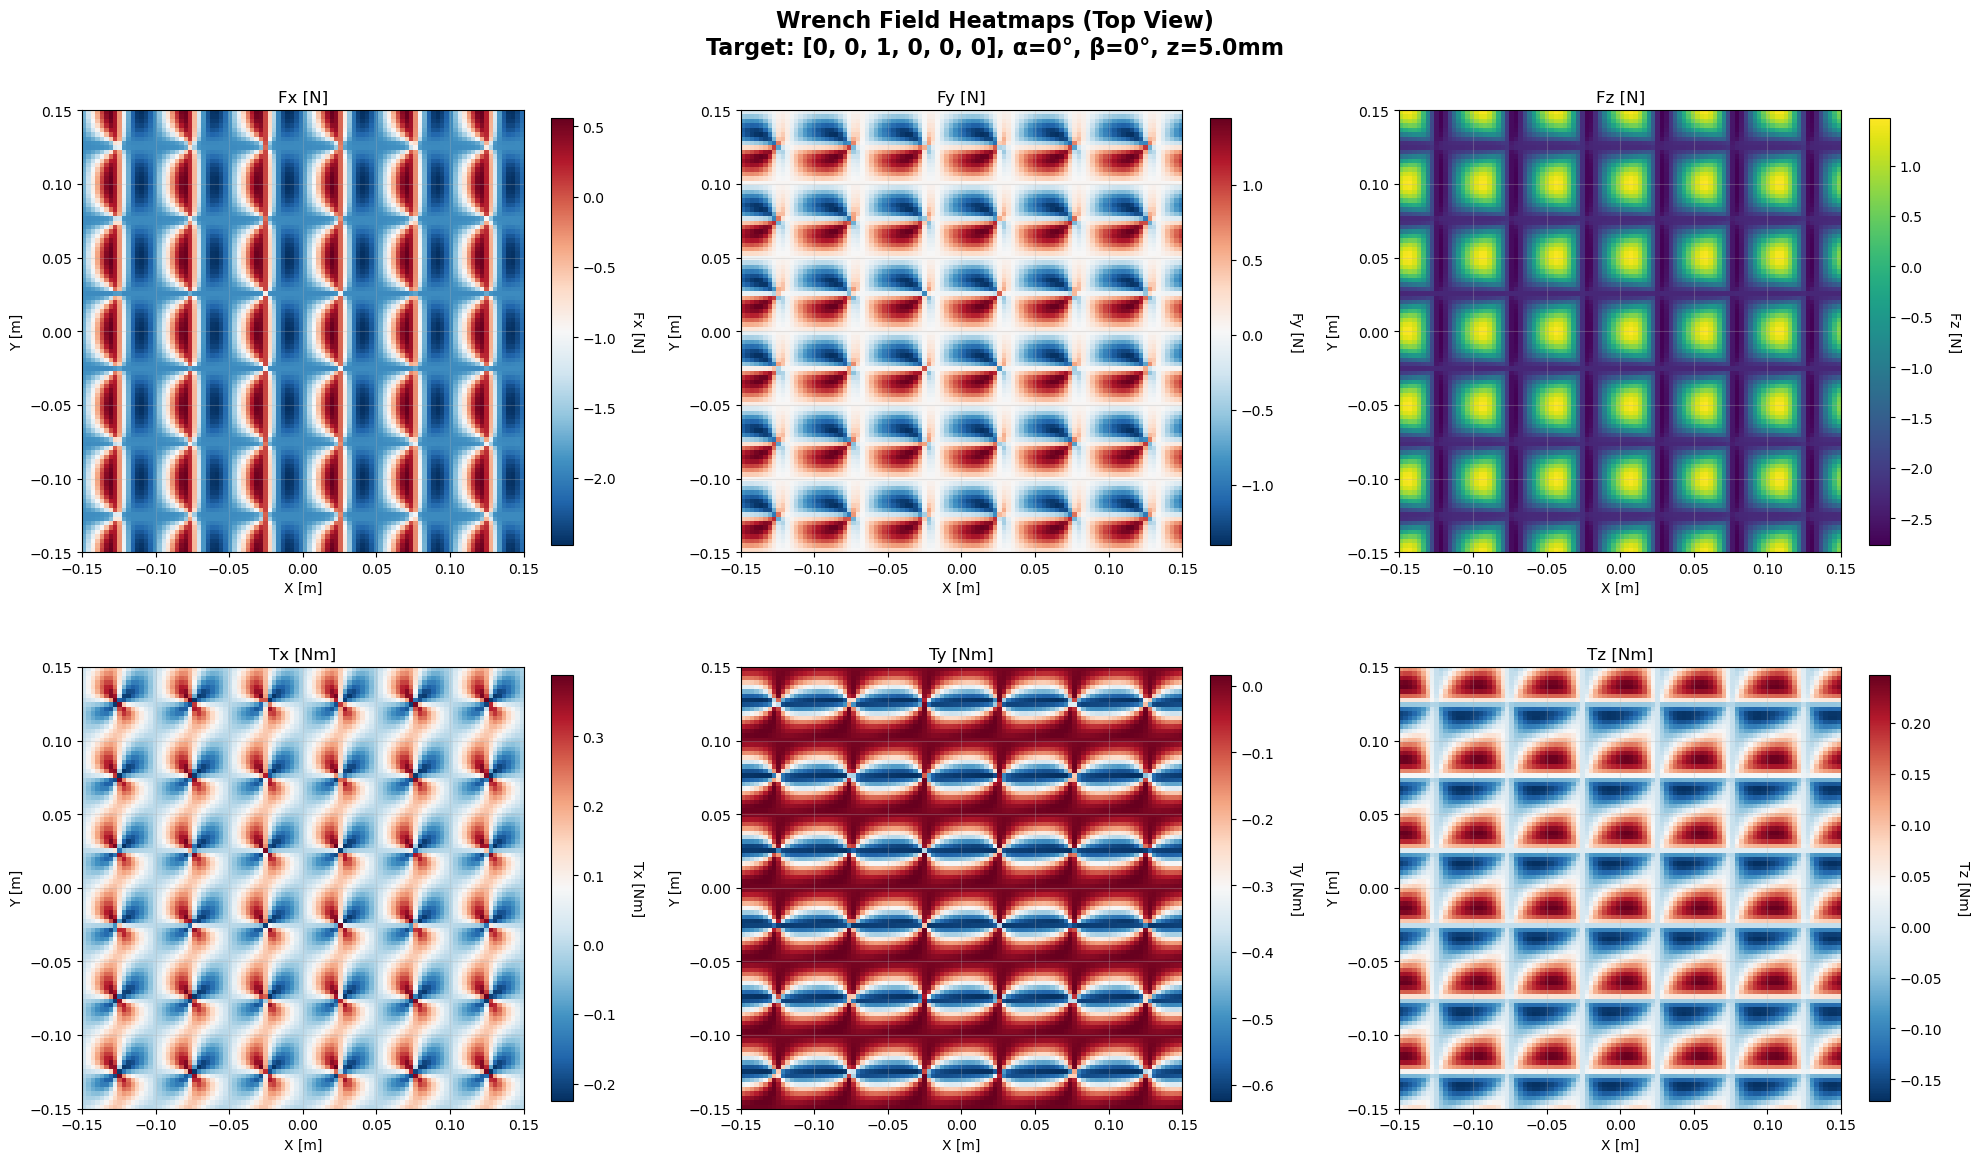

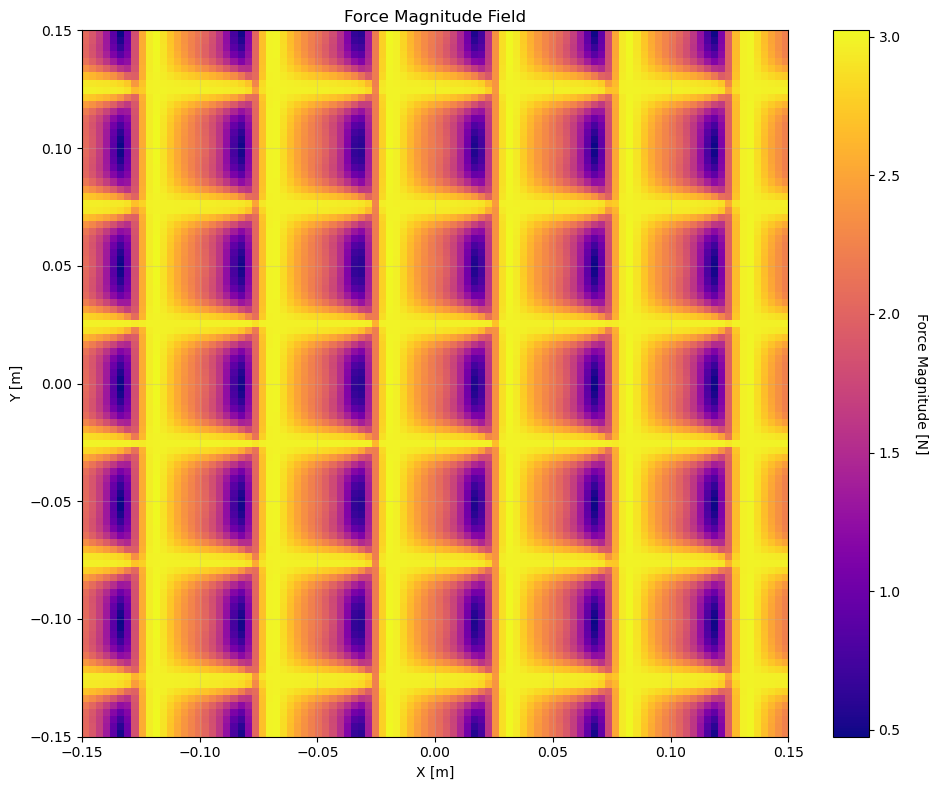


[VISUALIZATION] Summary Statistics:
Force magnitude range: [0.476, 3.023] N
Torque magnitude range: [0.000, 0.636] Nm
[VISUALIZATION] Visualization completed!
Generated plots: wrench_field_heatmaps.png, force_magnitude_heatmap.png
Grid resolution: 100x100


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pickle

def create_wrench_field_visualization_topview(model_path="ML_ns_policy.weights.h5",
                                   pose_scaler_path="ML_pose_scaler.pkl",
                                   wrench_scaler_path="ML_wrench_scaler.pkl",
                                   target_wrench=[0, 0, 1, 0, 0, 0],
                                   x_range=(-0.15, 0.15), y_range=(-0.15, 0.15),
                                   resolution=100,
                                   alpha_fixed=0, beta_fixed=0, gamma_fixed=0.0,
                                   z_fixed=0.005):
    """
    Create top-view heatmap visualization of wrench output over X-Y plane for fixed desired wrench
    """
    print("[VISUALIZATION] Loading trained model...")
    
    # Load model
    model = PhysicsInformedNullspaceNet()
    # Initialize with dummy inputs
    dummy_X = tf.zeros((1,12), dtype=tf.float32)
    dummy_pose = tf.zeros((1,6), dtype=tf.float32)
    dummy_w = tf.zeros((1,6), dtype=tf.float32)
    _ = model(dummy_X, dummy_pose, dummy_w, training=False)
    model.load_weights(model_path)
    print("[VISUALIZATION] Model loaded successfully")
    
    # Load scalers
    print("[VISUALIZATION] Loading scalers...")
    with open(pose_scaler_path, 'rb') as f:
        pose_scaler = pickle.load(f)
    with open(wrench_scaler_path, 'rb') as f:
        wrench_scaler = pickle.load(f)
    print("[VISUALIZATION] Scalers loaded")
    
    print("[VISUALIZATION] Creating meshgrid...")
    # Create X-Y grid
    x_vals = np.linspace(x_range[0], x_range[1], resolution)
    y_vals = np.linspace(y_range[0], y_range[1], resolution)
    X, Y = np.meshgrid(x_vals, y_vals)
    
    # Create position arrays
    x_flat = X.flatten()
    y_flat = Y.flatten()
    
    # Fixed parameters
    z_flat = np.full_like(x_flat, z_fixed)
    alpha_flat = np.full_like(x_flat, alpha_fixed)
    beta_flat = np.full_like(x_flat, beta_fixed)
    gamma_flat = np.full_like(x_flat, gamma_fixed)
    
    # Combine into pose array
    poses = np.stack([x_flat, y_flat, z_flat, alpha_flat, beta_flat, gamma_flat], axis=-1)
    
    # Normalize target wrench
    target_wrench_array = np.array([target_wrench]).astype(np.float32)
    target_wrench_norm = wrench_scaler.transform(target_wrench_array).flatten()
    
    # Prepare input data
    print("[VISUALIZATION] Preparing input data...")
    pose_normalized = pose_scaler.transform(poses).astype(np.float32)
    input_data = np.concatenate([pose_normalized, np.tile(target_wrench_norm, (len(poses), 1))], axis=1)
    
    print("[VISUALIZATION] Predicting currents...")
    # Predict currents (unpack all 3 return values)
    I_pred, W_pred, z_pred = model(
        tf.constant(input_data, dtype=tf.float32),
        tf.constant(poses, dtype=tf.float32),
        tf.constant(target_wrench_norm.reshape(1, -1), dtype=tf.float32),
        training=False
    )
    
    # Convert back to original scale
    predicted_currents = I_pred.numpy()
    predicted_wrenches = W_pred.numpy()
    
    # Convert to original scale
    predicted_wrenches_original = wrench_scaler.inverse_transform(predicted_wrenches)
    
    # Reshape back to 2D grids
    Fx = predicted_wrenches_original[:, 0].reshape(X.shape)
    Fy = predicted_wrenches_original[:, 1].reshape(X.shape)
    Fz = predicted_wrenches_original[:, 2].reshape(X.shape)
    Tx = predicted_wrenches_original[:, 3].reshape(X.shape)
    Ty = predicted_wrenches_original[:, 4].reshape(X.shape)
    Tz = predicted_wrenches_original[:, 5].reshape(X.shape)
    
    print("[VISUALIZATION] Creating top-view heatmaps...")
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle(f'Wrench Field Heatmaps (Top View)\nTarget: {target_wrench}, α={np.rad2deg(alpha_fixed):.0f}°, β={np.rad2deg(beta_fixed):.0f}°, z={z_fixed*1000:.1f}mm', 
                 fontsize=16, fontweight='bold')
    
    # Flatten axes for easier indexing
    axes_flat = axes.flatten()
    
    # Data and labels
    wrench_data = [Fx, Fy, Fz, Tx, Ty, Tz]
    component_labels = ['Fx [N]', 'Fy [N]', 'Fz [N]', 'Tx [Nm]', 'Ty [Nm]', 'Tz [Nm]']
    color_maps = ['RdBu_r', 'RdBu_r', 'viridis', 'RdBu_r', 'RdBu_r', 'RdBu_r']
    
    # Plot each component
    for i, (ax, data, label, cmap) in enumerate(zip(axes_flat, wrench_data, component_labels, color_maps)):
        # Create heatmap
        im = ax.imshow(data, extent=[x_range[0], x_range[1], y_range[0], y_range[1]], 
                      origin='lower', cmap=cmap, aspect='equal')
        
        # Add colorbar
        cbar = plt.colorbar(im, ax=ax, shrink=0.8)
        cbar.set_label(label, rotation=270, labelpad=20)
        
        # Set labels and title
        ax.set_xlabel('X [m]')
        ax.set_ylabel('Y [m]')
        ax.set_title(f'{label}')
        
        # Add grid for better readability
        ax.grid(True, alpha=0.3)
        
        # Print statistics for each component
        print(f"{label}: min={data.min():.3f}, max={data.max():.3f}, mean={data.mean():.3f}")
    
    plt.tight_layout()
    plt.savefig('wrench_field_heatmaps.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Create a combined magnitude plot
    fig2, ax2 = plt.subplots(1, 1, figsize=(10, 8))
    
    # Calculate force and torque magnitudes
    force_magnitude = np.sqrt(Fx**2 + Fy**2 + Fz**2)
    torque_magnitude = np.sqrt(Tx**2 + Ty**2 + Tz**2)
    
    # Plot force magnitude
    im2 = ax2.imshow(force_magnitude, extent=[x_range[0], x_range[1], y_range[0], y_range[1]], 
                     origin='lower', cmap='plasma', aspect='equal')
    
    # Add colorbar
    cbar2 = plt.colorbar(im2, ax=ax2)
    cbar2.set_label('Force Magnitude [N]', rotation=270, labelpad=20)
    
    # Set labels and title
    ax2.set_xlabel('X [m]')
    ax2.set_ylabel('Y [m]')
    ax2.set_title('Force Magnitude Field')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('force_magnitude_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print summary statistics
    print("\n[VISUALIZATION] Summary Statistics:")
    print(f"Force magnitude range: [{force_magnitude.min():.3f}, {force_magnitude.max():.3f}] N")
    print(f"Torque magnitude range: [{torque_magnitude.min():.3f}, {torque_magnitude.max():.3f}] Nm")
    
    print("[VISUALIZATION] Visualization completed!")
    print(f"Generated plots: wrench_field_heatmaps.png, force_magnitude_heatmap.png")
    print(f"Grid resolution: {resolution}x{resolution}")

# Run the visualization
if __name__ == "__main__":
    print("[MAIN] Starting wrench field visualization (top view)...")
    try:
        create_wrench_field_visualization_topview(
            model_path="ML3_ns_policy.weights.h5",
            pose_scaler_path="ML3_pose_scaler.pkl",
            wrench_scaler_path="ML3_wrench_scaler.pkl",
            target_wrench=[0, 0, 1, 0, 0, 0],  # Desired force in Z direction
            x_range=(-0.15, 0.15),  # X range in meters
            y_range=(-0.15, 0.15),  # Y range in meters
            resolution=100,  # Grid resolution
            alpha_fixed=0,  # 0 degrees
            beta_fixed=0,   # 0 degrees
            gamma_fixed=0.0,      # 0 degrees
            z_fixed=0.005         # 5mm
        )
    except Exception as e:
        print(f"[ERROR] Visualization failed: {e}")
        import traceback
        traceback.print_exc()

[MAIN] Starting wrench field visualization (top view)...
[VISUALIZATION] Loading trained model...
[VISUALIZATION] Model loaded successfully
[VISUALIZATION] Loading scalers...
[VISUALIZATION] Scalers loaded
[VISUALIZATION] Creating meshgrid...
[VISUALIZATION] Preparing input data...
[VISUALIZATION] Predicting currents...
[VISUALIZATION] Creating top-view heatmaps...
Fx [N]: min=-0.057, max=0.455, mean=0.028
Fy [N]: min=-0.505, max=0.164, mean=-0.021
Fz [N]: min=0.460, max=1.367, mean=0.996
Tx [Nm]: min=-0.099, max=0.218, mean=0.004
Ty [Nm]: min=-0.535, max=0.011, mean=-0.033
Tz [Nm]: min=-0.113, max=0.116, mean=-0.000


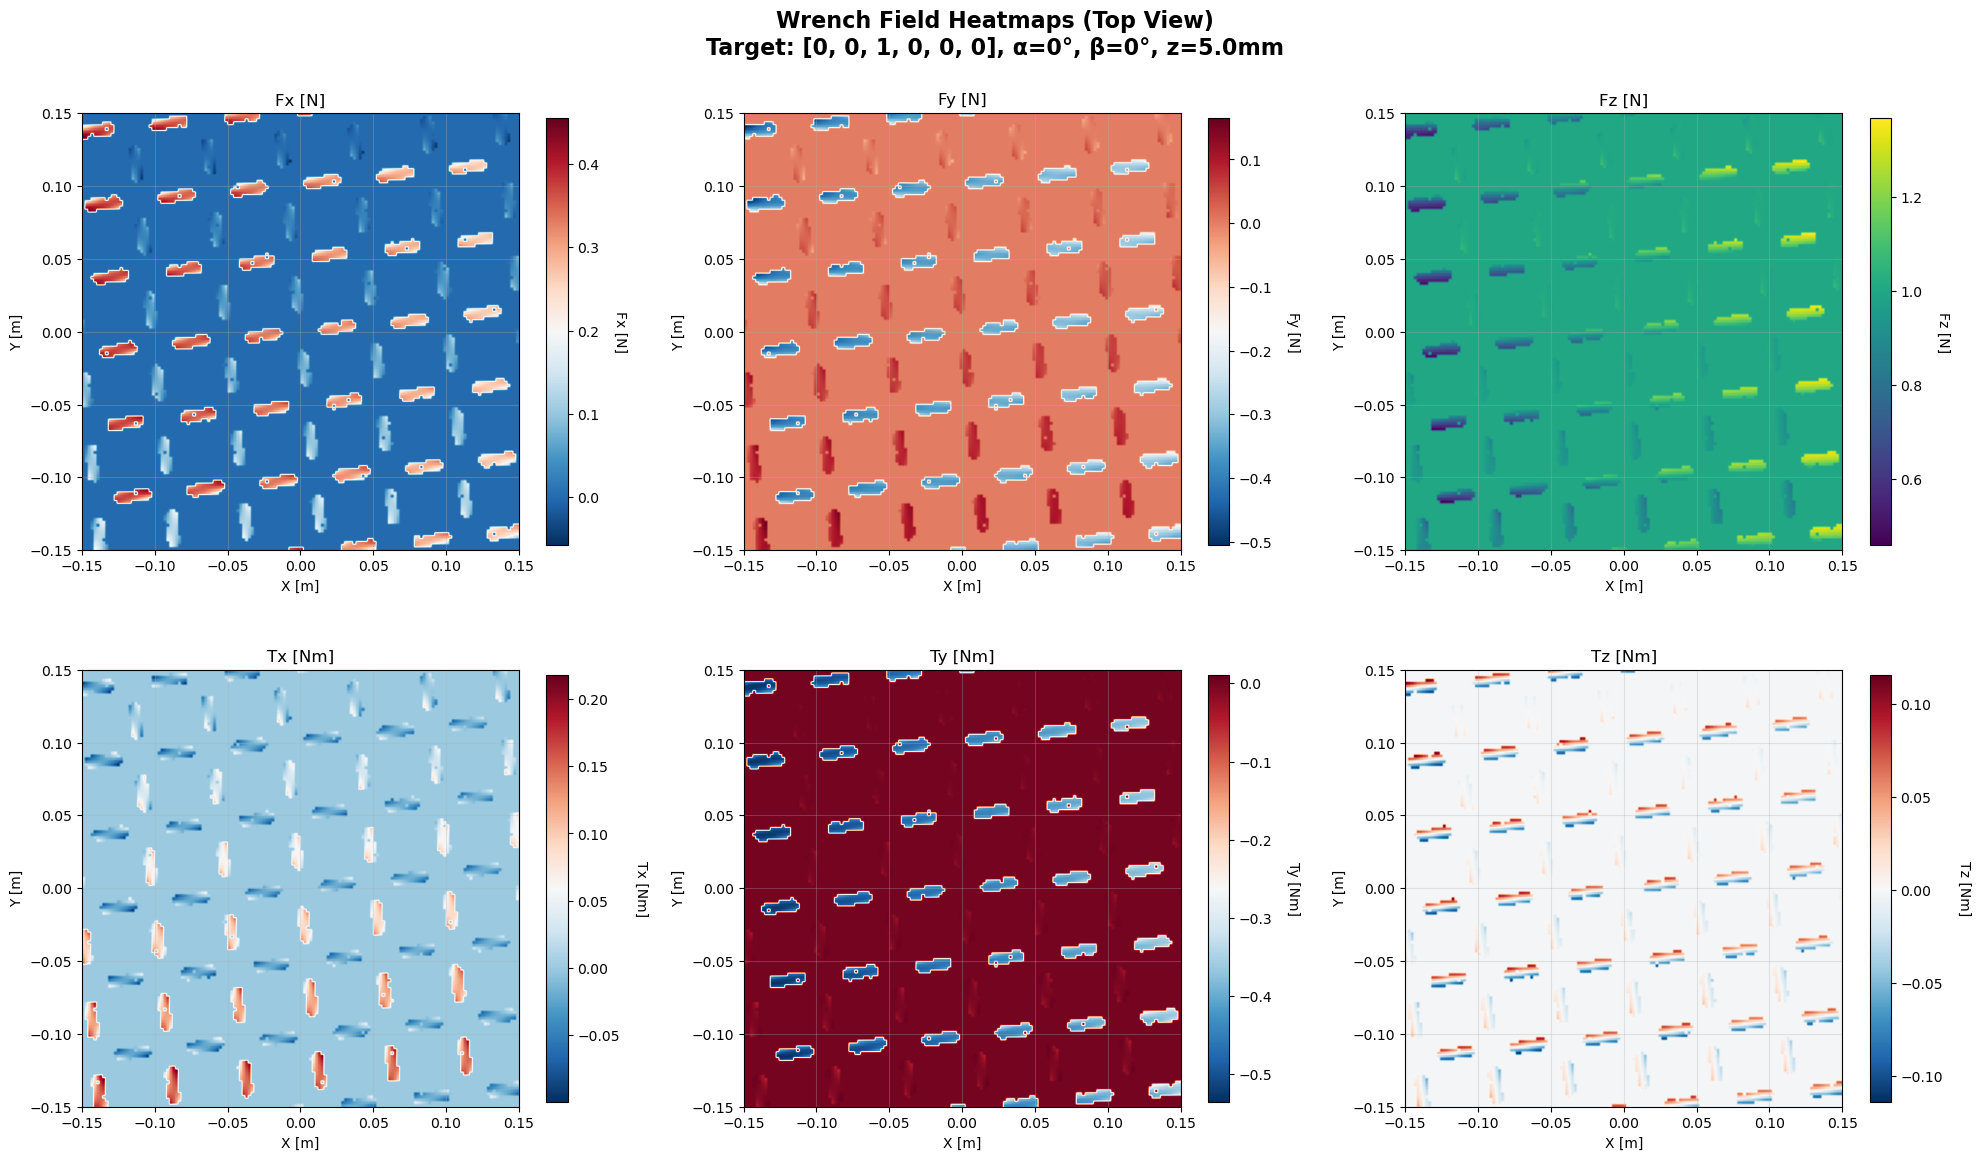

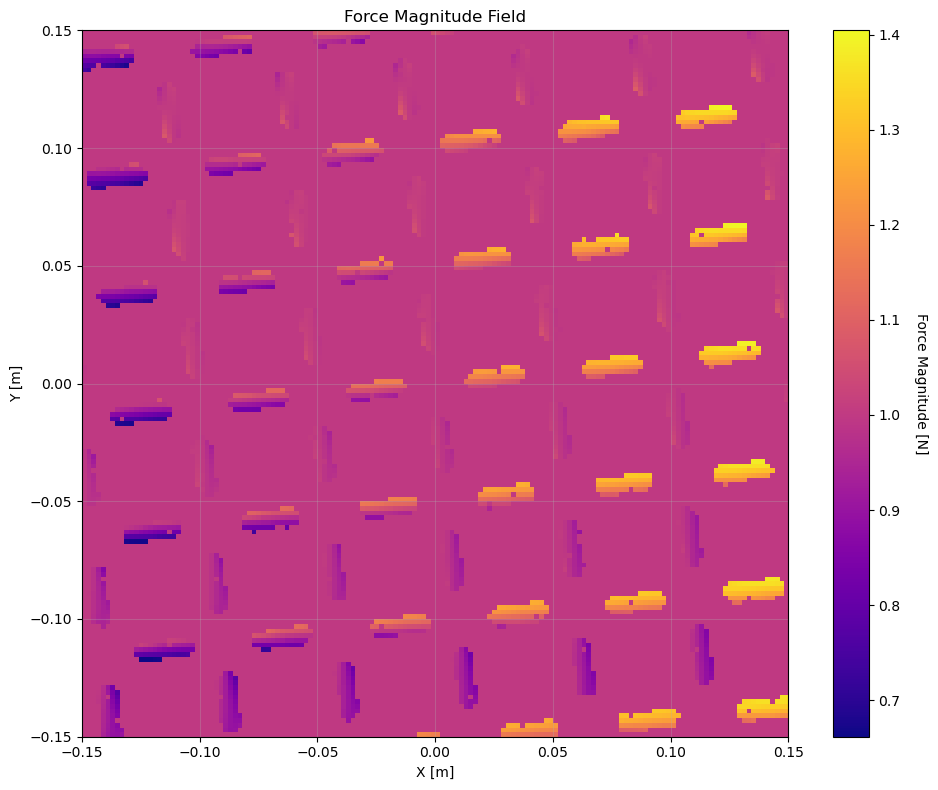


[VISUALIZATION] Summary Statistics:
Force magnitude range: [0.662, 1.405] N
Torque magnitude range: [0.000, 0.535] Nm
[VISUALIZATION] Visualization completed!
Generated plots: wrench_field_heatmaps.png, force_magnitude_heatmap.png
Grid resolution: 150x150


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pickle

# You need to import the model class from your main code
# Add this at the top or make sure PhysicsInformedNullspaceNet is available
# from your_main_file import PhysicsInformedNullspaceNet

def create_wrench_field_visualization_topview(model_path="ML3_ns_policy.weights.h5",
                                   pose_scaler_path="ML3_pose_scaler.pkl",
                                   wrench_scaler_path="ML3_wrench_scaler.pkl",
                                   target_wrench=[0, 0, 1, 0, 0, 0],
                                   x_range=(-0.15, 0.15), y_range=(-0.15, 0.15),
                                   resolution=100,
                                   alpha_fixed=0, beta_fixed=0, gamma_fixed=0.0,
                                   z_fixed=0.005):
    """
    Create top-view heatmap visualization of wrench output over X-Y plane for fixed desired wrench
    """
    print("[VISUALIZATION] Loading trained model...")
    
    # Load model
    model = PhysicsInformedNullspaceNet()
    # Initialize with dummy inputs
    dummy_X = tf.zeros((1,12), dtype=tf.float32)
    dummy_pose = tf.zeros((1,6), dtype=tf.float32)
    dummy_w = tf.zeros((1,6), dtype=tf.float32)
    _ = model(dummy_X, dummy_pose, dummy_w, training=False)
    model.load_weights(model_path)
    print("[VISUALIZATION] Model loaded successfully")
    
    # Load scalers
    print("[VISUALIZATION] Loading scalers...")
    with open(pose_scaler_path, 'rb') as f:
        pose_scaler = pickle.load(f)
    with open(wrench_scaler_path, 'rb') as f:
        wrench_scaler = pickle.load(f)
    print("[VISUALIZATION] Scalers loaded")
    
    print("[VISUALIZATION] Creating meshgrid...")
    # Create X-Y grid
    x_vals = np.linspace(x_range[0], x_range[1], resolution)
    y_vals = np.linspace(y_range[0], y_range[1], resolution)
    X, Y = np.meshgrid(x_vals, y_vals)
    
    # Create position arrays
    x_flat = X.flatten()
    y_flat = Y.flatten()
    
    # Fixed parameters
    z_flat = np.full_like(x_flat, z_fixed)
    alpha_flat = np.full_like(x_flat, alpha_fixed)
    beta_flat = np.full_like(x_flat, beta_fixed)
    gamma_flat = np.full_like(x_flat, gamma_fixed)
    
    # Combine into pose array
    poses = np.stack([x_flat, y_flat, z_flat, alpha_flat, beta_flat, gamma_flat], axis=-1)
    
    # Normalize target wrench
    target_wrench_array = np.array([target_wrench]).astype(np.float32)
    target_wrench_norm = wrench_scaler.transform(target_wrench_array).flatten()
    
    # Prepare input data - THIS IS THE KEY FIX
    print("[VISUALIZATION] Preparing input data...")
    pose_normalized = pose_scaler.transform(poses).astype(np.float32)
    target_wrench_tiled = np.tile(target_wrench_norm, (len(poses), 1))
    input_data = np.concatenate([pose_normalized, target_wrench_tiled], axis=1)
    
    print("[VISUALIZATION] Predicting currents...")
    # Predict currents - USE THE CORRECT CALL FORMAT
    I_pred, W_pred, z_pred = model(
        tf.constant(input_data, dtype=tf.float32),
        tf.constant(poses, dtype=tf.float32),
        tf.constant(target_wrench_tiled, dtype=tf.float32),  # This should be the full batch
        training=False
    )
    
    # Convert back to original scale
    predicted_wrenches = W_pred.numpy()
    
    # Convert to original scale
    predicted_wrenches_original = wrench_scaler.inverse_transform(predicted_wrenches)
    
    # Reshape back to 2D grids
    Fx = predicted_wrenches_original[:, 0].reshape(X.shape)
    Fy = predicted_wrenches_original[:, 1].reshape(X.shape)
    Fz = predicted_wrenches_original[:, 2].reshape(X.shape)
    Tx = predicted_wrenches_original[:, 3].reshape(X.shape)
    Ty = predicted_wrenches_original[:, 4].reshape(X.shape)
    Tz = predicted_wrenches_original[:, 5].reshape(X.shape)
    
    print("[VISUALIZATION] Creating top-view heatmaps...")
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle(f'Wrench Field Heatmaps (Top View)\nTarget: {target_wrench}, α={np.rad2deg(alpha_fixed):.0f}°, β={np.rad2deg(beta_fixed):.0f}°, z={z_fixed*1000:.1f}mm', 
                 fontsize=16, fontweight='bold')
    
    # Flatten axes for easier indexing
    axes_flat = axes.flatten()
    
    # Data and labels
    wrench_data = [Fx, Fy, Fz, Tx, Ty, Tz]
    component_labels = ['Fx [N]', 'Fy [N]', 'Fz [N]', 'Tx [Nm]', 'Ty [Nm]', 'Tz [Nm]']
    color_maps = ['RdBu_r', 'RdBu_r', 'viridis', 'RdBu_r', 'RdBu_r', 'RdBu_r']
    
    # Plot each component
    for i, (ax, data, label, cmap) in enumerate(zip(axes_flat, wrench_data, component_labels, color_maps)):
        # Create heatmap
        im = ax.imshow(data, extent=[x_range[0], x_range[1], y_range[0], y_range[1]], 
                      origin='lower', cmap=cmap, aspect='equal')
        
        # Add colorbar
        cbar = plt.colorbar(im, ax=ax, shrink=0.8)
        cbar.set_label(label, rotation=270, labelpad=20)
        
        # Set labels and title
        ax.set_xlabel('X [m]')
        ax.set_ylabel('Y [m]')
        ax.set_title(f'{label}')
        
        # Add grid for better readability
        ax.grid(True, alpha=0.3)
        
        # Print statistics for each component
        print(f"{label}: min={data.min():.3f}, max={data.max():.3f}, mean={data.mean():.3f}")
    
    plt.tight_layout()
    plt.savefig('wrench_field_heatmaps.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Create a combined magnitude plot
    fig2, ax2 = plt.subplots(1, 1, figsize=(10, 8))
    
    # Calculate force and torque magnitudes
    force_magnitude = np.sqrt(Fx**2 + Fy**2 + Fz**2)
    torque_magnitude = np.sqrt(Tx**2 + Ty**2 + Tz**2)
    
    # Plot force magnitude
    im2 = ax2.imshow(force_magnitude, extent=[x_range[0], x_range[1], y_range[0], y_range[1]], 
                     origin='lower', cmap='plasma', aspect='equal')
    
    # Add colorbar
    cbar2 = plt.colorbar(im2, ax=ax2)
    cbar2.set_label('Force Magnitude [N]', rotation=270, labelpad=20)
    
    # Set labels and title
    ax2.set_xlabel('X [m]')
    ax2.set_ylabel('Y [m]')
    ax2.set_title('Force Magnitude Field')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('force_magnitude_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print summary statistics
    print("\n[VISUALIZATION] Summary Statistics:")
    print(f"Force magnitude range: [{force_magnitude.min():.3f}, {force_magnitude.max():.3f}] N")
    print(f"Torque magnitude range: [{torque_magnitude.min():.3f}, {torque_magnitude.max():.3f}] Nm")
    
    print("[VISUALIZATION] Visualization completed!")
    print(f"Generated plots: wrench_field_heatmaps.png, force_magnitude_heatmap.png")
    print(f"Grid resolution: {resolution}x{resolution}")

# Make sure PhysicsInformedNullspaceNet is available in this scope
# You might need to copy the class definition here or import it properly

# Run the visualization
if __name__ == "__main__":
    print("[MAIN] Starting wrench field visualization (top view)...")
    try:
        create_wrench_field_visualization_topview(
            model_path="ML3_ns_policy.weights.h5",
            pose_scaler_path="ML3_pose_scaler.pkl",
            wrench_scaler_path="ML3_wrench_scaler.pkl",
            target_wrench=[0, 0, 1, 0, 0, 0],  # Desired force in Z direction
            x_range=(-0.15, 0.15),  # X range in meters
            y_range=(-0.15, 0.15),  # Y range in meters
            resolution=150,  # Reduced resolution for faster testing
            alpha_fixed=0,  # 0 degrees
            beta_fixed=0,   # 0 degrees
            gamma_fixed=0.1,      # 0 degrees
            z_fixed=0.005         # 5mm
        )
    except Exception as e:
        print(f"[ERROR] Visualization failed: {e}")
        import traceback
        traceback.print_exc()